In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import zipfile
import pandas as pd
from collections import defaultdict

# Base path to your ChargeMasters folder
BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

# Confirm it's accessible
print("Files found in ChargeMasters folder:")
for f in sorted(os.listdir(BASE_PATH)):
    print(f"  {f}")

Files found in ChargeMasters folder:
  2011-hospital-chargemasters.zip
  2012-hospital-chargemasters.zip
  2013-hospital-chargemasters.zip
  2014-hospital-chargemasters.zip
  2015-hospital-chargemasters.zip
  2016-hospital-chargemasters.zip
  2017-hospital-chargemasters.zip
  2018-hospital-chargemasters.zip
  2019-hospital-chargemasters.zip
  2023-hospital-chargemaster.zip
  Census_Data
  chargemaster-cdm-2020r.zip
  chargemaster-cdm-2021.zip
  chargemastercdm-2022.zip
  chargemastercdm-2024.zip


In [ ]:
yearly_summary = []

for zip_name in sorted(os.listdir(BASE_PATH)):
    if not zip_name.endswith('.zip'):
        continue

    zip_path = os.path.join(BASE_PATH, zip_name)

    # Extract year from filename
    year = None
    for part in zip_name.replace('-', '_').replace('.', '_').split('_'):
        if part.isdigit() and len(part) == 4:
            year = int(part)
            break

    try:
        with zipfile.ZipFile(zip_path, 'r') as z:
            all_files = z.namelist()

            # ── Step 1: find CDM files first ──────────────────────────────
            cdm_files = [f for f in all_files if 'cdm' in f.lower() and not f.endswith('/')]

            # ── Step 2: detect nesting depth from CDM file paths ──────────
            # A CDM file path looks like:  root/[subfolder/]HospitalName/file.xlsx
            # We figure out which path-depth level contains hospital names
            # by looking at where the actual .xlsx/.xls/.csv files live
            hospitals = set()
            cdm_hospitals = set()

            for f in all_files:
                parts = [p for p in f.split('/') if p]  # remove empty strings
                # A file (not folder) will have an extension
                if '.' in parts[-1]:
                    # Hospital folder is always the second-to-last part
                    if len(parts) >= 2:
                        hospitals.add(parts[-2])

            for f in cdm_files:
                parts = [p for p in f.split('/') if p]
                if len(parts) >= 2:
                    cdm_hospitals.add(parts[-2])

            yearly_summary.append({
                'year'              : year,
                'zip_file'          : zip_name,
                'total_files'       : len(all_files),
                'unique_hospitals'  : len(hospitals),
                'hospitals_with_cdm': len(cdm_hospitals),
                'cdm_coverage_%'    : round(len(cdm_hospitals)/len(hospitals)*100, 1) if hospitals else 0
            })

            print(f"\n{'='*60}")
            print(f"Year: {year}  |  ZIP: {zip_name}")
            print(f"  Total files inside    : {len(all_files)}")
            print(f"  Unique hospitals      : {len(hospitals)}")
            print(f"  Hospitals with CDM    : {len(cdm_hospitals)}")
            print(f"  CDM coverage          : {round(len(cdm_hospitals)/len(hospitals)*100,1) if hospitals else 0}%")
            print(f"  Sample CDM files:")
            for cf in cdm_files[:5]:
                print(f"    → {cf}")

    except Exception as e:
        print(f"\nERROR reading {zip_name}: {e}")


Year: 2011  |  ZIP: 2011-hospital-chargemasters.zip
  Total files inside    : 1600
  Unique hospitals      : 412
  Hospitals with CDM    : 411
  CDM coverage          : 99.8%
  Sample CDM files:
    → 2011/Adventist Medical Center - Hanford/106164029_CDM_2011.xls
    → 2011/AHMC Anaheim Regional Medical Center/106301098_CDM_all_2011.xls
    → 2011/Alameda County Medical Center/106010846_CDM_all_2011.xls
    → 2011/Alameda Hospital/106010735_CDM_2011.xlsx
    → 2011/Alameda Hospital/106010735_CDM_RX_2011.xlsx

Year: 2012  |  ZIP: 2012-hospital-chargemasters.zip
  Total files inside    : 1702
  Unique hospitals      : 413
  Hospitals with CDM    : 412
  CDM coverage          : 99.8%
  Sample CDM files:
    → 2012/Adventist Medical Center - Hanford/106164029_CDM_2012.xls
    → 2012/Adventist Medical Center - Reedley/106100797_CDM_2012.xls
    → 2012/AHMC Anaheim Regional Medical Center/106301098_CDM_All_2012.xls
    → 2012/Alameda County Regional Medical Center/106010846_CDM_All_2012.xls

In [ ]:
summary_df = pd.DataFrame(yearly_summary).sort_values('year')

# Fix 2020 year not detected
summary_df.loc[summary_df['zip_file'] == 'chargemaster-cdm-2020r.zip', 'year'] = 2020

print("\n===== YEARLY SUMMARY =====")
print(summary_df.to_string(index=False))

# Save summary to Drive
output_path = os.path.join(BASE_PATH, 'exploration_summary.csv')
summary_df.to_csv(output_path, index=False)
print(f"\nSummary saved to: {output_path}")


===== YEARLY SUMMARY =====
  year                        zip_file  total_files  unique_hospitals  hospitals_with_cdm  cdm_coverage_%
2011.0 2011-hospital-chargemasters.zip         1600               412                 411            99.8
2012.0 2012-hospital-chargemasters.zip         1702               413                 412            99.8
2013.0 2013-hospital-chargemasters.zip         1631               409                 408            99.8
2014.0 2014-hospital-chargemasters.zip         1544               409                 407            99.5
2015.0 2015-hospital-chargemasters.zip         1757               405                 403            99.5
2016.0 2016-hospital-chargemasters.zip         1564               400                 398            99.5
2017.0 2017-hospital-chargemasters.zip         1213               311                 309            99.4
2018.0 2018-hospital-chargemasters.zip         1354               362                 361            99.7
2019.0 2019-hospit

In [ ]:
import io

# We'll sample 2 hospitals from 3 different years (early, middle, recent)
# to understand how columns vary across years

SAMPLE_YEARS = {
    '2011-hospital-chargemasters.zip' : 2011,
    '2017-hospital-chargemasters.zip' : 2017,
    '2019-hospital-chargemasters.zip' : 2019,
    'chargemaster-cdm-2020r.zip'      : 2020,
    'chargemastercdm-2022.zip'        : 2022,
    'chargemastercdm-2024.zip'        : 2024,
}

HOSPITALS_PER_ZIP = 2   # how many hospitals to sample per year
FILES_PER_HOSPITAL = 1  # first CDM file per hospital

peek_results = []

for zip_name, year in SAMPLE_YEARS.items():
    zip_path = os.path.join(BASE_PATH, zip_name)

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()
        cdm_files = [f for f in all_files
                     if 'cdm' in f.lower() and not f.endswith('/')
                     and f.lower().endswith(('.xlsx', '.xls', '.csv'))]

        # Group by hospital (second-to-last path part)
        from collections import defaultdict
        hosp_files = defaultdict(list)
        for f in cdm_files:
            parts = [p for p in f.split('/') if p]
            if len(parts) >= 2:
                hosp_files[parts[-2]].append(f)

        sampled = list(hosp_files.items())[:HOSPITALS_PER_ZIP]

        for hosp_name, files in sampled:
            file_path = files[0]  # take first CDM file
            ext = file_path.lower().split('.')[-1]

            try:
                with z.open(file_path) as f:
                    raw = io.BytesIO(f.read())

                if ext == 'csv':
                    # Try common encodings
                    for enc in ['utf-8', 'latin-1', 'cp1252']:
                        try:
                            raw.seek(0)
                            df = pd.read_csv(raw, encoding=enc, nrows=5, dtype=str)
                            break
                        except:
                            continue
                else:
                    df = pd.read_excel(raw, nrows=5, dtype=str)

                peek_results.append({
                    'year'    : year,
                    'hospital': hosp_name,
                    'file'    : file_path.split('/')[-1],
                    'columns' : list(df.columns),
                    'n_cols'  : len(df.columns),
                    'sample'  : df
                })

                print(f"\n{'='*65}")
                print(f"Year: {year} | Hospital: {hosp_name}")
                print(f"File : {file_path.split('/')[-1]}")
                print(f"Cols ({len(df.columns)}): {list(df.columns)}")
                print(df.head(3).to_string())

            except Exception as e:
                print(f"\nERROR reading {file_path}: {e}")


Year: 2011 | Hospital: Adventist Medical Center - Hanford
File : 106164029_CDM_2011.xls
Cols (4): ['Hanford Community Medical Center', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3']
  Hanford Community Medical Center Unnamed: 1 Unnamed: 2 Unnamed: 3
0           Tax I. D. # 94-0535360        NaN        NaN        NaN
1          June 2011 Charge Master        NaN        NaN        NaN
2                              NaN        NaN        NaN        NaN

Year: 2011 | Hospital: AHMC Anaheim Regional Medical Center
File : 106301098_CDM_all_2011.xls
Cols (3): ['Hospital Name:  AHMC ANAHEIM', 'Unnamed: 1', 'Unnamed: 2']
              Hospital Name:  AHMC ANAHEIM Unnamed: 1 Unnamed: 2
0             OSHPD Facility No: 106301098        NaN        NaN
1  Effective Date of Charges: June 1, 2011        NaN        NaN
2                                      NaN        NaN        NaN

Year: 2017 | Hospital: Adventist Medical Center - Hanford
File : 106164029_CDM_2017.xlsx
Cols (4): ['Hanford Community Medi

In [ ]:
import io
import re

def find_real_header_row(df_raw):
    """
    Scan rows to find which row contains the actual column headers
    by looking for keywords commonly found in CDM headers.
    """
    header_keywords = [
        'description', 'charge', 'price', 'amount', 'code',
        'hcpcs', 'cpt', 'rev', 'revenue', 'service', 'procedure',
        'rate', 'cost', 'cdm', 'item', 'detail', 'uom', 'unit'
    ]

    for i, row in df_raw.iterrows():
        row_str = ' '.join([str(v).lower() for v in row.values if pd.notna(v)])
        matches = sum(1 for kw in header_keywords if kw in row_str)
        if matches >= 2:  # at least 2 header keywords found in this row
            return i
    return None

SAMPLE_YEARS = {
    '2011-hospital-chargemasters.zip' : 2011,
    '2017-hospital-chargemasters.zip' : 2017,
    '2019-hospital-chargemasters.zip' : 2019,
    'chargemaster-cdm-2020r.zip'      : 2020,
    'chargemastercdm-2022.zip'        : 2022,
    'chargemastercdm-2024.zip'        : 2024,
}

HOSPITALS_PER_ZIP = 2

for zip_name, year in SAMPLE_YEARS.items():
    zip_path = os.path.join(BASE_PATH, zip_name)

    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()
        cdm_files = [f for f in all_files
                     if 'cdm' in f.lower() and not f.endswith('/')
                     and f.lower().endswith(('.xlsx', '.xls', '.csv'))]

        hosp_files = defaultdict(list)
        for f in cdm_files:
            parts = [p for p in f.split('/') if p]
            if len(parts) >= 2:
                hosp_files[parts[-2]].append(f)

        sampled = list(hosp_files.items())[:HOSPITALS_PER_ZIP]

        for hosp_name, files in sampled:
            file_path = files[0]
            ext = file_path.lower().split('.')[-1]

            try:
                with z.open(file_path) as f:
                    raw = io.BytesIO(f.read())

                # Read first 30 rows raw to find header
                if ext == 'csv':
                    for enc in ['utf-8', 'latin-1', 'cp1252']:
                        try:
                            raw.seek(0)
                            df_raw = pd.read_csv(raw, encoding=enc, nrows=30,
                                                 header=None, dtype=str)
                            break
                        except:
                            continue
                else:
                    df_raw = pd.read_excel(raw, nrows=30, header=None, dtype=str)

                header_row = find_real_header_row(df_raw)

                print(f"\n{'='*65}")
                print(f"Year: {year} | Hospital: {hosp_name}")
                print(f"File : {file_path.split('/')[-1]}")

                if header_row is not None:
                    print(f"✅ Header found at row: {header_row}")

                    # Now re-read with correct header
                    raw.seek(0)
                    if ext == 'csv':
                        for enc in ['utf-8', 'latin-1', 'cp1252']:
                            try:
                                raw.seek(0)
                                df = pd.read_csv(raw, encoding=enc,
                                                 skiprows=header_row,
                                                 nrows=5, dtype=str)
                                break
                            except:
                                continue
                    else:
                        df = pd.read_excel(raw, skiprows=header_row,
                                           nrows=5, dtype=str)

                    print(f"Columns ({len(df.columns)}): {list(df.columns)}")
                    print(df.head(3).to_string())
                else:
                    print(f"❌ Could not detect header row automatically")
                    print(f"   Raw first 10 rows:")
                    print(df_raw.head(10).to_string())

            except Exception as e:
                print(f"\nERROR: {e}")


Year: 2011 | Hospital: Adventist Medical Center - Hanford
File : 106164029_CDM_2011.xls
✅ Header found at row: 4
Columns (4): ['2011 Charge Codes', 'Charge Codes Description', 'HCPCS Codes', 'June 2011 Prices']
  2011 Charge Codes Charge Codes Description HCPCS Codes June 2011 Prices
0             16501          RB ER1 - M/S SP         NaN             2126
1             17509      RB NB LVL 1 ROUTINE         NaN             2126
2             21014               RB M/S1 SP         NaN             2126

Year: 2011 | Hospital: AHMC Anaheim Regional Medical Center
File : 106301098_CDM_all_2011.xls
✅ Header found at row: 5
Columns (3): ['CDM', 'BILLING CHARGE DESCRIPTION', 'PRICE']
        CDM      BILLING CHARGE DESCRIPTION PRICE
0    700008  IVP SINGLE/EA NEW RX ADD'L INJ   205
1    700016                 IVAD IRRIGATION    84
2    700032    CHEMO HORMON ANTINEOPL SQ/IM   169

Year: 2017 | Hospital: Adventist Medical Center - Hanford
File : 106164029_CDM_2017.xlsx
✅ Header found at row:

In [ ]:
# Let's look at ALL sheets in the problematic files (2019, 2020, 2022, 2024)

PROBLEM_FILES = {
    '2019-hospital-chargemasters.zip' : ('2019/Adventist Health Bakersfield/106150788_CDM_All_2019.xlsx', 2019),
    'chargemaster-cdm-2020r.zip'      : ('Adventist Health And Rideout/106580996_CDM_All_2020.xlsx', 2020),
    'chargemastercdm-2022.zip'        : ('ChargemasterCDM-2022/2022 Completed Reviews/Adventist Health and Rideout/106580996_CDM_All_AHRO_2022.xlsx', 2022),
    'chargemastercdm-2024.zip'        : ('ChargemasterCDM-2024/ADVENTIST HEALTH AND RIDEOUT/106580996_CDM_All_AHRO_2024.xlsx', 2024),
}

for zip_name, (file_path, year) in PROBLEM_FILES.items():
    zip_path = os.path.join(BASE_PATH, zip_name)
    print(f"\n{'='*65}")
    print(f"Year: {year} | File: {file_path.split('/')[-1]}")

    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())

        # Get all sheet names
        xl = pd.ExcelFile(raw)
        print(f"Sheets: {xl.sheet_names}")

        # Read first 15 rows of EACH sheet
        for sheet in xl.sheet_names:
            print(f"\n  --- Sheet: '{sheet}' ---")
            try:
                raw.seek(0)
                df = pd.read_excel(raw, sheet_name=sheet, nrows=15,
                                   header=None, dtype=str)
                # Find header row in this sheet
                header_row = find_real_header_row(df)
                if header_row is not None:
                    print(f"  ✅ Header found at row {header_row}")
                    raw.seek(0)
                    df_data = pd.read_excel(raw, sheet_name=sheet,
                                            skiprows=header_row, nrows=5, dtype=str)
                    print(f"  Columns: {list(df_data.columns)}")
                    print(df_data.head(3).to_string())
                else:
                    print(f"  ❌ No header found. Raw rows:")
                    print(df.to_string())
            except Exception as e:
                print(f"  ERROR: {e}")


Year: 2019 | File: 106150788_CDM_All_2019.xlsx
Sheets: ['Cover Page', 'Price Change Impact', 'Common OP Procedures', 'DRGs', 'Hospital CDM']

  --- Sheet: 'Cover Page' ---
  ✅ Header found at row 7
  Columns: [1, 'The CDM price and average billed charges for IP DRGs and OP Procedures do not reflect amounts paid for services provided, neither by patients nor their insurers.  Amounts paid are based on the type of care provided to the patient (often measured by an index), or the number of days (per diem) a patient stays in the hospital.  Amounts paid by Medicare and Medicaid are based on multiple factors published by the government, and are also linked to the type of care provided (diagnosis and procedures).  Private insurance pays based on amounts negotiated with the hospitals.  The amounts due from the patient are determined by the terms of their respective plans.', 'Unnamed: 2']
     1 The CDM price and average billed charges for IP DRGs and OP Procedures do not reflect amounts paid f

In [ ]:
# ============================================================
# CELL 8 — Universal CDM File Reader
# Handles all year formats automatically
# ============================================================

def standardize_columns(df):
    """
    Map whatever column names the file uses → standard names:
    charge_code, description, hcpcs_code, price
    """
    col_map = {}
    for col in df.columns:
        col_lower = str(col).lower().strip()

        # Price column — must check first (before 'code' catches it)
        if any(k in col_lower for k in ['price', 'amount', 'charge amount', 'rate']):
            if 'charge code' not in col_lower and 'charge code description' not in col_lower:
                col_map[col] = 'price'

        # Description
        elif any(k in col_lower for k in ['description', 'desc']):
            col_map[col] = 'description'

        # HCPCS / CPT code
        elif any(k in col_lower for k in ['hcpcs', 'cpt', 'procedure code', 'proc code']):
            col_map[col] = 'hcpcs_code'

        # Charge code (internal)
        elif any(k in col_lower for k in ['charge code', 'cdm', 'item', 'service code', 'rev code']):
            col_map[col] = 'charge_code'

    return df.rename(columns=col_map)


def read_cdm_file(z, file_path):
    """
    Read a single CDM file from inside a ZipFile object.
    Returns a cleaned DataFrame with standard columns, or None on failure.
    """
    ext = file_path.lower().split('.')[-1]
    if ext not in ('xlsx', 'xls', 'csv'):
        return None

    try:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())

        # ── CSV ──────────────────────────────────────────────
        if ext == 'csv':
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, encoding=enc, nrows=40,
                                         header=None, dtype=str)
                    header_row = find_real_header_row(df_raw)
                    raw.seek(0)
                    df = pd.read_csv(raw, encoding=enc,
                                     skiprows=header_row if header_row else 0,
                                     dtype=str)
                    return standardize_columns(df)
                except:
                    continue
            return None

        # ── Excel ────────────────────────────────────────────
        xl = pd.ExcelFile(raw)
        sheet_names_lower = [s.lower().strip() for s in xl.sheet_names]

        # Priority 1: sheet explicitly named 'hospital cdm'
        if 'hospital cdm' in sheet_names_lower:
            target_sheet = xl.sheet_names[sheet_names_lower.index('hospital cdm')]
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target_sheet, dtype=str)
            return standardize_columns(df)

        # Priority 2: sheet named 'cdm'
        elif 'cdm' in sheet_names_lower:
            target_sheet = xl.sheet_names[sheet_names_lower.index('cdm')]
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target_sheet, dtype=str)
            return standardize_columns(df)

        # Priority 3: single sheet or fallback — find header row
        else:
            raw.seek(0)
            df_raw = pd.read_excel(raw, sheet_name=0, nrows=40,
                                    header=None, dtype=str)
            header_row = find_real_header_row(df_raw)
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=0,
                                skiprows=header_row if header_row is not None else 0,
                                dtype=str)
            return standardize_columns(df)

    except Exception as e:
        return None


# ── Quick test on 4 known files ──────────────────────────────
TEST_FILES = {
    '2011-hospital-chargemasters.zip' : '2011/Adventist Medical Center - Hanford/106164029_CDM_2011.xls',
    '2019-hospital-chargemasters.zip' : '2019/Adventist Health Bakersfield/106150788_CDM_All_2019.xlsx',
    'chargemaster-cdm-2020r.zip'      : 'Adventist Health And Rideout/106580996_CDM_All_2020.xlsx',
    'chargemastercdm-2024.zip'        : 'ChargemasterCDM-2024/ADVENTIST HEALTH AND RIDEOUT/106580996_CDM_All_AHRO_2024.xlsx',
}

for zip_name, file_path in TEST_FILES.items():
    zip_path = os.path.join(BASE_PATH, zip_name)
    print(f"\n{'='*60}")
    print(f"Testing: {zip_name.split('-')[0]} | {file_path.split('/')[-1]}")

    with zipfile.ZipFile(zip_path, 'r') as z:
        df = read_cdm_file(z, file_path)

    if df is not None:
        print(f"✅ Columns after standardization: {list(df.columns)}")
        print(f"   Rows: {len(df)}")
        # Show only our standard columns if present
        std_cols = [c for c in ['charge_code','description','hcpcs_code','price'] if c in df.columns]
        print(df[std_cols].dropna(how='all').head(5).to_string())
    else:
        print("❌ Failed to read")


Testing: 2011 | 106164029_CDM_2011.xls
✅ Columns after standardization: ['charge_code', 'description', 'hcpcs_code', 'price']
   Rows: 8344
  charge_code          description hcpcs_code price
0       16501      RB ER1 - M/S SP        NaN  2126
1       17509  RB NB LVL 1 ROUTINE        NaN  2126
2       21014           RB M/S1 SP        NaN  2126
3       21022           RB M/S2 SP        NaN  2126
4       21030           RB M/S3 SP        NaN  2126

Testing: 2019 | 106150788_CDM_All_2019.xlsx
✅ Columns after standardization: ['charge_code', 'description', 'hcpcs_code', 'price']
   Rows: 11749
  charge_code                        description hcpcs_code    price
0        1131           ROOM/BED: Med/Surg Other        NaN  3811.26
1        1255           ROOM/BED: Intensive Care        NaN  7760.78
2        7211         ROOM/BED: Med/Surg Private        NaN  3811.26
3       17004  ROOM/BED: Obstetrics LDRP Private        NaN  2629.48
4       17509          ROOM/BED: Newborn Routine       

In [ ]:
# ============================================================
# CELL 0 — ALL IMPORTS & SETUP
# Run this first every time Colab runtime restarts
# ============================================================

import os
import io
import re
import time
import zipfile
import pandas as pd
from collections import defaultdict

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Base path
BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

# Confirm accessible
print("✅ All imports loaded")
print(f"✅ BASE_PATH set to: {BASE_PATH}")
print(f"\nFiles in ChargeMasters folder:")
for f in sorted(os.listdir(BASE_PATH)):
    print(f"  {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All imports loaded
✅ BASE_PATH set to: /content/drive/MyDrive/ChargeMasters

Files in ChargeMasters folder:
  2011-hospital-chargemasters.zip
  2012-hospital-chargemasters.zip
  2013-hospital-chargemasters.zip
  2014-hospital-chargemasters.zip
  2015-hospital-chargemasters.zip
  2016-hospital-chargemasters.zip
  2017-hospital-chargemasters.zip
  2018-hospital-chargemasters.zip
  2019-hospital-chargemasters.zip
  2023-hospital-chargemaster.zip
  Census_Data
  TEST_2019_extraction.csv
  TEST_2019_extraction_v2.csv
  TEST_2019_extraction_v3.csv
  chargemaster-cdm-2020r.zip
  chargemaster-cdm-2021.zip
  chargemastercdm-2022.zip
  chargemastercdm-2024.zip
  exploration_summary.csv


In [ ]:
def find_real_header_row(df_raw):
    header_keywords = [
        'description', 'charge', 'price', 'amount', 'code',
        'hcpcs', 'cpt', 'rev', 'revenue', 'service', 'procedure',
        'rate', 'cost', 'cdm', 'item', 'detail', 'uom', 'unit'
    ]
    for i, row in df_raw.iterrows():
        row_str = ' '.join([str(v).lower() for v in row.values if pd.notna(v)])
        matches = sum(1 for kw in header_keywords if kw in row_str)
        if matches >= 2:
            return i
    return None


def standardize_columns(df):
    col_map = {}
    for col in df.columns:
        col_lower = str(col).lower().strip()
        if any(k in col_lower for k in ['price', 'amount', 'rate']):
            if 'charge code' not in col_lower and 'description' not in col_lower:
                col_map[col] = 'price'
        elif any(k in col_lower for k in ['description', 'desc']):
            col_map[col] = 'description'
        elif any(k in col_lower for k in ['hcpcs', 'cpt', 'procedure code']):
            col_map[col] = 'hcpcs_code'
        elif any(k in col_lower for k in ['charge code', 'cdm', 'item', 'service code']):
            col_map[col] = 'charge_code'
    return df.rename(columns=col_map)


def read_cdm_file(z, file_path):
    ext = file_path.lower().split('.')[-1]
    if ext not in ('xlsx', 'xls', 'csv'):
        return None
    try:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())

        if ext == 'csv':
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, encoding=enc, nrows=40,
                                         header=None, dtype=str)
                    header_row = find_real_header_row(df_raw)
                    raw.seek(0)
                    df = pd.read_csv(raw, encoding=enc,
                                     skiprows=header_row if header_row else 0,
                                     dtype=str)
                    return standardize_columns(df)
                except:
                    continue
            return None

        xl = pd.ExcelFile(raw)
        sheet_names_lower = [s.lower().strip() for s in xl.sheet_names]

        if 'hospital cdm' in sheet_names_lower:
            target = xl.sheet_names[sheet_names_lower.index('hospital cdm')]
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target, dtype=str)
            return standardize_columns(df)
        elif 'cdm' in sheet_names_lower:
            target = xl.sheet_names[sheet_names_lower.index('cdm')]
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target, dtype=str)
            return standardize_columns(df)
        else:
            raw.seek(0)
            df_raw = pd.read_excel(raw, sheet_name=0, nrows=40,
                                    header=None, dtype=str)
            header_row = find_real_header_row(df_raw)
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=0,
                                skiprows=header_row if header_row is not None else 0,
                                dtype=str)
            return standardize_columns(df)
    except:
        return None

print("✅ Helper functions loaded: find_real_header_row, standardize_columns, read_cdm_file")

✅ Helper functions loaded: find_real_header_row, standardize_columns, read_cdm_file


In [ ]:
# ============================================================
# CELL 9 — VERIFIED CPT CODES, REVENUE CODES & KEYWORDS
# ============================================================
# Sources:
# 1. Lakshminrusimha et al., Journal of Perinatology, 2023 (PMC10716034)
#    — CPT codes for neonatal/pediatric critical & intensive care
# 2. NUBC UB-04/CMS-1450 Revenue Code standard
#    — Revenue codes for nursery, newborn, NICU, PICU, peds room & board
# 3. Morrison et al., Cureus, 2024 (PMC11663616)
#    — Dual CPT + keyword extraction methodology from chargemasters
# 4. HCAI California — data source
#    — https://hcai.ca.gov/data/cost-transparency/hospital-chargemasters/
# ============================================================

# ── CPT CODES (primary extraction method) ───────────────────
# Source: Lakshminrusimha et al., J Perinatol 2023, Table 1 & Table 2

CPT_CODES = {

    # --- Normal Newborn Care (Table 1) ---
    'Normal_Newborn_Care': [
        '99460',   # Initial normal newborn care
        '99462',   # Subsequent normal newborn care
        '99463',   # Normal newborn — same day admit & discharge
    ],

    # --- Neonatal Critical Care ≤28 days (Table 1) ---
    'Neonatal_Critical_Care': [
        '99468',   # Initial inpatient neonatal critical care, ≤28 days
        '99469',   # Subsequent inpatient neonatal critical care, ≤28 days
    ],

    # --- Pediatric Critical Care 29 days–24 months (Table 1) ---
    'Pediatric_Critical_Care': [
        '99471',   # Initial inpatient pediatric critical care, 29 days–24 months
        '99472',   # Subsequent inpatient pediatric critical care, 29 days–24 months
    ],

    # --- Neonatal & Pediatric Intensive Care (Table 1) ---
    'Neonatal_Intensive_Care': [
        '99477',   # Initial intensive care, neonate ≤28 days, not critically ill
        '99478',   # Subsequent intensive care, VLBW <1500g
        '99479',   # Subsequent intensive care, LBW 1500–2500g
        '99480',   # Subsequent intensive care, infant 2501–5000g
    ],

    # --- Hospital Care for Ill Newborn (Table 1) ---
    # Used when newborn doesn't need intensive/critical care
    'Hospital_Care_Ill_Newborn': [
        '99221',   # Initial hospital care — straightforward/low complexity
        '99222',   # Initial hospital care — moderate complexity
        '99223',   # Initial hospital care — high complexity
        '99231',   # Subsequent hospital care — low complexity
        '99232',   # Subsequent hospital care — moderate complexity
        '99233',   # Subsequent hospital care — high complexity
    ],

    # --- Discharge Codes (Table 1) ---
    'Discharge_Care': [
        '99238',   # Hospital discharge ≤30 min
        '99239',   # Hospital discharge >30 min
    ],

    # --- Hourly Critical Care (Table 1) ---
    # Used for transfers, second specialist in NICU
    'Hourly_Critical_Care': [
        '99291',   # Critical care first 30–74 min
        '99292',   # Critical care each additional 30 min
    ],

    # --- Separately Billable Neonatal Procedures (Table 2) ---
    # These are NOT bundled into daily global codes
    'Neonatal_Procedures': [
        '33946',   # ECMO/ECLS venovenous (VV) initiation
        '33947',   # ECMO/ECLS venoarterial (VA) initiation
        '33948',   # Daily management VV ECMO/ECLS
        '33949',   # Daily management VA ECMO/ECLS
        '99184',   # Therapeutic hypothermia initiation (head/body cooling)
        '36568',   # PICC line placement
        '36680',   # Intraosseous (IO) needle placement
        '92960',   # Cardioversion
        '92950',   # Cardiopulmonary resuscitation (CPR)
        '38220',   # Bone marrow aspiration
        '36456',   # Partial exchange transfusion
        '36450',   # Double-volume exchange transfusion
        '32554',   # Thoracocentesis without imaging
        '32555',   # Thoracocentesis with imaging
        '32556',   # Chest tube without imaging
        '32557',   # Chest tube with imaging
        '49082',   # Abdominal paracentesis without imaging
        '49083',   # Abdominal paracentesis with imaging
    ],
}

# Flatten all CPT codes to a single set for fast lookup
ALL_CPT_CODES = set()
for codes in CPT_CODES.values():
    for c in codes:
        ALL_CPT_CODES.add(c.strip())
        ALL_CPT_CODES.add(c.strip().zfill(5))  # zero-padded version

print(f"Total CPT codes loaded: {len(ALL_CPT_CODES)}")


# ── REVENUE CODES (secondary code-based method) ──────────────
# Source: NUBC UB-04/CMS-1450 standard
# Stored in both 3-digit and 4-digit (zero-padded) formats
# because hospitals store them inconsistently in CDMs

REVENUE_CODES = {

    # 017X — Nursery / Newborn Room & Board
    'Nursery_Newborn': [
        '0170', '170',   # Nursery — General
        '0171', '171',   # Newborn Level I  (healthy/well baby)
        '0172', '172',   # Newborn Level II (sick newborn, not NICU)
        '0173', '173',   # Newborn Level III (intermediate NICU)
        '0174', '174',   # Newborn Level IV (highest level NICU)
        '0179', '179',   # Other Nursery
    ],

    # Room & Board — Pediatric subcategories (011X, 012X, 013X, 014X)
    'Peds_Room_Board': [
        '0113', '113',   # Private room — Pediatric
        '0123', '123',   # Semi-private 2-bed — Pediatric
        '0133', '133',   # Semi-private 3-4 bed — Pediatric
        '0143', '143',   # Private deluxe — Pediatric
    ],

    # 020X — Intensive Care (NICU/PICU specific subcodes)
    'ICU_NICU_PICU': [
        '0200', '200',   # Intensive Care — General
        '0203', '203',   # Pediatric ICU (PICU)
        '0204', '204',   # Neonatal ICU (NICU) — most specific
        '0209', '209',   # Other ICU
    ],
}

# Flatten revenue codes to a single set
ALL_REVENUE_CODES = set()
for codes in REVENUE_CODES.values():
    for c in codes:
        ALL_REVENUE_CODES.add(str(c).strip())

print(f"Total revenue codes loaded: {len(ALL_REVENUE_CODES)}")


# ── KEYWORDS (tertiary method) ───────────────────────────────
# Source: Clinical conditions described in Lakshminrusimha et al. 2023
# + observed CDM descriptions from our Cell 6/7 exploration
# Applied to the 'description' field (lowercased)

KEYWORDS = [

    # --- Newborn / Nursery ---
    'newborn', 'new born', 'normal newborn', 'routine newborn',
    'well baby', 'well-baby', 'nursery',
    'nb lvl', 'nb level', 'nb routine', 'nb ',
    ' nb ', 'neonatal routine',

    # --- Neonatal / Neonate ---
    'neonatal', 'neonate', 'neonat',

    # --- NICU ---
    'nicu', 'neonatal icu', 'neonatal intensive',
    'neonatal critical', 'neo icu',

    # --- Birth Weight categories (from 99478-99480 definitions) ---
    'vlbw', 'very low birth weight',
    'lbw', 'low birth weight',
    'premature', 'preterm', 'prematurity',

    # --- Pediatric / PICU ---
    'pediatric', 'paediatric', 'peds', 'picu',
    'pediatric icu', 'pediatric intensive',
    'pediatric critical',

    # --- Neonatal Procedures (from Table 2, Lakshminrusimha) ---
    'ecmo', 'extracorporeal',
    'hypothermia', 'therapeutic cooling', 'body cooling', 'head cooling',
    'exchange transfusion',
    'thoracentesis', 'thoracocentesis',
    'chest tube neonat',
    'picc neonat', 'picc newborn',
    'intraosseous neonat',

    # --- Respiratory support ---
    'surfactant', 'intratracheal',
    'cpap neonat', 'cpap newborn', 'neonatal cpap',
    'neonatal vent', 'neo vent', 'neonatal ventilat',
    'hfnc neonat', 'high flow neonat',
    'oscillator', 'hfov',

    # --- Common NICU conditions (from Lakshminrusimha clinical examples) ---
    'phototherapy', 'bili light', 'bililight',
    'bilirubin neonat', 'bilirubin newborn',
    'jaundice neonat', 'jaundice newborn',
    'apnea neonat', 'apnea newborn', 'apnea prematurity',
    'bradycardia neonat', 'bradycardia newborn',
    'sepsis neonat', 'sepsis newborn',
    'nec ', 'necrotizing enterocolitis',
    'hypoglycemia neonat', 'hypoglycemia newborn',
    'isolette', 'incubator neonat',
    'umbilical line', 'umbilical catheter',
    'uac ', 'uvc ',

    # --- From actual CDM descriptions seen in our data exploration ---
    'rb nb',        # e.g. "RB NB LVL 1 ROUTINE"
    'rb newborn',   # e.g. "RB NEWBORN ROUTINE"
    'room/bed: newborn',
    'room/bed: neonatal',
    'neonatal room',
    'newborn room',
]

print(f"Total keywords loaded: {len(KEYWORDS)}")
print("\nSummary:")
print(f"  CPT codes    : {len(ALL_CPT_CODES)}")
print(f"  Revenue codes: {len(ALL_REVENUE_CODES)}")
print(f"  Keywords     : {len(KEYWORDS)}")

Total CPT codes loaded: 39
Total revenue codes loaded: 28
Total keywords loaded: 90

Summary:
  CPT codes    : 39
  Revenue codes: 28
  Keywords     : 90


In [ ]:
# ============================================================
# CELL 10 — FIXED extract_nicu_rows + 2019 extraction
# ============================================================

def extract_nicu_rows(df, hospital, year, file_name):
    """
    Extract rows related to Newborn/NICU/Peds from a standardized CDM df.
    Method 1 (primary)  : CPT/HCPCS code match
    Method 2 (secondary): Revenue code match (charge_code field)
    Method 3 (tertiary) : Keyword match in description
    """
    # ── Safe null checks ─────────────────────────────────────
    if df is None:
        return None
    if not isinstance(df, pd.DataFrame):
        return None
    if df.empty:
        return None
    if 'description' not in df.columns and 'price' not in df.columns:
        return None

    extracted = []

    for _, row in df.iterrows():
        desc    = str(row.get('description', '') or '').lower().strip()
        hcpcs   = str(row.get('hcpcs_code',  '') or '').lower().strip()
        ccode   = str(row.get('charge_code', '') or '').strip()
        price   = row.get('price', None)

        match_type = None

        # Method 1 — CPT/HCPCS code match
        hcpcs_clean = re.sub(r'\D', '', hcpcs)
        if hcpcs_clean and (hcpcs_clean in ALL_CPT_CODES or
                            hcpcs_clean.zfill(5) in ALL_CPT_CODES):
            match_type = 'cpt_code'

        # Method 2 — Revenue code match on charge_code field
        if match_type is None:
            ccode_clean = re.sub(r'\D', '', ccode)
            if ccode_clean and (
                ccode_clean        in ALL_REVENUE_CODES or
                ccode_clean.zfill(3) in ALL_REVENUE_CODES or
                ccode_clean.zfill(4) in ALL_REVENUE_CODES
            ):
                match_type = 'revenue_code'

        # Method 3 — Keyword match in description
        if match_type is None:
            for kw in KEYWORDS:
                if kw in desc:
                    match_type = 'keyword'
                    break

        if match_type:
            extracted.append({
                'hospital'    : hospital,
                'year'        : year,
                'source_file' : file_name,
                'description' : row.get('description', ''),
                'price'       : price,
                'hcpcs_code'  : row.get('hcpcs_code', ''),
                'charge_code' : row.get('charge_code', ''),
                'match_type'  : match_type,
            })

    return pd.DataFrame(extracted) if extracted else None


# ── Run on 2019 only ─────────────────────────────────────────
TEST_ZIP  = '2019-hospital-chargemasters.zip'
TEST_YEAR = 2019
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

print(f"Running extraction on {TEST_YEAR}...")
print(f"ZIP: {TEST_ZIP}\n")

year_extracted = []
hospitals_hit  = 0
hospitals_miss = 0
read_errors    = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    cdm_files = [f for f in all_files
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx', '.xls', '.csv'))]

    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    print(f"Total hospitals found : {len(hosp_files)}")
    print(f"Total CDM files found : {len(cdm_files)}\n")

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df = read_cdm_file(z, file_path)
                extracted = extract_nicu_rows(
                    df, hospital, TEST_YEAR, file_path.split('/')[-1]
                )
                if extracted is not None and len(extracted) > 0:
                    year_extracted.append(extracted)
                    hosp_rows += len(extracted)
            except Exception as e:
                read_errors += 1

        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

# ── Results ──────────────────────────────────────────────────
if year_extracted:
    df_2019 = pd.concat(year_extracted, ignore_index=True)

    print(f"{'='*55}")
    print(f"2019 EXTRACTION RESULTS")
    print(f"{'='*55}")
    print(f"Hospitals with extracted rows : {hospitals_hit}")
    print(f"Hospitals with zero matches   : {hospitals_miss}")
    print(f"Read errors                   : {read_errors}")
    print(f"Total rows extracted          : {len(df_2019):,}")
    print(f"\nMatch type breakdown:")
    print(df_2019['match_type'].value_counts())
    print(f"\nPrice stats:")
    df_2019['price_num'] = pd.to_numeric(df_2019['price'], errors='coerce')
    print(df_2019['price_num'].describe())
    print(f"\nSample rows (first 20):")
    print(df_2019[['hospital','description','price',
                   'charge_code','match_type']].head(20).to_string())
else:
    print("❌ No rows extracted")

Running extraction on 2019...
ZIP: 2019-hospital-chargemasters.zip

Total hospitals found : 361
Total CDM files found : 376



/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: CDM!$A:$D.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'COMMON OP PROCEDURES'!$A:$C.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'PCT CHANGE GROSS REV'!$A:$B.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: CDM!$A:$D.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'COMMON OP

WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)


/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: CDM!$A:$D.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'COMMON OP PROCEDURES'!$A:$C.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'PCT CHANGE GROSS REV'!$A:$B.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/usr/local/lib/python3.12/dist-packages/openpyxl/reader/workbook.py:118: UserWarning: Print area cannot be set to Defined name: CDM!$

2019 EXTRACTION RESULTS
Hospitals with extracted rows : 137
Hospitals with zero matches   : 224
Read errors                   : 42
Total rows extracted          : 6,148

Match type breakdown:
match_type
keyword         5814
cpt_code         311
revenue_code      23
Name: count, dtype: int64

Price stats:
count     4318.000000
mean      2311.244526
std       5999.703114
min          0.000000
25%        107.100000
50%        335.860000
75%       1785.000000
max      78579.000000
Name: price_num, dtype: float64

Sample rows (first 20):
                        hospital                            description    price charge_code match_type
0   Adventist Health Bakersfield              ROOM/BED: Newborn Routine  1731.32       17509    keyword
1   Adventist Health Bakersfield            ROOM/BED: Newborn - Level 2  1992.48       27508    keyword
2   Adventist Health Bakersfield            ROOM/BED: Newborn - Level 3  5160.45       37507    keyword
3   Adventist Health Bakersfield             

In [ ]:
# DIAGNOSTIC CELL — what are the zero-match hospitals?
# Let's peek at one hospital that had NO matches

no_match_hospitals = []
with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    cdm_files = [f for f in all_files
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx', '.xls', '.csv'))]

    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    # Find hospitals not in df_2019
    matched_hospitals = set(df_2019['hospital'].unique())
    all_hospitals = set(hosp_files.keys())
    no_match = all_hospitals - matched_hospitals

    print(f"Hospitals with NO matches: {len(no_match)}")
    print(f"\nSample of 5 unmatched hospitals:")
    sample = list(no_match)[:5]
    for hosp in sample:
        print(f"\n--- {hosp} ---")
        file_path = hosp_files[hosp][0]
        try:
            with z.open(file_path) as f:
                raw = io.BytesIO(f.read())
            df_peek = read_cdm_file(z, file_path)
            if df_peek is not None and not df_peek.empty:
                print(f"  Columns: {list(df_peek.columns)}")
                print(f"  Total rows: {len(df_peek)}")
                print(f"  Sample descriptions:")
                if 'description' in df_peek.columns:
                    print(df_peek['description'].dropna().head(10).to_string())
        except Exception as e:
            print(f"  Error: {e}")

NameError: name 'zipfile' is not defined

In [ ]:
# ============================================================
# MASTER CELL A — ALL IMPORTS + ALL FUNCTIONS + ALL CODES
# VERSION 3 — Fixed sheet name matching, column standardization,
#              price Series bug
# Run this FIRST every single session
# ============================================================

# ── Imports ──────────────────────────────────────────────────
import os, io, re, time, zipfile, warnings
import pandas as pd
from collections import defaultdict
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/ChargeMasters'
print(f"✅ Drive mounted | BASE_PATH: {BASE_PATH}")

# ── FUNCTION 1: find_real_header_row ─────────────────────────
def find_real_header_row(df_raw):
    """
    Scan first 40 rows to find which row contains actual column headers.
    Looks for rows with at least 2 billing-related keywords.
    """
    keywords = ['description','charge','price','amount','code',
                'hcpcs','cpt','rev','revenue','service','procedure',
                'rate','cost','cdm','item','detail','uom','unit']
    for i, row in df_raw.iterrows():
        row_str = ' '.join([str(v).lower() for v in row.values if pd.notna(v)])
        if sum(1 for kw in keywords if kw in row_str) >= 2:
            return i
    return None


# ── FUNCTION 2: standardize_columns ──────────────────────────
def standardize_columns(df):
    """
    Map non-standard column names to 4 standard names:
    charge_code, description, hcpcs_code, price
    Handles all column naming patterns seen across CA CDM files.
    Sources: HCAI CA submissions 2011-2024
    """
    # Step 1: deduplicate column names
    cols     = list(df.columns)
    seen     = {}
    new_cols = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            new_cols.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            new_cols.append(c)
    df.columns = new_cols

    # Step 2: map to standard names
    col_map = {}
    for col in df.columns:
        c = str(col).lower().strip()

        # Price — check first to avoid mislabeling
        if any(k in c for k in ['price', 'amount', 'charge amount',
                                  'june 20', 'charges', 'hospital charge',
                                  'cost per unit']):
            if not any(x in c for x in ['charge code', 'description',
                                          'proc', 'cdm', 'department',
                                          'revenue', 'rev ']):
                col_map[col] = 'price'

        # Description — expanded patterns
        elif any(k in c for k in ['description', 'desc', 'procedure name',
                                   'service name', 'item name',
                                   'procedure (cdm)', 'charge description',
                                   'billing charge', 'service description',
                                   'item description']):
            col_map[col] = 'description'

        # HCPCS / CPT code
        elif any(k in c for k in ['hcpcs', 'cpt', 'cpt-4', 'cpt4',
                                   'procedure code', 'proc code']):
            if 'description' not in c and 'name' not in c:
                col_map[col] = 'hcpcs_code'

        # Charge / revenue code
        elif any(k in c for k in ['charge code', 'cdm', 'item no',
                                   'item number', 'service code',
                                   'rev code', 'revenue code',
                                   'proc (cdm)', 'charge no',
                                   'chg code', 'hospital service code',
                                   'procedure#', 'item id']):
            col_map[col] = 'charge_code'

    return df.rename(columns=col_map)


# ── FUNCTION 3: read_cdm_file ─────────────────────────────────
def read_cdm_file(z, file_path):
    """
    Universal CDM file reader.
    Handles all CA hospital file structures across 2011-2024.
    Priority order for sheet selection:
      1. Exact match: 'hospital cdm' or 'cdm'
      2. Partial match: sheet starts with 'hospital cdm' or 'cdm '
         (catches 'Hospital CDM 2019_0602', 'Hospital CDM June 2019')
      3. Contains 'cdm' (excluding known non-CDM sheets)
      4. Search all sheets for the one with most rows + description col
    """
    ext = file_path.lower().split('.')[-1]
    if ext not in ('xlsx', 'xls', 'csv'):
        return None
    try:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())

        # ── CSV ──────────────────────────────────────────────
        if ext == 'csv':
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, encoding=enc, nrows=40,
                                         header=None, dtype=str)
                    hr = find_real_header_row(df_raw)
                    raw.seek(0)
                    df = pd.read_csv(raw, encoding=enc,
                                     skiprows=hr if hr else 0, dtype=str)
                    df = standardize_columns(df)
                    if 'description' in df.columns:
                        return df
                except:
                    continue
            return None

        # ── Excel ─────────────────────────────────────────────
        xl     = pd.ExcelFile(raw)
        snames = [s.lower().strip() for s in xl.sheet_names]

        # Priority 1: exact match
        target_sheet = None
        if 'hospital cdm' in snames:
            target_sheet = xl.sheet_names[snames.index('hospital cdm')]
        elif 'cdm' in snames:
            target_sheet = xl.sheet_names[snames.index('cdm')]

        # Priority 2: starts with 'hospital cdm' or 'cdm '
        if target_sheet is None:
            for i, s in enumerate(snames):
                if s.startswith('hospital cdm') or s.startswith('cdm '):
                    target_sheet = xl.sheet_names[i]
                    break

        # Priority 3: contains 'cdm' but not a non-CDM sheet
        if target_sheet is None:
            for i, s in enumerate(snames):
                if ('cdm' in s and
                    'common' not in s and
                    'change'  not in s and
                    'cover'   not in s and
                    'pharmacy' not in s):
                    target_sheet = xl.sheet_names[i]
                    break

        # Try reading identified target sheet
        if target_sheet:
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target_sheet, dtype=str)
            df = standardize_columns(df)
            # If description still missing, try header row search
            if 'description' not in df.columns:
                raw.seek(0)
                df_raw = pd.read_excel(raw, sheet_name=target_sheet,
                                        nrows=40, header=None, dtype=str)
                hr = find_real_header_row(df_raw)
                if hr is not None and hr > 0:
                    raw.seek(0)
                    df = pd.read_excel(raw, sheet_name=target_sheet,
                                        skiprows=hr, dtype=str)
                    df = standardize_columns(df)
            if 'description' in df.columns:
                return df

        # Priority 4: search all sheets, pick best one
        best_df   = None
        best_rows = 0
        skip_sheets = ['cover', 'ab 1045', 'common op', 'change',
                       'revenue', 'pharmacy', 'drg', 'price change',
                       'pct', 'ab1045', 'chng', '% chng']
        for sheet in xl.sheet_names:
            s_lower = sheet.lower()
            if any(x in s_lower for x in skip_sheets):
                continue
            try:
                raw.seek(0)
                df_raw = pd.read_excel(raw, sheet_name=sheet,
                                        nrows=40, header=None, dtype=str)
                hr = find_real_header_row(df_raw)
                raw.seek(0)
                if hr is not None:
                    df = pd.read_excel(raw, sheet_name=sheet,
                                        skiprows=hr, dtype=str)
                else:
                    df = pd.read_excel(raw, sheet_name=sheet, dtype=str)
                df = standardize_columns(df)
                if 'description' in df.columns and len(df) > best_rows:
                    best_df   = df
                    best_rows = len(df)
            except:
                continue

        return best_df if best_df is not None else None

    except:
        return None


# ── FUNCTION 4: extract_nicu_rows ─────────────────────────────
def extract_nicu_rows(df, hospital, year, file_name):
    """
    Extract rows related to Newborn/NICU/Peds from standardized CDM.
    Three methods in priority order:
      1. CPT/HCPCS code match  (most precise)
      2. Revenue code match     (facility charges)
      3. Keyword match          (catches what codes miss)
    Fixed: price Series bug — safely extracts scalar value.
    Sources:
      - CPT codes: Lakshminrusimha et al., J Perinatol 2023 (PMC10716034)
      - Revenue codes: NUBC UB-04/CMS-1450 standard
      - Methodology: Morrison et al., Cureus 2024 (PMC11663616)
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    if 'description' not in df.columns and 'price' not in df.columns:
        return None

    extracted = []

    for _, row in df.iterrows():
        desc  = str(row.get('description', '') or '').lower().strip()
        hcpcs = str(row.get('hcpcs_code',  '') or '').lower().strip()
        ccode = str(row.get('charge_code', '') or '').strip()

        # Safe scalar price extraction — fixes Series string bug
        raw_price = row.get('price', None)
        if isinstance(raw_price, pd.Series):
            nums  = pd.to_numeric(raw_price, errors='coerce').dropna()
            price = float(nums.iloc[0]) if len(nums) > 0 else None
        else:
            price = raw_price

        match_type = None

        # Method 1 — CPT/HCPCS code
        hcpcs_clean = re.sub(r'\D', '', hcpcs)
        if hcpcs_clean and (hcpcs_clean in ALL_CPT_CODES or
                            hcpcs_clean.zfill(5) in ALL_CPT_CODES):
            match_type = 'cpt_code'

        # Method 2 — Revenue code
        if match_type is None:
            ccode_clean = re.sub(r'\D', '', ccode)
            if ccode_clean and (
                ccode_clean            in ALL_REVENUE_CODES or
                ccode_clean.zfill(3)   in ALL_REVENUE_CODES or
                ccode_clean.zfill(4)   in ALL_REVENUE_CODES):
                match_type = 'revenue_code'

        # Method 3 — Keyword
        if match_type is None:
            for kw in KEYWORDS:
                if kw in desc:
                    match_type = 'keyword'
                    break

        if match_type:
            extracted.append({
                'hospital'   : hospital,
                'year'       : year,
                'source_file': file_name,
                'description': row.get('description', ''),
                'price'      : price,
                'hcpcs_code' : row.get('hcpcs_code', ''),
                'charge_code': row.get('charge_code', ''),
                'match_type' : match_type,
            })

    return pd.DataFrame(extracted) if extracted else None


# ── CPT Codes ─────────────────────────────────────────────────
# Source: Lakshminrusimha et al., Journal of Perinatology 2023
ALL_CPT_CODES = set()
for codes in [
    ['99460','99462','99463'],                          # Normal newborn
    ['99468','99469'],                                  # Neonatal critical ≤28d
    ['99471','99472'],                                  # Peds critical 29d-24m
    ['99477','99478','99479','99480'],                  # Neonatal intensive
    ['99221','99222','99223','99231','99232','99233'],   # Hospital care newborn
    ['99238','99239'],                                  # Discharge
    ['99291','99292'],                                  # Hourly critical care
    ['33946','33947','33948','33949',                   # ECMO
     '99184',                                           # Therapeutic hypothermia
     '36568',                                           # PICC
     '36680',                                           # Intraosseous
     '92960','92950',                                   # Cardioversion, CPR
     '38220',                                           # Bone marrow aspiration
     '36456','36450',                                   # Exchange transfusion
     '32554','32555','32556','32557',                   # Thoracocentesis/chest tube
     '49082','49083'],                                  # Paracentesis
]:
    for c in codes:
        ALL_CPT_CODES.add(c.strip())
        ALL_CPT_CODES.add(c.strip().zfill(5))

# ── Revenue Codes ─────────────────────────────────────────────
# Source: NUBC UB-04/CMS-1450 standard
ALL_REVENUE_CODES = set()
for codes in [
    ['0170','170','0171','171','0172','172',            # Nursery levels I-II
     '0173','173','0174','174','0179','179'],            # Nursery levels III-IV
    ['0113','113','0123','123','0133','133','0143','143'], # Peds room & board
    ['0200','200','0203','203','0204','204','0209','209'], # ICU/NICU/PICU
]:
    for c in codes:
        ALL_REVENUE_CODES.add(str(c).strip())

# ── Keywords ──────────────────────────────────────────────────
# Source: Lakshminrusimha et al. 2023 clinical descriptions
#         + observed CDM descriptions in CA HCAI data
KEYWORDS = [
    # Newborn / Nursery
    'newborn', 'new born', 'normal newborn', 'routine newborn',
    'well baby', 'well-baby', 'nursery',
    'nb lvl', 'nb level', 'nb routine', 'rb nb', 'rb newborn',
    'neonatal routine', 'room/bed: newborn', 'room/bed: neonatal',
    'newborn room', 'neonatal room',
    # Neonatal / Neonate
    'neonatal', 'neonate', 'neonat',
    # NICU
    'nicu', 'neonatal icu', 'neonatal intensive',
    'neonatal critical', 'neo icu',
    # Birth weight categories
    'vlbw', 'very low birth weight', 'lbw', 'low birth weight',
    'premature', 'preterm', 'prematurity',
    # Pediatric / PICU
    'pediatric', 'paediatric',
    'picu', 'pediatric icu', 'pediatric intensive', 'pediatric critical',
    'peds room', 'peds bed', 'peds icu',
    # Neonatal procedures
    'ecmo', 'extracorporeal',
    'hypothermia', 'therapeutic cooling', 'body cooling', 'head cooling',
    'exchange transfusion',
    'surfactant', 'intratracheal',
    'cpap neonat', 'cpap newborn', 'neonatal cpap',
    'neonatal vent', 'neo vent', 'neonatal ventilat',
    'hfnc neonat', 'high flow neonat', 'oscillator', 'hfov',
    # NICU conditions
    'phototherapy', 'bili light', 'bililight',
    'bilirubin neonat', 'bilirubin newborn',
    'jaundice neonat', 'jaundice newborn',
    'apnea neonat', 'apnea newborn', 'apnea prematurity',
    'bradycardia neonat', 'bradycardia newborn',
    'sepsis neonat', 'sepsis newborn',
    'necrotizing enterocolitis',
    'hypoglycemia neonat', 'hypoglycemia newborn',
    'isolette', 'incubator neonat',
    'umbilical line', 'umbilical catheter', 'uac ', 'uvc ',
    'tpn-neonatal', 'tpn neonatal',
    'neonatal screen', 'newborn screen', 'newborn metabolic',
]

print(f"✅ CPT codes     : {len(ALL_CPT_CODES)}")
print(f"✅ Revenue codes : {len(ALL_REVENUE_CODES)}")
print(f"✅ Keywords      : {len(KEYWORDS)}")
print(f"\n✅ MASTER CELL A v3 COMPLETE — ready to run extractions")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted | BASE_PATH: /content/drive/MyDrive/ChargeMasters
✅ CPT codes     : 39
✅ Revenue codes : 28
✅ Keywords      : 88

✅ MASTER CELL A v3 COMPLETE — ready to run extractions


In [ ]:
# ============================================================
# COMPLETE EXTRACTION + DIAGNOSTIC — 2019
# Run immediately after Master Cell A
# ============================================================

import warnings
warnings.filterwarnings('ignore')

TEST_ZIP  = '2019-hospital-chargemasters.zip'
TEST_YEAR = 2019
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

def extract_nicu_rows(df, hospital, year, file_name):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    if 'description' not in df.columns and 'price' not in df.columns:
        return None
    extracted = []
    for _, row in df.iterrows():
        desc  = str(row.get('description','') or '').lower().strip()
        hcpcs = str(row.get('hcpcs_code', '') or '').lower().strip()
        ccode = str(row.get('charge_code','') or '').strip()
        price = row.get('price', None)
        match_type = None

        hcpcs_clean = re.sub(r'\D','', hcpcs)
        if hcpcs_clean and (hcpcs_clean in ALL_CPT_CODES or
                            hcpcs_clean.zfill(5) in ALL_CPT_CODES):
            match_type = 'cpt_code'

        if match_type is None:
            ccode_clean = re.sub(r'\D','', ccode)
            if ccode_clean and (
                ccode_clean          in ALL_REVENUE_CODES or
                ccode_clean.zfill(3) in ALL_REVENUE_CODES or
                ccode_clean.zfill(4) in ALL_REVENUE_CODES):
                match_type = 'revenue_code'

        if match_type is None:
            for kw in KEYWORDS:
                if kw in desc:
                    match_type = 'keyword'
                    break

        if match_type:
            extracted.append({
                'hospital'   : hospital,
                'year'       : year,
                'source_file': file_name,
                'description': row.get('description',''),
                'price'      : price,
                'hcpcs_code' : row.get('hcpcs_code',''),
                'charge_code': row.get('charge_code',''),
                'match_type' : match_type,
            })
    return pd.DataFrame(extracted) if extracted else None

# ── Run extraction ────────────────────────────────────────────
print(f"🔄 Running 2019 extraction with improved parser...\n")
year_extracted = []
hospitals_hit = hospitals_miss = read_errors = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df  = read_cdm_file(z, file_path)
                ext = extract_nicu_rows(df, hospital, TEST_YEAR,
                                        file_path.split('/')[-1])
                if ext is not None and len(ext) > 0:
                    year_extracted.append(ext)
                    hosp_rows += len(ext)
            except:
                read_errors += 1
        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

df_2019 = pd.concat(year_extracted, ignore_index=True) \
          if year_extracted else pd.DataFrame()

# ── Results ───────────────────────────────────────────────────
print(f"{'='*55}")
print(f"2019 EXTRACTION RESULTS (improved parser)")
print(f"{'='*55}")
print(f"Total hospitals       : {len(hosp_files)}")
print(f"Hospitals matched     : {hospitals_hit}")
print(f"Hospitals no match    : {hospitals_miss}")
print(f"Read errors           : {read_errors}")
print(f"Total rows extracted  : {len(df_2019):,}")
if not df_2019.empty:
    print(f"\nMatch type breakdown:")
    print(df_2019['match_type'].value_counts())
    print(f"\nPrice stats:")
    df_2019['price_num'] = pd.to_numeric(df_2019['price'], errors='coerce')
    print(df_2019['price_num'].describe())

# ── Save to Drive ─────────────────────────────────────────────
if not df_2019.empty:
    out = os.path.join(BASE_PATH, 'test_2019_extracted_v2.csv')
    df_2019.to_csv(out, index=False)
    print(f"\n✅ Saved: {out}")

# ── Quick sample of extracted rows ───────────────────────────
if not df_2019.empty:
    print(f"\nSample rows (first 20):")
    print(df_2019[['hospital','description','price',
                   'charge_code','match_type']].head(20).to_string())

# ── Diagnostic: zero-match categories ────────────────────────
print(f"\n{'='*55}")
print("ZERO-MATCH DIAGNOSTIC")
print(f"{'='*55}")

matched_set = set(df_2019['hospital'].unique()) if not df_2019.empty else set()
psych_kw = ['psych','behavioral','mental','mhiop','partial hosp','detox']
cats = defaultdict(int)
possibly_missing = []

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files2 = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files2[parts[-2]].append(f)

    for hospital, files in hosp_files2.items():
        if hospital in matched_set:
            continue
        try:
            df = read_cdm_file(z, files[0])
            if df is None or df.empty or 'description' not in df.columns:
                cats['still_parsing_failed'] += 1
                continue
            descs_raw = df['description'].dropna().astype(str)
            descs     = descs_raw.str.lower()
            n_rows    = len(df)

            if n_rows <= 55:
                cats['only_25_common_ops'] += 1
                continue
            n_num = descs_raw.str.match(r'^\s*\d+\s*$').sum()
            if n_num > n_rows * 0.3:
                cats['numeric_descriptions'] += 1
                continue
            if any(any(kw in d for kw in psych_kw) for d in descs):
                cats['psychiatric'] += 1
                continue
            has_relevant = any(any(w in d for w in
                ['ob ','obstet','deliver','labor','ldrp','newborn',
                 'nicu','neonatal','pediatric','peds','nursery'])
                for d in descs)
            if not has_relevant:
                cats['no_nicu_peds_services'] += 1
            else:
                cats['possibly_missing'] += 1
                possibly_missing.append({
                    'hospital': hospital,
                    'n_rows'  : n_rows,
                    'sample'  : descs_raw.head(5).tolist()
                })
        except:
            cats['still_parsing_failed'] += 1

print("\nZero-match categories:")
for cat, cnt in sorted(cats.items(), key=lambda x: -x[1]):
    print(f"  {cat:<35}: {cnt}")

if possibly_missing:
    print(f"\nPossibly missing hospitals ({len(possibly_missing)}):")
    for h in possibly_missing[:5]:
        print(f"\n  {h['hospital']} ({h['n_rows']} rows)")
        print(f"  {h['sample']}")

🔄 Running 2019 extraction with improved parser...

WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
2019 EXTRACTION RESULTS (improved parser)
Total hospitals       : 361
Hospitals matched     : 213
Hospitals no match    : 148
Read errors           : 31
Total rows extracted  : 6,849

Match type breakdown:
match_type
keyword         6263
cpt_code         402
revenue_code     184
Name: count, dtype: int64

Price stats:
count     4238.000000
mean      2226.244453
std       5794.361486
min          0.000000
25%         69.000000
50%        285.120000
75%       1548.290000
max      75816.000000
Name: price_num, dtype: float64

✅ Saved: /content/drive/MyDrive/ChargeMasters/test_2019_extracted_v2.csv

Sample rows (first 20):
                        hospital                           description    price charge_code match_type
0  

In [ ]:
# ============================================================
# STEP 5 — DATA QUALITY ASSESSMENT
# Always look at your data before cleaning
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load the saved 2019 extraction
df = pd.read_csv(os.path.join(BASE_PATH, 'test_2019_extracted_v2.csv'), dtype=str)

print(f"{'='*55}")
print(f"BASIC INFO")
print(f"{'='*55}")
print(f"Total rows          : {len(df):,}")
print(f"Total columns       : {len(df.columns)}")
print(f"Columns             : {list(df.columns)}")
print(f"Unique hospitals    : {df['hospital'].nunique()}")

# ── Price column analysis ─────────────────────────────────────
print(f"\n{'='*55}")
print(f"PRICE COLUMN ANALYSIS")
print(f"{'='*55}")
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')

total           = len(df)
missing_price   = df['price_num'].isna().sum()
zero_price      = (df['price_num'] == 0).sum()
below_1         = (df['price_num'] < 1).sum()
below_10        = (df['price_num'] < 10).sum()
above_100k      = (df['price_num'] > 100000).sum()
above_500k      = (df['price_num'] > 500000).sum()
negative        = (df['price_num'] < 0).sum()

print(f"Total rows                    : {total:,}")
print(f"Missing/unparseable price     : {missing_price:,} ({missing_price/total*100:.1f}%)")
print(f"Zero price                    : {zero_price:,} ({zero_price/total*100:.1f}%)")
print(f"Negative price                : {negative:,}")
print(f"Price < $1 (excl zero)        : {(df['price_num'].between(0.01,0.99)).sum():,}")
print(f"Price < $10                   : {below_10:,} ({below_10/total*100:.1f}%)")
print(f"Price > $100,000              : {above_100k:,} ({above_100k/total*100:.1f}%)")
print(f"Price > $500,000              : {above_500k:,}")

print(f"\nPrice distribution:")
print(df['price_num'].describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]))

# ── Show rows with extreme prices ────────────────────────────
print(f"\n{'='*55}")
print(f"HIGHEST PRICE ROWS (top 10)")
print(f"{'='*55}")
print(df[['hospital','description','price_num','match_type']]
      .sort_values('price_num', ascending=False)
      .head(10).to_string())

print(f"\n{'='*55}")
print(f"LOWEST PRICE ROWS (bottom 10, excl zero/missing)")
print(f"{'='*55}")
print(df[df['price_num'] > 0][['hospital','description','price_num','match_type']]
      .sort_values('price_num')
      .head(10).to_string())

print(f"\n{'='*55}")
print(f"ZERO PRICE ROWS (sample of 10)")
print(f"{'='*55}")
print(df[df['price_num'] == 0][['hospital','description','price_num','match_type']]
      .head(10).to_string())

print(f"\n{'='*55}")
print(f"MISSING PRICE ROWS (sample of 10)")
print(f"{'='*55}")
print(df[df['price_num'].isna()][['hospital','description','price','match_type']]
      .head(10).to_string())

# ── Description analysis ──────────────────────────────────────
print(f"\n{'='*55}")
print(f"DESCRIPTION ANALYSIS")
print(f"{'='*55}")
missing_desc = df['description'].isna().sum()
print(f"Missing descriptions          : {missing_desc:,}")
print(f"\nMatch type breakdown:")
print(df['match_type'].value_counts())
print(f"\nTop 30 most common descriptions:")
print(df['description'].value_counts().head(30).to_string())

# ── Duplicate analysis ────────────────────────────────────────
print(f"\n{'='*55}")
print(f"DUPLICATE ANALYSIS")
print(f"{'='*55}")
exact_dups = df.duplicated(
    subset=['hospital','description','price_num']
).sum()
print(f"Exact duplicates (same hospital + description + price): {exact_dups:,}")

same_hosp_desc = df.duplicated(
    subset=['hospital','description']
).sum()
print(f"Same hospital + description (diff price possible)      : {same_hosp_desc:,}")

# Example of duplicates
print(f"\nExample duplicate rows:")
dup_mask = df.duplicated(subset=['hospital','description','price_num'], keep=False)
print(df[dup_mask][['hospital','description','price_num','match_type']]
      .sort_values(['hospital','description'])
      .head(15).to_string())

BASIC INFO
Total rows          : 7,278
Total columns       : 9
Columns             : ['hospital', 'year', 'source_file', 'description', 'price', 'hcpcs_code', 'charge_code', 'match_type', 'price_num']
Unique hospitals    : 213

PRICE COLUMN ANALYSIS
Total rows                    : 7,278
Missing/unparseable price     : 3,048 (41.9%)
Zero price                    : 333 (4.6%)
Negative price                : 0
Price < $1 (excl zero)        : 10
Price < $10                   : 515 (7.1%)
Price > $100,000              : 0 (0.0%)
Price > $500,000              : 0

Price distribution:
count     4230.000000
mean      2050.753102
std       5600.508905
min          0.000000
1%           0.000000
5%           0.000000
10%          5.780000
25%         70.000000
50%        300.000000
75%       1463.000000
90%       5067.384000
95%       9792.000000
99%      27749.000000
max      75816.000000
Name: price_num, dtype: float64

HIGHEST PRICE ROWS (top 10)
                                      hospital

In [ ]:
# ============================================================
# STEP 5A — INVESTIGATE MISSING PRICES
# Understand WHY prices are missing before trying to fix them
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load saved extraction
df = pd.read_csv(os.path.join(BASE_PATH, 'test_2019_extracted_v2.csv'), dtype=str)
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')

missing_df = df[df['price_num'].isna()].copy()
print(f"Total missing price rows: {len(missing_df):,}")
print(f"Hospitals with missing prices: {missing_df['hospital'].nunique()}")

# ── Categorize WHY prices are missing ────────────────────────
print(f"\n{'='*55}")
print(f"WHY ARE PRICES MISSING — categorizing...")
print(f"{'='*55}")

# Look at the price column raw values
print(f"\nUnique raw price values in missing rows (top 20):")
print(missing_df['price'].value_counts(dropna=False).head(20))

# Look at source files of missing rows
print(f"\nSource files with most missing prices:")
print(missing_df['source_file'].value_counts().head(10))

# Look at hospitals with most missing prices
print(f"\nHospitals with most missing prices:")
print(missing_df['hospital'].value_counts().head(15))

# ── Now look at specific hospitals with missing prices ────────
# Pick top 3 hospitals with missing prices and re-examine their files
top_missing_hosps = missing_df['hospital'].value_counts().head(3).index.tolist()
print(f"\n{'='*55}")
print(f"RE-EXAMINING SOURCE FILES FOR TOP 3 MISSING HOSPITALS")
print(f"{'='*55}")

zip_path = os.path.join(BASE_PATH, '2019-hospital-chargemasters.zip')

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    cdm_files = [f for f in all_files
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]

    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    for hosp in top_missing_hosps:
        print(f"\n--- {hosp} ---")
        if hosp not in hosp_files:
            print("  Not found in zip")
            continue

        for file_path in hosp_files[hosp]:
            print(f"  File: {file_path.split('/')[-1]}")
            try:
                with z.open(file_path) as f:
                    raw = io.BytesIO(f.read())

                # Check all sheets
                ext = file_path.lower().split('.')[-1]
                if ext in ('xlsx','xls'):
                    xl = pd.ExcelFile(raw)
                    print(f"  Sheets: {xl.sheet_names}")
                    for sheet in xl.sheet_names:
                        raw.seek(0)
                        try:
                            df_raw = pd.read_excel(raw, sheet_name=sheet,
                                                    nrows=5, dtype=str)
                            print(f"\n  Sheet '{sheet}' columns: {list(df_raw.columns)}")
                            print(f"  First 3 rows:")
                            print(df_raw.head(3).to_string())
                        except:
                            print(f"  Sheet '{sheet}': could not read")
                elif ext == 'csv':
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, nrows=5, dtype=str,
                                         encoding='latin-1')
                    print(f"  Columns: {list(df_raw.columns)}")
                    print(df_raw.head(3).to_string())
            except Exception as e:
                print(f"  Error: {e}")

Total missing price rows: 3,048
Hospitals with missing prices: 116

WHY ARE PRICES MISSING — categorizing...

Unique raw price values in missing rows (top 20):
price
NaN                                                          2092
PANEL                                                           6
price    7774\nprice    7774\nName: 3, dtype: object            4
price    14159\nprice    14159\nName: 10, dtype: object         3
price    11661\nprice    11661\nName: 9, dtype: object          3
price    8329\nprice    8329\nName: 8, dtype: object            3
price    1982\nprice    1982\nName: 7, dtype: object            3
price    2577\nprice    2577\nName: 6, dtype: object            3
price    9252\nprice    9252\nName: 657, dtype: object          2
price    3353\nprice     NaN\nName: 25, dtype: object           2
price    3353\nprice     NaN\nName: 24, dtype: object           2
price    3353\nprice     NaN\nName: 23, dtype: object           2
price    18491\nprice    18491\nName: 659,

In [ ]:
# ============================================================
# MASTER CELL B — DIAGNOSTIC on 2019 zero-match hospitals
# ============================================================

TEST_ZIP  = '2019-hospital-chargemasters.zip'
TEST_YEAR = 2019
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

# These are hospitals we already know matched from previous run
# We need to find which ones had ZERO matches and why
print("Finding zero-match hospitals...\n")

no_match_sample = []

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    cdm_files = [f for f in all_files
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]

    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    # Check each hospital — read and show sample descriptions
    checked = 0
    for hospital, files in hosp_files.items():
        if checked >= 8:
            break
        file_path = files[0]
        try:
            df = read_cdm_file(z, file_path)
            if df is None or df.empty:
                continue
            if 'description' not in df.columns:
                continue

            # Check if any keywords/codes match
            descs = df['description'].dropna().astype(str).str.lower()
            has_match = any(
                any(kw in d for kw in KEYWORDS) for d in descs
            )

            if not has_match:
                checked += 1
                print(f"{'='*60}")
                print(f"ZERO-MATCH Hospital: {hospital}")
                print(f"File: {file_path.split('/')[-1]}")
                print(f"Total rows in CDM: {len(df)}")
                print(f"Columns: {list(df.columns)}")
                print(f"Sample descriptions (first 15):")
                print(df['description'].dropna().head(15).to_string())
                print()
        except Exception as e:
            print(f"Error reading {hospital}: {e}")

Finding zero-match hospitals...

ZERO-MATCH Hospital: Adventist Health Howard Memorial
File: 106234038_CDM_All_2019.xlsx
Total rows in CDM: 6598
Columns: ['charge_code', 'description', 'hcpcs_code', 'price']
Sample descriptions (first 15):
0            ROOM/BED: Intensive Care
1          ROOM/BED: Med/Surg Private
2               ROOM/BED: SNF Private
3     ROOM/BED: Med/Surg Semi-Private
4      ROOM/BED: SNF Semi-Private TCU
5     ROOM/BED: Intermediate ICU/Tele
6                 ROOM/BED: Isolation
7              SURG LEVEL 1 1ST HR 04
8            SURG LEVEL 1 ADDL 30M 04
9              SURG LEVEL 2 1ST HR 04
10           SURG LEVEL 2 ADDL 30M 04
11             SURG LEVEL 3 1ST HR 04
12           SURG LEVEL 3 ADDL 30M 04
13             SURG LEVEL 4 1ST HR 04
14           SURG LEVEL 4 ADDL 30M 04

ZERO-MATCH Hospital: Alvarado Parkway Institute BHS
File: 106370749_CDM_2019.xlsx
Total rows in CDM: 577
Columns: ['description', 'price']
Sample descriptions (first 15):
0        PSYCH/PAR

In [ ]:
# ============================================================
# DIAGNOSTIC 2 — Categorize ALL zero-match hospitals
# ============================================================

TEST_ZIP  = '2019-hospital-chargemasters.zip'
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

category_counts = {
    'psychiatric_behavioral' : 0,
    'no_newborn_small_rural' : 0,
    'parsing_failed'         : 0,
    'only_25_common_ops'     : 0,  # Aurora-style 50-row files
    'possibly_missing'       : 0,
}

possibly_missing = []

psych_keywords    = ['psych','behavioral','mental','mhiop','partial hosp',
                     'detox','substance','addiction']
small_rural_flags = ['snf','skilled nursing','swing bed','critical access']

with zipfile.ZipFile(zip_path, 'r') as z:
    all_files = z.namelist()
    cdm_files = [f for f in all_files
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]

    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    matched_hospitals = set(df_2019['hospital'].unique())

    for hospital, files in hosp_files.items():
        if hospital in matched_hospitals:
            continue  # skip already matched

        file_path = files[0]
        try:
            df = read_cdm_file(z, file_path)

            # Parsing failed
            if df is None or df.empty:
                category_counts['parsing_failed'] += 1
                continue
            if 'description' not in df.columns:
                category_counts['parsing_failed'] += 1
                continue

            descs_raw = df['description'].dropna().astype(str)
            descs     = descs_raw.str.lower()
            n_rows    = len(df)

            # Only 25 common outpatient procedures (50 rows or less)
            if n_rows <= 55:
                category_counts['only_25_common_ops'] += 1
                continue

            # Psychiatric/behavioral
            if any(any(kw in d for kw in psych_keywords) for d in descs):
                category_counts['psychiatric_behavioral'] += 1
                continue

            # Descriptions look like codes not text (parsing issue)
            n_numeric = descs_raw.str.match(r'^\s*\d+\s*$').sum()
            if n_numeric > n_rows * 0.3:
                category_counts['parsing_failed'] += 1
                continue

            # Small rural / no OB
            if any(any(kw in d for kw in small_rural_flags) for d in descs):
                # Check if they have any OB/delivery at all
                has_ob = any('ob' in d or 'obstet' in d or
                             'deliver' in d or 'labor' in d
                             for d in descs)
                if not has_ob:
                    category_counts['no_newborn_small_rural'] += 1
                    continue

            # If we get here — this hospital might have NICU/peds
            # but we're missing it
            category_counts['possibly_missing'] += 1
            possibly_missing.append({
                'hospital' : hospital,
                'n_rows'   : n_rows,
                'sample'   : descs_raw.head(10).tolist()
            })

        except Exception as e:
            category_counts['parsing_failed'] += 1

# ── Report ───────────────────────────────────────────────────
print("="*55)
print("ZERO-MATCH HOSPITAL CATEGORIES")
print("="*55)
for cat, count in category_counts.items():
    print(f"  {cat:<30} : {count}")

print(f"\nTotal zero-match hospitals : {sum(category_counts.values())}")
print(f"Already matched hospitals  : {len(matched_hospitals)}")

print(f"\n{'='*55}")
print(f"POSSIBLY MISSING ({len(possibly_missing)} hospitals)")
print(f"These might have NICU/peds data we are not catching")
print("="*55)
for h in possibly_missing[:10]:
    print(f"\n  Hospital : {h['hospital']}")
    print(f"  Rows     : {h['n_rows']}")
    print(f"  Sample   : {h['sample'][:5]}")

NameError: name 'df_2019' is not defined

In [ ]:
# ============================================================
# COMPLETE CELL — IMPORTS + FUNCTIONS + CODES + 2019 EXTRACTION
# + DIAGNOSTIC ALL IN ONE
# No dependency on previous cells
# ============================================================

# ── Imports ──────────────────────────────────────────────────
import os, io, re, time, zipfile, warnings
import pandas as pd
from collections import defaultdict
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/ChargeMasters'
print("✅ Drive mounted")

# ── Functions ─────────────────────────────────────────────────
def find_real_header_row(df_raw):
    keywords = ['description','charge','price','amount','code','hcpcs',
                'cpt','rev','revenue','service','procedure','rate',
                'cost','cdm','item','detail','uom','unit']
    for i, row in df_raw.iterrows():
        row_str = ' '.join([str(v).lower() for v in row.values if pd.notna(v)])
        if sum(1 for kw in keywords if kw in row_str) >= 2:
            return i
    return None

def standardize_columns(df):
    col_map = {}
    for col in df.columns:
        c = str(col).lower().strip()
        if any(k in c for k in ['price','amount','rate']):
            if 'charge code' not in c and 'description' not in c:
                col_map[col] = 'price'
        elif any(k in c for k in ['description','desc']):
            col_map[col] = 'description'
        elif any(k in c for k in ['hcpcs','cpt','procedure code']):
            col_map[col] = 'hcpcs_code'
        elif any(k in c for k in ['charge code','cdm','item','service code']):
            col_map[col] = 'charge_code'
    return df.rename(columns=col_map)

def read_cdm_file(z, file_path):
    ext = file_path.lower().split('.')[-1]
    if ext not in ('xlsx','xls','csv'):
        return None
    try:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())
        if ext == 'csv':
            for enc in ['utf-8','latin-1','cp1252']:
                try:
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, encoding=enc, nrows=40,
                                         header=None, dtype=str)
                    hr = find_real_header_row(df_raw)
                    raw.seek(0)
                    df = pd.read_csv(raw, encoding=enc,
                                     skiprows=hr if hr else 0, dtype=str)
                    return standardize_columns(df)
                except:
                    continue
            return None
        xl   = pd.ExcelFile(raw)
        snames = [s.lower().strip() for s in xl.sheet_names]
        if 'hospital cdm' in snames:
            t = xl.sheet_names[snames.index('hospital cdm')]
            raw.seek(0)
            return standardize_columns(pd.read_excel(raw, sheet_name=t, dtype=str))
        elif 'cdm' in snames:
            t = xl.sheet_names[snames.index('cdm')]
            raw.seek(0)
            return standardize_columns(pd.read_excel(raw, sheet_name=t, dtype=str))
        else:
            raw.seek(0)
            df_raw = pd.read_excel(raw, sheet_name=0, nrows=40,
                                    header=None, dtype=str)
            hr = find_real_header_row(df_raw)
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=0,
                                skiprows=hr if hr is not None else 0, dtype=str)
            return standardize_columns(df)
    except:
        return None

# ── CPT Codes ─────────────────────────────────────────────────
ALL_CPT_CODES = set()
for codes in [
    ['99460','99462','99463'],
    ['99468','99469'],
    ['99471','99472'],
    ['99477','99478','99479','99480'],
    ['99221','99222','99223','99231','99232','99233'],
    ['99238','99239'],
    ['99291','99292'],
    ['33946','33947','33948','33949','99184','36568','36680',
     '92960','92950','38220','36456','36450',
     '32554','32555','32556','32557','49082','49083'],
]:
    for c in codes:
        ALL_CPT_CODES.add(c.strip())
        ALL_CPT_CODES.add(c.strip().zfill(5))

# ── Revenue Codes ─────────────────────────────────────────────
ALL_REVENUE_CODES = set()
for codes in [
    ['0170','170','0171','171','0172','172','0173','173',
     '0174','174','0179','179'],
    ['0113','113','0123','123','0133','133','0143','143'],
    ['0200','200','0203','203','0204','204','0209','209'],
]:
    for c in codes:
        ALL_REVENUE_CODES.add(str(c).strip())

# ── Keywords ──────────────────────────────────────────────────
KEYWORDS = [
    'newborn','new born','normal newborn','routine newborn',
    'well baby','well-baby','nursery',
    'nb lvl','nb level','nb routine','rb nb','rb newborn',
    'neonatal routine','room/bed: newborn','room/bed: neonatal',
    'newborn room','neonatal room',
    'neonatal','neonate','neonat',
    'nicu','neonatal icu','neonatal intensive','neonatal critical','neo icu',
    'vlbw','very low birth weight','lbw','low birth weight',
    'premature','preterm','prematurity',
    'pediatric','paediatric',
    'picu','pediatric icu','pediatric intensive','pediatric critical',
    'peds room','peds bed','peds icu',
    'ecmo','extracorporeal',
    'hypothermia','therapeutic cooling','body cooling','head cooling',
    'exchange transfusion',
    'surfactant','intratracheal',
    'cpap neonat','cpap newborn','neonatal cpap',
    'neonatal vent','neo vent','neonatal ventilat',
    'hfnc neonat','high flow neonat','oscillator','hfov',
    'phototherapy','bili light','bililight',
    'bilirubin neonat','bilirubin newborn',
    'jaundice neonat','jaundice newborn',
    'apnea neonat','apnea newborn','apnea prematurity',
    'bradycardia neonat','bradycardia newborn',
    'sepsis neonat','sepsis newborn',
    'necrotizing enterocolitis',
    'hypoglycemia neonat','hypoglycemia newborn',
    'isolette','incubator neonat',
    'umbilical line','umbilical catheter','uac ','uvc ',
    'tpn-neonatal','tpn neonatal',
    'neonatal screen','newborn screen','newborn metabolic',
]

print(f"✅ CPT: {len(ALL_CPT_CODES)} | Revenue: {len(ALL_REVENUE_CODES)} | Keywords: {len(KEYWORDS)}")

# ── Extraction function ───────────────────────────────────────
def extract_nicu_rows(df, hospital, year, file_name):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    if 'description' not in df.columns and 'price' not in df.columns:
        return None
    extracted = []
    for _, row in df.iterrows():
        desc  = str(row.get('description','') or '').lower().strip()
        hcpcs = str(row.get('hcpcs_code', '') or '').lower().strip()
        ccode = str(row.get('charge_code','') or '').strip()
        price = row.get('price', None)
        match_type = None

        hcpcs_clean = re.sub(r'\D','', hcpcs)
        if hcpcs_clean and (hcpcs_clean in ALL_CPT_CODES or
                            hcpcs_clean.zfill(5) in ALL_CPT_CODES):
            match_type = 'cpt_code'

        if match_type is None:
            ccode_clean = re.sub(r'\D','', ccode)
            if ccode_clean and (
                ccode_clean            in ALL_REVENUE_CODES or
                ccode_clean.zfill(3)   in ALL_REVENUE_CODES or
                ccode_clean.zfill(4)   in ALL_REVENUE_CODES):
                match_type = 'revenue_code'

        if match_type is None:
            for kw in KEYWORDS:
                if kw in desc:
                    match_type = 'keyword'
                    break

        if match_type:
            extracted.append({
                'hospital'   : hospital,
                'year'       : year,
                'source_file': file_name,
                'description': row.get('description',''),
                'price'      : price,
                'hcpcs_code' : row.get('hcpcs_code',''),
                'charge_code': row.get('charge_code',''),
                'match_type' : match_type,
            })
    return pd.DataFrame(extracted) if extracted else None

# ── Run 2019 extraction ───────────────────────────────────────
TEST_ZIP  = '2019-hospital-chargemasters.zip'
TEST_YEAR = 2019
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

print(f"\n🔄 Running extraction on 2019...")
year_extracted = []
hospitals_hit = hospitals_miss = read_errors = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df = read_cdm_file(z, file_path)
                ext = extract_nicu_rows(df, hospital, TEST_YEAR,
                                        file_path.split('/')[-1])
                if ext is not None and len(ext) > 0:
                    year_extracted.append(ext)
                    hosp_rows += len(ext)
            except:
                read_errors += 1
        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

df_2019 = pd.concat(year_extracted, ignore_index=True) if year_extracted else pd.DataFrame()

print(f"\n{'='*55}")
print(f"2019 EXTRACTION RESULTS")
print(f"{'='*55}")
print(f"Hospitals matched   : {hospitals_hit}")
print(f"Hospitals no match  : {hospitals_miss}")
print(f"Read errors         : {read_errors}")
print(f"Total rows extracted: {len(df_2019):,}")
if not df_2019.empty:
    print(f"\nMatch type breakdown:")
    print(df_2019['match_type'].value_counts())

# ── Save immediately to Drive ─────────────────────────────────
if not df_2019.empty:
    out = os.path.join(BASE_PATH, 'test_2019_extracted.csv')
    df_2019.to_csv(out, index=False)
    print(f"\n✅ Saved to Drive: {out}")

# ── Diagnostic: categorize zero-match hospitals ───────────────
print(f"\n{'='*55}")
print("ZERO-MATCH HOSPITAL DIAGNOSTIC")
print(f"{'='*55}")

matched_set = set(df_2019['hospital'].unique()) if not df_2019.empty else set()
psych_kw    = ['psych','behavioral','mental','mhiop','partial hosp',
               'detox','substance']
cats = defaultdict(int)
possibly_missing = []

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    for hospital, files in hosp_files.items():
        if hospital in matched_set:
            continue
        try:
            df = read_cdm_file(z, files[0])
            if df is None or df.empty or 'description' not in df.columns:
                cats['parsing_failed'] += 1
                continue

            descs_raw = df['description'].dropna().astype(str)
            descs     = descs_raw.str.lower()
            n_rows    = len(df)

            # Only 25 common outpatient procedures
            if n_rows <= 55:
                cats['only_25_common_ops_file'] += 1
                continue

            # Descriptions are mostly numeric = parsing issue
            n_num = descs_raw.str.match(r'^\s*\d+\s*$').sum()
            if n_num > n_rows * 0.3:
                cats['parsing_failed'] += 1
                continue

            # Psychiatric/behavioral
            if any(any(kw in d for kw in psych_kw) for d in descs):
                cats['psychiatric_behavioral'] += 1
                continue

            # No OB/delivery at all
            has_ob = any(any(w in d for w in
                         ['ob ','obstet','deliver','labor','ldrp','newborn',
                          'nicu','neonatal','pediatric','peds'])
                         for d in descs)
            if not has_ob:
                cats['no_nicu_peds_services'] += 1
                continue

            # Has some relevant terms but still not matching
            cats['possibly_missing'] += 1
            possibly_missing.append({
                'hospital': hospital,
                'n_rows'  : n_rows,
                'sample'  : descs_raw.head(8).tolist()
            })
        except:
            cats['parsing_failed'] += 1

print("\nCategory breakdown of zero-match hospitals:")
for cat, cnt in sorted(cats.items(), key=lambda x: -x[1]):
    print(f"  {cat:<35}: {cnt}")

print(f"\n{'='*55}")
print(f"POSSIBLY MISSING — top 10 to review:")
print(f"{'='*55}")
for h in possibly_missing[:10]:
    print(f"\n  Hospital : {h['hospital']}")
    print(f"  Rows     : {h['n_rows']}")
    print(f"  Descriptions: {h['sample']}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted
✅ CPT: 39 | Revenue: 28 | Keywords: 88

🔄 Running extraction on 2019...
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)

2019 EXTRACTION RESULTS
Hospitals matched   : 133
Hospitals no match  : 228
Read errors         : 42
Total rows extracted: 4,266

Match type breakdown:
match_type
keyword         3932
cpt_code         311
revenue_code      23
Name: count, dtype: int64

✅ Saved to Drive: /content/drive/MyDrive/ChargeMasters/test_2019_extracted.csv

ZERO-MATCH HOSPITAL DIAGNOSTIC
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sect

In [ ]:
# ── Diagnostic 3: What's inside the 156 parsing failures ─────

print("INVESTIGATING PARSING FAILURES\n")

checked = 0
with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    matched_set = set()
    try:
        df_saved = pd.read_csv(
            os.path.join(BASE_PATH, 'test_2019_extracted.csv')
        )
        matched_set = set(df_saved['hospital'].unique())
    except:
        pass

    for hospital, files in hosp_files.items():
        if hospital in matched_set or checked >= 10:
            continue

        file_path = files[0]
        try:
            df = read_cdm_file(z, file_path)

            # Only look at ones that failed to parse properly
            if df is None:
                checked += 1
                print(f"{'='*60}")
                print(f"PARSE FAIL (returned None): {hospital}")
                print(f"File: {file_path.split('/')[-1]}")

                # Try to read raw without any processing
                with z.open(file_path) as f:
                    raw = io.BytesIO(f.read())
                ext = file_path.lower().split('.')[-1]
                try:
                    if ext == 'csv':
                        raw_df = pd.read_csv(raw, nrows=10,
                                             header=None, dtype=str,
                                             encoding='latin-1')
                    else:
                        raw_df = pd.read_excel(raw, nrows=10,
                                               header=None, dtype=str)
                    print(f"Raw first 10 rows:")
                    print(raw_df.to_string())
                except Exception as e2:
                    print(f"Cannot read at all: {e2}")
                print()

            elif 'description' not in df.columns:
                checked += 1
                print(f"{'='*60}")
                print(f"PARSE FAIL (no description col): {hospital}")
                print(f"File: {file_path.split('/')[-1]}")
                print(f"Columns found: {list(df.columns)}")
                print(f"First 5 rows:")
                print(df.head(5).to_string())
                print()

            else:
                # Check if descriptions are mostly numeric
                descs = df['description'].dropna().astype(str)
                n_num = descs.str.match(r'^\s*\d+\s*$').sum()
                if n_num > len(df) * 0.3:
                    checked += 1
                    print(f"{'='*60}")
                    print(f"PARSE FAIL (numeric descriptions): {hospital}")
                    print(f"File: {file_path.split('/')[-1]}")
                    print(f"Columns: {list(df.columns)}")
                    print(f"Sample descriptions:")
                    print(descs.head(10).to_string())
                    print()

        except Exception as e:
            checked += 1
            print(f"{'='*60}")
            print(f"EXCEPTION: {hospital}")
            print(f"File: {file_path.split('/')[-1]}")
            print(f"Error: {e}")
            print()

INVESTIGATING PARSING FAILURES

PARSE FAIL (no description col): AHMC Anaheim Regional Medical Center
File: 106301098_CDM_All_2019.xlsx
Columns found: ['Hospital Name: AHMC - ANAHEIM REGIONAL MEDICAL CENTER', 'Unnamed: 1', 'Unnamed: 2']
First 5 rows:
  Hospital Name: AHMC - ANAHEIM REGIONAL MEDICAL CENTER          Unnamed: 1 Unnamed: 2
0                          OSHPD Facility No: 106301098                 NaN        NaN
1               Effective Date of Charges: June 1, 2019                 NaN        NaN
2                                                   NaN                 NaN        NaN
3                                                   CDM  CHARGE DESCRIPTION      PRICE
4                                                    17        OB HIGH RISK       3966

PARSE FAIL (no description col): Alameda Hospital
File: 106010735_CDM_All_2019.xlsx
Columns found: ['In response to requests from hospitals and the public, OSHPD has developed this form to assist hospitals in collecting and su

In [ ]:
# ============================================================
# MASTER CELL A — ALL IMPORTS + ALL FUNCTIONS + ALL CODES
# VERSION 3 — Fixed sheet name matching, column standardization,
#              price Series bug
# Run this FIRST every single session
# ============================================================

# ── Imports ──────────────────────────────────────────────────
import os, io, re, time, zipfile, warnings
import pandas as pd
from collections import defaultdict
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/ChargeMasters'
print(f"✅ Drive mounted | BASE_PATH: {BASE_PATH}")

# ── FUNCTION 1: find_real_header_row ─────────────────────────
def find_real_header_row(df_raw):
    """
    Scan first 40 rows to find which row contains actual column headers.
    Looks for rows with at least 2 billing-related keywords.
    """
    keywords = ['description','charge','price','amount','code',
                'hcpcs','cpt','rev','revenue','service','procedure',
                'rate','cost','cdm','item','detail','uom','unit']
    for i, row in df_raw.iterrows():
        row_str = ' '.join([str(v).lower() for v in row.values if pd.notna(v)])
        if sum(1 for kw in keywords if kw in row_str) >= 2:
            return i
    return None


# ── FUNCTION 2: standardize_columns ──────────────────────────
def standardize_columns(df):
    """
    Map non-standard column names to 4 standard names:
    charge_code, description, hcpcs_code, price
    Handles all column naming patterns seen across CA CDM files.
    Sources: HCAI CA submissions 2011-2024
    """
    # Step 1: deduplicate column names
    cols     = list(df.columns)
    seen     = {}
    new_cols = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            new_cols.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            new_cols.append(c)
    df.columns = new_cols

    # Step 2: map to standard names
    col_map = {}
    for col in df.columns:
        c = str(col).lower().strip()

        # Price — check first to avoid mislabeling
        if any(k in c for k in ['price', 'amount', 'charge amount',
                                  'june 20', 'charges', 'hospital charge',
                                  'cost per unit']):
            if not any(x in c for x in ['charge code', 'description',
                                          'proc', 'cdm', 'department',
                                          'revenue', 'rev ']):
                col_map[col] = 'price'

        # Description — expanded patterns
        elif any(k in c for k in ['description', 'desc', 'procedure name',
                                   'service name', 'item name',
                                   'procedure (cdm)', 'charge description',
                                   'billing charge', 'service description',
                                   'item description']):
            col_map[col] = 'description'

        # HCPCS / CPT code
        elif any(k in c for k in ['hcpcs', 'cpt', 'cpt-4', 'cpt4',
                                   'procedure code', 'proc code']):
            if 'description' not in c and 'name' not in c:
                col_map[col] = 'hcpcs_code'

        # Charge / revenue code
        elif any(k in c for k in ['charge code', 'cdm', 'item no',
                                   'item number', 'service code',
                                   'rev code', 'revenue code',
                                   'proc (cdm)', 'charge no',
                                   'chg code', 'hospital service code',
                                   'procedure#', 'item id']):
            col_map[col] = 'charge_code'

    return df.rename(columns=col_map)


# ── FUNCTION 3: read_cdm_file ─────────────────────────────────
def read_cdm_file(z, file_path):
    """
    Universal CDM file reader.
    Handles all CA hospital file structures across 2011-2024.
    Priority order for sheet selection:
      1. Exact match: 'hospital cdm' or 'cdm'
      2. Partial match: sheet starts with 'hospital cdm' or 'cdm '
         (catches 'Hospital CDM 2019_0602', 'Hospital CDM June 2019')
      3. Contains 'cdm' (excluding known non-CDM sheets)
      4. Search all sheets for the one with most rows + description col
    """
    ext = file_path.lower().split('.')[-1]
    if ext not in ('xlsx', 'xls', 'csv'):
        return None
    try:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())

        # ── CSV ──────────────────────────────────────────────
        if ext == 'csv':
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, encoding=enc, nrows=40,
                                         header=None, dtype=str)
                    hr = find_real_header_row(df_raw)
                    raw.seek(0)
                    df = pd.read_csv(raw, encoding=enc,
                                     skiprows=hr if hr else 0, dtype=str)
                    df = standardize_columns(df)
                    if 'description' in df.columns:
                        return df
                except:
                    continue
            return None

        # ── Excel ─────────────────────────────────────────────
        xl     = pd.ExcelFile(raw)
        snames = [s.lower().strip() for s in xl.sheet_names]

        # Priority 1: exact match
        target_sheet = None
        if 'hospital cdm' in snames:
            target_sheet = xl.sheet_names[snames.index('hospital cdm')]
        elif 'cdm' in snames:
            target_sheet = xl.sheet_names[snames.index('cdm')]

        # Priority 2: starts with 'hospital cdm' or 'cdm '
        if target_sheet is None:
            for i, s in enumerate(snames):
                if s.startswith('hospital cdm') or s.startswith('cdm '):
                    target_sheet = xl.sheet_names[i]
                    break

        # Priority 3: contains 'cdm' but not a non-CDM sheet
        if target_sheet is None:
            for i, s in enumerate(snames):
                if ('cdm' in s and
                    'common' not in s and
                    'change'  not in s and
                    'cover'   not in s and
                    'pharmacy' not in s):
                    target_sheet = xl.sheet_names[i]
                    break

        # Try reading identified target sheet
        if target_sheet:
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target_sheet, dtype=str)
            df = standardize_columns(df)
            # If description still missing, try header row search
            if 'description' not in df.columns:
                raw.seek(0)
                df_raw = pd.read_excel(raw, sheet_name=target_sheet,
                                        nrows=40, header=None, dtype=str)
                hr = find_real_header_row(df_raw)
                if hr is not None and hr > 0:
                    raw.seek(0)
                    df = pd.read_excel(raw, sheet_name=target_sheet,
                                        skiprows=hr, dtype=str)
                    df = standardize_columns(df)
            if 'description' in df.columns:
                return df

        # Priority 4: search all sheets, pick best one
        best_df   = None
        best_rows = 0
        skip_sheets = ['cover', 'ab 1045', 'common op', 'change',
                       'revenue', 'pharmacy', 'drg', 'price change',
                       'pct', 'ab1045', 'chng', '% chng']
        for sheet in xl.sheet_names:
            s_lower = sheet.lower()
            if any(x in s_lower for x in skip_sheets):
                continue
            try:
                raw.seek(0)
                df_raw = pd.read_excel(raw, sheet_name=sheet,
                                        nrows=40, header=None, dtype=str)
                hr = find_real_header_row(df_raw)
                raw.seek(0)
                if hr is not None:
                    df = pd.read_excel(raw, sheet_name=sheet,
                                        skiprows=hr, dtype=str)
                else:
                    df = pd.read_excel(raw, sheet_name=sheet, dtype=str)
                df = standardize_columns(df)
                if 'description' in df.columns and len(df) > best_rows:
                    best_df   = df
                    best_rows = len(df)
            except:
                continue

        return best_df if best_df is not None else None

    except:
        return None


# ── FUNCTION 4: extract_nicu_rows ─────────────────────────────
def extract_nicu_rows(df, hospital, year, file_name):
    """
    Extract rows related to Newborn/NICU/Peds from standardized CDM.
    Three methods in priority order:
      1. CPT/HCPCS code match  (most precise)
      2. Revenue code match     (facility charges)
      3. Keyword match          (catches what codes miss)
    Fixed: price Series bug — safely extracts scalar value.
    Sources:
      - CPT codes: Lakshminrusimha et al., J Perinatol 2023 (PMC10716034)
      - Revenue codes: NUBC UB-04/CMS-1450 standard
      - Methodology: Morrison et al., Cureus 2024 (PMC11663616)
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    if 'description' not in df.columns and 'price' not in df.columns:
        return None

    extracted = []

    for _, row in df.iterrows():
        desc  = str(row.get('description', '') or '').lower().strip()
        hcpcs = str(row.get('hcpcs_code',  '') or '').lower().strip()
        ccode = str(row.get('charge_code', '') or '').strip()

        # Safe scalar price extraction — fixes Series string bug
        raw_price = row.get('price', None)
        if isinstance(raw_price, pd.Series):
            nums  = pd.to_numeric(raw_price, errors='coerce').dropna()
            price = float(nums.iloc[0]) if len(nums) > 0 else None
        else:
            price = raw_price

        match_type = None

        # Method 1 — CPT/HCPCS code
        hcpcs_clean = re.sub(r'\D', '', hcpcs)
        if hcpcs_clean and (hcpcs_clean in ALL_CPT_CODES or
                            hcpcs_clean.zfill(5) in ALL_CPT_CODES):
            match_type = 'cpt_code'

        # Method 2 — Revenue code
        if match_type is None:
            ccode_clean = re.sub(r'\D', '', ccode)
            if ccode_clean and (
                ccode_clean            in ALL_REVENUE_CODES or
                ccode_clean.zfill(3)   in ALL_REVENUE_CODES or
                ccode_clean.zfill(4)   in ALL_REVENUE_CODES):
                match_type = 'revenue_code'

        # Method 3 — Keyword
        if match_type is None:
            for kw in KEYWORDS:
                if kw in desc:
                    match_type = 'keyword'
                    break

        if match_type:
            extracted.append({
                'hospital'   : hospital,
                'year'       : year,
                'source_file': file_name,
                'description': row.get('description', ''),
                'price'      : price,
                'hcpcs_code' : row.get('hcpcs_code', ''),
                'charge_code': row.get('charge_code', ''),
                'match_type' : match_type,
            })

    return pd.DataFrame(extracted) if extracted else None


# ── CPT Codes ─────────────────────────────────────────────────
# Source: Lakshminrusimha et al., Journal of Perinatology 2023
ALL_CPT_CODES = set()
for codes in [
    ['99460','99462','99463'],                          # Normal newborn
    ['99468','99469'],                                  # Neonatal critical ≤28d
    ['99471','99472'],                                  # Peds critical 29d-24m
    ['99477','99478','99479','99480'],                  # Neonatal intensive
    ['99221','99222','99223','99231','99232','99233'],   # Hospital care newborn
    ['99238','99239'],                                  # Discharge
    ['99291','99292'],                                  # Hourly critical care
    ['33946','33947','33948','33949',                   # ECMO
     '99184',                                           # Therapeutic hypothermia
     '36568',                                           # PICC
     '36680',                                           # Intraosseous
     '92960','92950',                                   # Cardioversion, CPR
     '38220',                                           # Bone marrow aspiration
     '36456','36450',                                   # Exchange transfusion
     '32554','32555','32556','32557',                   # Thoracocentesis/chest tube
     '49082','49083'],                                  # Paracentesis
]:
    for c in codes:
        ALL_CPT_CODES.add(c.strip())
        ALL_CPT_CODES.add(c.strip().zfill(5))

# ── Revenue Codes ─────────────────────────────────────────────
# Source: NUBC UB-04/CMS-1450 standard
ALL_REVENUE_CODES = set()
for codes in [
    ['0170','170','0171','171','0172','172',            # Nursery levels I-II
     '0173','173','0174','174','0179','179'],            # Nursery levels III-IV
    ['0113','113','0123','123','0133','133','0143','143'], # Peds room & board
    ['0200','200','0203','203','0204','204','0209','209'], # ICU/NICU/PICU
]:
    for c in codes:
        ALL_REVENUE_CODES.add(str(c).strip())

# ── Keywords ──────────────────────────────────────────────────
# Source: Lakshminrusimha et al. 2023 clinical descriptions
#         + observed CDM descriptions in CA HCAI data
KEYWORDS = [
    # Newborn / Nursery
    'newborn', 'new born', 'normal newborn', 'routine newborn',
    'well baby', 'well-baby', 'nursery',
    'nb lvl', 'nb level', 'nb routine', 'rb nb', 'rb newborn',
    'neonatal routine', 'room/bed: newborn', 'room/bed: neonatal',
    'newborn room', 'neonatal room',
    # Neonatal / Neonate
    'neonatal', 'neonate', 'neonat',
    # NICU
    'nicu', 'neonatal icu', 'neonatal intensive',
    'neonatal critical', 'neo icu',
    # Birth weight categories
    'vlbw', 'very low birth weight', 'lbw', 'low birth weight',
    'premature', 'preterm', 'prematurity',
    # Pediatric / PICU
    'pediatric', 'paediatric',
    'picu', 'pediatric icu', 'pediatric intensive', 'pediatric critical',
    'peds room', 'peds bed', 'peds icu',
    # Neonatal procedures
    'ecmo', 'extracorporeal membrane', 'ecmo circuit', 'ecls',
    'hypothermia', 'therapeutic cooling', 'body cooling', 'head cooling',
    'exchange transfusion',
    'surfactant', 'intratracheal',
    'cpap neonat', 'cpap newborn', 'neonatal cpap',
    'neonatal vent', 'neo vent', 'neonatal ventilat',
    'hfnc neonat', 'high flow neonat', 'oscillator', 'hfov',
    # NICU conditions
    'phototherapy', 'bili light', 'bililight',
    'bilirubin neonat', 'bilirubin newborn',
    'jaundice neonat', 'jaundice newborn',
    'apnea neonat', 'apnea newborn', 'apnea prematurity',
    'bradycardia neonat', 'bradycardia newborn',
    'sepsis neonat', 'sepsis newborn',
    'necrotizing enterocolitis',
    'hypoglycemia neonat', 'hypoglycemia newborn',
    'isolette', 'incubator neonat',
    'umbilical line', 'umbilical catheter', 'uac ', 'uvc ',
    'tpn-neonatal', 'tpn neonatal',
    'neonatal screen', 'newborn screen', 'newborn metabolic',
]

print(f"✅ CPT codes     : {len(ALL_CPT_CODES)}")
print(f"✅ Revenue codes : {len(ALL_REVENUE_CODES)}")
print(f"✅ Keywords      : {len(KEYWORDS)}")
print(f"\n✅ MASTER CELL A v3 COMPLETE — ready to run extractions")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted | BASE_PATH: /content/drive/MyDrive/ChargeMasters
✅ CPT codes     : 39
✅ Revenue codes : 28
✅ Keywords      : 90

✅ MASTER CELL A v3 COMPLETE — ready to run extractions


In [ ]:
# ============================================================
# STEP 5 — FRESH 2019 EXTRACTION + MISSING PRICE CHECK
# Run immediately after Master Cell A v3
# ============================================================

TEST_ZIP  = '2019-hospital-chargemasters.zip'
TEST_YEAR = 2019
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

print(f"🔄 Running 2019 extraction with Master Cell A v3...\n")
year_extracted = []
hospitals_hit = hospitals_miss = read_errors = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df  = read_cdm_file(z, file_path)
                ext = extract_nicu_rows(df, hospital, TEST_YEAR,
                                        file_path.split('/')[-1])
                if ext is not None and len(ext) > 0:
                    year_extracted.append(ext)
                    hosp_rows += len(ext)
            except:
                read_errors += 1
        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

df_2019 = pd.concat(year_extracted, ignore_index=True) \
          if year_extracted else pd.DataFrame()

# ── Results ───────────────────────────────────────────────────
print(f"{'='*55}")
print(f"2019 EXTRACTION RESULTS — Master Cell A v3")
print(f"{'='*55}")
print(f"Total hospitals       : {len(hosp_files)}")
print(f"Hospitals matched     : {hospitals_hit}")
print(f"Hospitals no match    : {hospitals_miss}")
print(f"Read errors           : {read_errors}")
print(f"Total rows extracted  : {len(df_2019):,}")

if not df_2019.empty:
    print(f"\nMatch type breakdown:")
    print(df_2019['match_type'].value_counts())

    # Price analysis
    df_2019['price_num'] = pd.to_numeric(df_2019['price'], errors='coerce')
    total         = len(df_2019)
    missing_price = df_2019['price_num'].isna().sum()
    zero_price    = (df_2019['price_num'] == 0).sum()

    print(f"\nPrice quality:")
    print(f"  Total rows          : {total:,}")
    print(f"  Has valid price     : {(df_2019['price_num'] > 0).sum():,} ({(df_2019['price_num'] > 0).sum()/total*100:.1f}%)")
    print(f"  Missing price       : {missing_price:,} ({missing_price/total*100:.1f}%)")
    print(f"  Zero price          : {zero_price:,} ({zero_price/total*100:.1f}%)")
    print(f"  Below $1 (excl 0)   : {df_2019['price_num'].between(0.01,0.99).sum():,}")

    print(f"\nPrice distribution (valid prices only):")
    valid = df_2019[df_2019['price_num'] > 0]['price_num']
    print(valid.describe(percentiles=[.01,.05,.25,.50,.75,.95,.99]))

    # Check if Series string bug is fixed
    series_bug = df_2019['price'].astype(str).str.contains(
        r'dtype: object', na=False
    ).sum()
    print(f"\nSeries string bug remaining: {series_bug} rows")

    # Check specifically the hospitals that had missing prices before
    print(f"\nMissing price check for previously problematic hospitals:")
    problem_hosps = [
        'Zuckerberg San Francisco General Hospital & Trauma Center',
        'UCSD Medical Center',
        'Community Memorial Hospital San Buenaventura'
    ]
    for h in problem_hosps:
        hosp_data = df_2019[df_2019['hospital'] == h]
        if len(hosp_data) > 0:
            has_price = hosp_data['price_num'].notna().sum()
            total_h   = len(hosp_data)
            print(f"  {h[:50]}: {has_price}/{total_h} rows have price")
        else:
            print(f"  {h[:50]}: NOT IN EXTRACTED DATA")

# ── Save ──────────────────────────────────────────────────────
if not df_2019.empty:
    out = os.path.join(BASE_PATH, 'test_2019_extracted_v3.csv')
    df_2019.to_csv(out, index=False)
    print(f"\n✅ Saved: {out}")

# ── Zero match diagnostic ─────────────────────────────────────
print(f"\n{'='*55}")
print(f"ZERO-MATCH DIAGNOSTIC")
print(f"{'='*55}")

matched_set = set(df_2019['hospital'].unique()) if not df_2019.empty else set()
psych_kw    = ['psych','behavioral','mental','mhiop','partial hosp','detox']
cats        = defaultdict(int)
possibly_missing = []

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files2 = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files2[parts[-2]].append(f)

    for hospital, files in hosp_files2.items():
        if hospital in matched_set:
            continue
        try:
            df = read_cdm_file(z, files[0])
            if df is None or df.empty or 'description' not in df.columns:
                cats['still_parsing_failed'] += 1
                continue
            descs_raw = df['description'].dropna().astype(str)
            descs     = descs_raw.str.lower()
            n_rows    = len(df)

            if n_rows <= 55:
                cats['only_25_common_ops'] += 1
                continue
            n_num = descs_raw.str.match(r'^\s*\d+\s*$').sum()
            if n_num > n_rows * 0.3:
                cats['numeric_descriptions'] += 1
                continue
            if any(any(kw in d for kw in psych_kw) for d in descs):
                cats['psychiatric'] += 1
                continue
            has_relevant = any(any(w in d for w in
                ['ob ','obstet','deliver','labor','ldrp','newborn',
                 'nicu','neonatal','pediatric','peds','nursery'])
                for d in descs)
            if not has_relevant:
                cats['no_nicu_peds_services'] += 1
            else:
                cats['possibly_missing'] += 1
                possibly_missing.append({
                    'hospital': hospital,
                    'n_rows'  : n_rows,
                    'sample'  : descs_raw.head(5).tolist()
                })
        except:
            cats['still_parsing_failed'] += 1

print("\nZero-match categories:")
for cat, cnt in sorted(cats.items(), key=lambda x: -x[1]):
    print(f"  {cat:<35}: {cnt}")

if possibly_missing:
    print(f"\nPossibly missing ({len(possibly_missing)}):")
    for h in possibly_missing[:5]:
        print(f"\n  {h['hospital']} ({h['n_rows']} rows)")
        print(f"  {h['sample']}")

🔄 Running 2019 extraction with Master Cell A v3...

WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
WARNING *** file size (2719680) not 512 + multiple of sector size (512)
2019 EXTRACTION RESULTS — Master Cell A v3
Total hospitals       : 361
Hospitals matched     : 213
Hospitals no match    : 148
Read errors           : 31
Total rows extracted  : 6,849

Match type breakdown:
match_type
keyword         6263
cpt_code         402
revenue_code     184
Name: count, dtype: int64

Price quality:
  Total rows          : 6,849
  Has valid price     : 4,865 (71.0%)
  Missing price       : 1,662 (24.3%)
  Zero price          : 322 (4.7%)
  Below $1 (excl 0)   : 10

Price distribution (valid prices only):
count     4865.000000
mean      2824.816156
std       5982.769131
min          0.271673
1%           1.946000
5%          11.580000
25%        117.000000
50%        387.500000
75%       2660.000000
95

In [ ]:
# ============================================================
# STEP 5B — DATA CLEANING
# Applied to 2019 test data before scaling to all 14 years
# Cleaning decisions documented for research paper methodology
# ============================================================

# Load v3 extracted data
df = pd.read_csv(
    os.path.join(BASE_PATH, 'test_2019_extracted_v3.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')

print(f"Starting rows: {len(df):,}")
print(f"Starting hospitals: {df['hospital'].nunique()}")
cleaning_log = []

# ── STEP 1: Drop rows with missing price ─────────────────────
# Rationale: rows without prices cannot be used for forecasting
# or regression analysis
before = len(df)
df = df[df['price_num'].notna()].copy()
after  = len(df)
dropped = before - after
cleaning_log.append({
    'step'   : '1. Drop missing price',
    'dropped': dropped,
    'kept'   : after,
    'reason' : 'Cannot use for forecasting without price'
})
print(f"\nStep 1 — Drop missing price: removed {dropped:,} rows → {after:,} remain")

# ── STEP 2: Drop zero prices ──────────────────────────────────
# Rationale: $0 prices are placeholder/indicator codes
# not actual charges (confirmed from data inspection)
before = len(df)
df = df[df['price_num'] > 0].copy()
after  = len(df)
dropped = before - after
cleaning_log.append({
    'step'   : '2. Drop zero prices',
    'dropped': dropped,
    'kept'   : after,
    'reason' : '$0 = placeholder/indicator codes, not real charges'
})
print(f"Step 2 — Drop zero prices   : removed {dropped:,} rows → {after:,} remain")

# ── STEP 3: Drop prices below $1 ─────────────────────────────
# Rationale: per user decision — prices below $1 are per-unit
# drug charges (e.g. per 1ml) that are not meaningful for
# service-level price analysis
before = len(df)
df = df[df['price_num'] >= 1].copy()
after  = len(df)
dropped = before - after
cleaning_log.append({
    'step'   : '3. Drop prices below $1',
    'dropped': dropped,
    'kept'   : after,
    'reason' : 'Per-unit drug charges not meaningful for service analysis'
})
print(f"Step 3 — Drop prices < $1   : removed {dropped:,} rows → {after:,} remain")

# ── STEP 4: Remove exact duplicates ──────────────────────────
# Rationale: same hospital + same description + same price
# appearing multiple times = duplicate CDM entry
# Keep first occurrence only
before = len(df)
df = df.drop_duplicates(
    subset=['hospital', 'description', 'price_num'],
    keep='first'
).copy()
after  = len(df)
dropped = before - after
cleaning_log.append({
    'step'   : '4. Remove exact duplicates',
    'dropped': dropped,
    'kept'   : after,
    'reason' : 'Same hospital+description+price = duplicate CDM entry'
})
print(f"Step 4 — Remove duplicates  : removed {dropped:,} rows → {after:,} remain")

# ── STEP 5: Standardize text fields ──────────────────────────
# Strip whitespace, uppercase descriptions for consistency
df['description'] = df['description'].astype(str).str.strip().str.upper()
df['hospital']    = df['hospital'].astype(str).str.strip()
print(f"Step 5 — Standardize text   : descriptions uppercased and stripped")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"CLEANING SUMMARY")
print(f"{'='*55}")
cleaning_df = pd.DataFrame(cleaning_log)
print(cleaning_df[['step','dropped','kept','reason']].to_string(index=False))

print(f"\nFinal dataset:")
print(f"  Rows      : {len(df):,}")
print(f"  Hospitals : {df['hospital'].nunique()}")
print(f"  Year      : {df['year'].unique()}")

print(f"\nFinal price distribution:")
print(df['price_num'].describe(
    percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]
))

print(f"\nMatch type breakdown after cleaning:")
print(df['match_type'].value_counts())

print(f"\nSample of cleaned data (first 15 rows):")
print(df[['hospital','description','price_num',
          'charge_code','match_type']].head(15).to_string())

# ── Save cleaned data ─────────────────────────────────────────
out = os.path.join(BASE_PATH, 'test_2019_cleaned.csv')
df.to_csv(out, index=False)
print(f"\n✅ Cleaned data saved: {out}")
print(f"   Original rows : 6,849")
print(f"   Cleaned rows  : {len(df):,}")
print(f"   Retention rate: {len(df)/6849*100:.1f}%")

Starting rows: 6,849
Starting hospitals: 213

Step 1 — Drop missing price: removed 1,662 rows → 5,187 remain
Step 2 — Drop zero prices   : removed 322 rows → 4,865 remain
Step 3 — Drop prices < $1   : removed 10 rows → 4,855 remain
Step 4 — Remove duplicates  : removed 533 rows → 4,322 remain
Step 5 — Standardize text   : descriptions uppercased and stripped

CLEANING SUMMARY
                      step  dropped  kept                                                    reason
     1. Drop missing price     1662  5187                  Cannot use for forecasting without price
       2. Drop zero prices      322  4865        $0 = placeholder/indicator codes, not real charges
   3. Drop prices below $1       10  4855 Per-unit drug charges not meaningful for service analysis
4. Remove exact duplicates      533  4322     Same hospital+description+price = duplicate CDM entry

Final dataset:
  Rows      : 4,322
  Hospitals : 166
  Year      : ['2019']

Final price distribution:
count     4322.00

In [ ]:
# ============================================================
# STEP 5C — QUALITY CHECK BEFORE CATEGORIZATION
# Look at what we actually have in the cleaned data
# ============================================================

df = pd.read_csv(
    os.path.join(BASE_PATH, 'test_2019_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

print(f"{'='*55}")
print(f"ALL UNIQUE DESCRIPTIONS — sorted alphabetically")
print(f"Total unique descriptions: {df['description'].nunique()}")
print(f"{'='*55}\n")

# Show all unique descriptions with their frequency and median price
desc_summary = df.groupby('description').agg(
    count        = ('price_num', 'count'),
    median_price = ('price_num', 'median'),
    min_price    = ('price_num', 'min'),
    max_price    = ('price_num', 'max'),
).reset_index().sort_values('count', ascending=False)

print(f"Top 80 most frequent descriptions:")
print(desc_summary.head(80).to_string(index=False))

print(f"\n{'='*55}")
print(f"PRICE RANGE BY DESCRIPTION TYPE")
print(f"{'='*55}")

# Show some key categories manually
room_board = df[df['description'].str.contains(
    'ROOM|BED|NURSERY|NICU|PICU', na=False
)]
procedures = df[df['description'].str.contains(
    'RESUSCIT|ECMO|SURFACTANT|HYPOTHERM|EXCHANGE|PICC|INTUBAT', na=False
)]
pharmacy   = df[df['description'].str.contains(
    'IV|INJ|SYRINGE|MG|MCG|ML|TABLET|CAPSULE', na=False
)]
lab        = df[df['description'].str.contains(
    'SCREEN|PANEL|LAB|BILIRUBIN|BLOOD|TEST|CULTURE', na=False
)]

print(f"\nRoom & Board type rows  : {len(room_board):,}")
print(f"Procedure type rows     : {len(procedures):,}")
print(f"Pharmacy type rows      : {len(pharmacy):,}")
print(f"Lab type rows           : {len(lab):,}")

print(f"\nRoom & Board price distribution:")
print(room_board['price_num'].describe(percentiles=[.25,.50,.75]))

print(f"\nProcedure price distribution:")
print(procedures['price_num'].describe(percentiles=[.25,.50,.75]))

print(f"\nPharmacy price distribution:")
print(pharmacy['price_num'].describe(percentiles=[.25,.50,.75]))

print(f"\nLab price distribution:")
print(lab['price_num'].describe(percentiles=[.25,.50,.75]))

# Show hospital coverage
print(f"\n{'='*55}")
print(f"HOSPITAL COVERAGE")
print(f"{'='*55}")
hosp_summary = df.groupby('hospital').agg(
    n_rows        = ('price_num','count'),
    n_descriptions= ('description','nunique'),
    median_price  = ('price_num','median')
).reset_index().sort_values('n_rows', ascending=False)

print(f"\nTop 20 hospitals by number of rows:")
print(hosp_summary.head(20).to_string(index=False))
print(f"\nBottom 10 hospitals by number of rows:")
print(hosp_summary.tail(10).to_string(index=False))

ALL UNIQUE DESCRIPTIONS — sorted alphabetically
Total unique descriptions: 3230

Top 80 most frequent descriptions:
                                                           description  count  median_price  min_price  max_price
                                                       NEWBORN LEVEL I     25      2914.000    1409.00    5121.00
                                                         HCHG ROOM ICU     20     12142.000    8761.00   12307.00
                                                  HCHG NEWBORN LEVEL I     18      1778.000    1398.00    1982.00
                                                 HCHG NEWBORN LEVEL II     17      8329.000    5176.00   10267.00
                                             HCHG CIRCUMCISION NEWBORN     17       386.000     315.00     491.00
                                                HCHG NEWBORN LEVEL III     17     11661.000    7246.00   14374.00
                                             HCHG NEWBORN BOARDER BABY     16      230

In [ ]:
# ============================================================
# 2011 TEST EXTRACTION
# Verifying old file format (single sheet, different col names)
# works correctly before running all 14 years
# ============================================================

TEST_ZIP  = '2011-hospital-chargemasters.zip'
TEST_YEAR = 2011
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

print(f"🔄 Running extraction on {TEST_YEAR}...\n")
year_extracted = []
hospitals_hit = hospitals_miss = read_errors = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    print(f"Total hospitals found : {len(hosp_files)}")
    print(f"Total CDM files found : {len(cdm_files)}\n")

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df  = read_cdm_file(z, file_path)
                ext = extract_nicu_rows(df, hospital, TEST_YEAR,
                                        file_path.split('/')[-1])
                if ext is not None and len(ext) > 0:
                    year_extracted.append(ext)
                    hosp_rows += len(ext)
            except:
                read_errors += 1
        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

df_2011 = pd.concat(year_extracted, ignore_index=True) \
          if year_extracted else pd.DataFrame()

# ── Results ───────────────────────────────────────────────────
print(f"{'='*55}")
print(f"2011 EXTRACTION RESULTS")
print(f"{'='*55}")
print(f"Total hospitals       : {len(hosp_files)}")
print(f"Hospitals matched     : {hospitals_hit}")
print(f"Hospitals no match    : {hospitals_miss}")
print(f"Read errors           : {read_errors}")
print(f"Total rows extracted  : {len(df_2011):,}")

if not df_2011.empty:
    df_2011['price_num'] = pd.to_numeric(df_2011['price'], errors='coerce')

    print(f"\nMatch type breakdown:")
    print(df_2011['match_type'].value_counts())

    print(f"\nPrice quality:")
    total         = len(df_2011)
    missing_price = df_2011['price_num'].isna().sum()
    zero_price    = (df_2011['price_num'] == 0).sum()
    has_price     = (df_2011['price_num'] > 0).sum()
    print(f"  Total rows      : {total:,}")
    print(f"  Has valid price : {has_price:,} ({has_price/total*100:.1f}%)")
    print(f"  Missing price   : {missing_price:,} ({missing_price/total*100:.1f}%)")
    print(f"  Zero price      : {zero_price:,} ({zero_price/total*100:.1f}%)")

    print(f"\nPrice distribution (valid prices only):")
    valid = df_2011[df_2011['price_num'] > 0]['price_num']
    print(valid.describe(percentiles=[.25,.50,.75,.95,.99]))

    print(f"\nSample rows (first 20):")
    print(df_2011[['hospital','description','price',
                   'charge_code','match_type']].head(20).to_string())

    # ── Check for common 2011 descriptions ───────────────────
    print(f"\nTop 30 most common descriptions in 2011:")
    print(df_2011['description'].value_counts().head(30).to_string())

    # ── Compare with 2019 ────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"2011 vs 2019 COMPARISON")
    print(f"{'='*55}")
    print(f"{'Metric':<35} {'2011':>10} {'2019':>10}")
    print(f"{'-'*55}")
    print(f"{'Hospitals matched':<35} {hospitals_hit:>10} {'213':>10}")
    print(f"{'Total rows extracted':<35} {len(df_2011):>10} {'6849':>10}")
    print(f"{'Has valid price %':<35} {has_price/total*100:>9.1f}% {'71.0%':>10}")
    print(f"{'Missing price %':<35} {missing_price/total*100:>9.1f}% {'24.3%':>10}")
    print(f"{'Read errors':<35} {read_errors:>10} {'31':>10}")

# ── Save ──────────────────────────────────────────────────────
if not df_2011.empty:
    out = os.path.join(BASE_PATH, 'test_2011_extracted.csv')
    df_2011.to_csv(out, index=False)
    print(f"\n✅ Saved: {out}")

🔄 Running extraction on 2011...

Total hospitals found : 403
Total CDM files found : 418

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
2011 EXTRACTION RESULTS
Total hospitals       : 403
Hospitals matched     : 209
Hospitals no match    : 194
Read errors           : 88
Total rows extracted  : 7,150

Match type breakdown:
match_type
keyword         6267
cpt_code         748
revenue_code     135
Name: count, dtype: int64

Price quality:
  Total rows      : 7,150
  Has valid price : 3,517 (49.2%)
  Missing price   : 3,337 (46.7%)
  Zero price      : 296 (4.1%)

Price distribution (valid prices only):
count      3517.000000
mean       1569.725758
std        4453.743760
min           0.010000
25%          88.880000
50%         362.000000
75%        1518.700000
95%        6845.000000
99%       14945.000000
max      12095

In [ ]:
# Run this quick check
df_2011 = pd.read_csv(os.path.join(BASE_PATH, 'test_2011_extracted.csv'), dtype=str)
df_2011['price_num'] = pd.to_numeric(df_2011['price'], errors='coerce')

print("Rows with price > $50,000:")
print(df_2011[df_2011['price_num'] > 50000][
    ['hospital','description','price_num','match_type']
].to_string())

Rows with price > $50,000:
                                      hospital                    description  price_num match_type
2947  Lucile Salter Packard Childrens Hospital     KIDNEY ACQ PEDIATRIC RECIP   73300.00    keyword
2948  Lucile Salter Packard Childrens Hospital      LIVER ACQ PEDIATRIC RECIP  120957.00    keyword
2949  Lucile Salter Packard Childrens Hospital  LIVER ACQ SPLIT PEDIATRIC REC  120957.00    keyword
7134             White Memorial Medical Center          INO TX RF NEONATE/DAY   50316.75    keyword
7137             White Memorial Medical Center          INO TX RF NEONATE/DAY   50316.75    keyword


In [ ]:
# ============================================================
# MASTER CELL A — ALL IMPORTS + ALL FUNCTIONS + ALL CODES
# VERSION 4 — All fixes applied:
#   - Fixed sheet name matching (date suffixes)
#   - Fixed column standardization (expanded patterns)
#   - Fixed price Series bug
#   - Fixed extracorporeal keyword (too broad)
#   - Fixed phototherapy keyword (too broad)
#   - Added exclusion filter for known false positives
# Run this FIRST every single session
# ============================================================

# ── Imports ──────────────────────────────────────────────────
import os, io, re, time, zipfile, warnings
import pandas as pd
from collections import defaultdict
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/ChargeMasters'
print(f"✅ Drive mounted | BASE_PATH: {BASE_PATH}")

# ── FUNCTION 1: find_real_header_row ─────────────────────────
def find_real_header_row(df_raw):
    """
    Scan first 40 rows to find which row contains actual column headers.
    Looks for rows with at least 2 billing-related keywords.
    """
    keywords = ['description','charge','price','amount','code',
                'hcpcs','cpt','rev','revenue','service','procedure',
                'rate','cost','cdm','item','detail','uom','unit']
    for i, row in df_raw.iterrows():
        row_str = ' '.join([str(v).lower() for v in row.values if pd.notna(v)])
        if sum(1 for kw in keywords if kw in row_str) >= 2:
            return i
    return None


# ── FUNCTION 2: standardize_columns ──────────────────────────
def standardize_columns(df):
    """
    Map non-standard column names to 4 standard names:
    charge_code, description, hcpcs_code, price
    Handles all column naming patterns seen across CA CDM files.
    Sources: HCAI CA submissions 2011-2024
    """
    # Step 1: deduplicate column names
    cols     = list(df.columns)
    seen     = {}
    new_cols = []
    for c in cols:
        if c in seen:
            seen[c] += 1
            new_cols.append(f"{c}_{seen[c]}")
        else:
            seen[c] = 0
            new_cols.append(c)
    df.columns = new_cols

    # Step 2: map to standard names
    col_map = {}
    for col in df.columns:
        c = str(col).lower().strip()

        # Price — check first to avoid mislabeling
        if any(k in c for k in ['price', 'amount', 'charge amount',
                                  'june 20', 'charges', 'hospital charge',
                                  'cost per unit']):
            if not any(x in c for x in ['charge code', 'description',
                                          'proc', 'cdm', 'department',
                                          'revenue', 'rev ']):
                col_map[col] = 'price'

        # Description — expanded patterns
        elif any(k in c for k in ['description', 'desc', 'procedure name',
                                   'service name', 'item name',
                                   'procedure (cdm)', 'charge description',
                                   'billing charge', 'service description',
                                   'item description']):
            col_map[col] = 'description'

        # HCPCS / CPT code
        elif any(k in c for k in ['hcpcs', 'cpt', 'cpt-4', 'cpt4',
                                   'procedure code', 'proc code']):
            if 'description' not in c and 'name' not in c:
                col_map[col] = 'hcpcs_code'

        # Charge / revenue code
        elif any(k in c for k in ['charge code', 'cdm', 'item no',
                                   'item number', 'service code',
                                   'rev code', 'revenue code',
                                   'proc (cdm)', 'charge no',
                                   'chg code', 'hospital service code',
                                   'procedure#', 'item id']):
            col_map[col] = 'charge_code'

    return df.rename(columns=col_map)


# ── FUNCTION 3: read_cdm_file ─────────────────────────────────
def read_cdm_file(z, file_path):
    """
    Universal CDM file reader.
    Handles all CA hospital file structures across 2011-2024.
    Priority order for sheet selection:
      1. Exact match: 'hospital cdm' or 'cdm'
      2. Partial match: sheet starts with 'hospital cdm' or 'cdm '
         catches 'Hospital CDM 2019_0602', 'Hospital CDM June 2019'
      3. Contains 'cdm' excluding known non-CDM sheets
      4. Search all sheets for best one with most rows + description col
    """
    ext = file_path.lower().split('.')[-1]
    if ext not in ('xlsx', 'xls', 'csv'):
        return None
    try:
        with z.open(file_path) as f:
            raw = io.BytesIO(f.read())

        # ── CSV ──────────────────────────────────────────────
        if ext == 'csv':
            for enc in ['utf-8', 'latin-1', 'cp1252']:
                try:
                    raw.seek(0)
                    df_raw = pd.read_csv(raw, encoding=enc, nrows=40,
                                         header=None, dtype=str)
                    hr = find_real_header_row(df_raw)
                    raw.seek(0)
                    df = pd.read_csv(raw, encoding=enc,
                                     skiprows=hr if hr else 0, dtype=str)
                    df = standardize_columns(df)
                    if 'description' in df.columns:
                        return df
                except:
                    continue
            return None

        # ── Excel ─────────────────────────────────────────────
        xl     = pd.ExcelFile(raw)
        snames = [s.lower().strip() for s in xl.sheet_names]

        # Priority 1: exact match
        target_sheet = None
        if 'hospital cdm' in snames:
            target_sheet = xl.sheet_names[snames.index('hospital cdm')]
        elif 'cdm' in snames:
            target_sheet = xl.sheet_names[snames.index('cdm')]

        # Priority 2: starts with 'hospital cdm' or 'cdm '
        if target_sheet is None:
            for i, s in enumerate(snames):
                if s.startswith('hospital cdm') or s.startswith('cdm '):
                    target_sheet = xl.sheet_names[i]
                    break

        # Priority 3: contains 'cdm' but not a non-CDM sheet
        if target_sheet is None:
            for i, s in enumerate(snames):
                if ('cdm' in s and
                    'common'   not in s and
                    'change'   not in s and
                    'cover'    not in s and
                    'pharmacy' not in s):
                    target_sheet = xl.sheet_names[i]
                    break

        # Try reading identified target sheet
        if target_sheet:
            raw.seek(0)
            df = pd.read_excel(raw, sheet_name=target_sheet, dtype=str)
            df = standardize_columns(df)
            # If description still missing try header row search
            if 'description' not in df.columns:
                raw.seek(0)
                df_raw = pd.read_excel(raw, sheet_name=target_sheet,
                                        nrows=40, header=None, dtype=str)
                hr = find_real_header_row(df_raw)
                if hr is not None and hr > 0:
                    raw.seek(0)
                    df = pd.read_excel(raw, sheet_name=target_sheet,
                                        skiprows=hr, dtype=str)
                    df = standardize_columns(df)
            if 'description' in df.columns:
                return df

        # Priority 4: search all sheets pick best one
        best_df   = None
        best_rows = 0
        skip_sheets = ['cover', 'ab 1045', 'common op', 'change',
                       'revenue', 'pharmacy', 'drg', 'price change',
                       'pct', 'ab1045', 'chng', '% chng']
        for sheet in xl.sheet_names:
            s_lower = sheet.lower()
            if any(x in s_lower for x in skip_sheets):
                continue
            try:
                raw.seek(0)
                df_raw = pd.read_excel(raw, sheet_name=sheet,
                                        nrows=40, header=None, dtype=str)
                hr = find_real_header_row(df_raw)
                raw.seek(0)
                if hr is not None:
                    df = pd.read_excel(raw, sheet_name=sheet,
                                        skiprows=hr, dtype=str)
                else:
                    df = pd.read_excel(raw, sheet_name=sheet, dtype=str)
                df = standardize_columns(df)
                if 'description' in df.columns and len(df) > best_rows:
                    best_df   = df
                    best_rows = len(df)
            except:
                continue

        return best_df if best_df is not None else None

    except:
        return None


# ── FUNCTION 4: extract_nicu_rows ─────────────────────────────
def extract_nicu_rows(df, hospital, year, file_name):
    """
    Extract rows related to Newborn/NICU/Peds from standardized CDM.
    Three methods in priority order:
      1. CPT/HCPCS code match  (most precise)
      2. Revenue code match     (facility charges)
      3. Keyword match          (catches what codes miss)
    Fixes applied:
      - Safe scalar price extraction (Series string bug fixed)
      - Exclusion filter for known false positives
    Sources:
      - CPT codes  : Lakshminrusimha et al., J Perinatol 2023 (PMC10716034)
      - Rev codes  : NUBC UB-04/CMS-1450 standard
      - Methodology: Morrison et al., Cureus 2024 (PMC11663616)
      - Data source: HCAI California chargemasters 2011-2024
    """
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return None
    if 'description' not in df.columns and 'price' not in df.columns:
        return None

    # Known false positive patterns to exclude from keyword matches
    EXCLUSIONS = [
        'except newborn',
        'other than newborn',
        'rhinophoto',
        'panniculectomy',
        'decomp facial',
        'lithotripsy',
        'photopheresis',
        'extracorporeal shock',
        'non-provider',           # admin billing codes not clinical
        'myoelectric',            # prosthetics
    ]

    extracted = []

    for _, row in df.iterrows():
        desc  = str(row.get('description', '') or '').lower().strip()
        hcpcs = str(row.get('hcpcs_code',  '') or '').lower().strip()
        ccode = str(row.get('charge_code', '') or '').strip()

        # Safe scalar price extraction — fixes Series string bug
        raw_price = row.get('price', None)
        if isinstance(raw_price, pd.Series):
            nums  = pd.to_numeric(raw_price, errors='coerce').dropna()
            price = float(nums.iloc[0]) if len(nums) > 0 else None
        else:
            price = raw_price

        match_type = None

        # Method 1 — CPT/HCPCS code match (primary)
        hcpcs_clean = re.sub(r'\D', '', hcpcs)
        if hcpcs_clean and (hcpcs_clean in ALL_CPT_CODES or
                            hcpcs_clean.zfill(5) in ALL_CPT_CODES):
            match_type = 'cpt_code'

        # Method 2 — Revenue code match (secondary)
        if match_type is None:
            ccode_clean = re.sub(r'\D', '', ccode)
            if ccode_clean and (
                ccode_clean            in ALL_REVENUE_CODES or
                ccode_clean.zfill(3)   in ALL_REVENUE_CODES or
                ccode_clean.zfill(4)   in ALL_REVENUE_CODES):
                match_type = 'revenue_code'

        # Method 3 — Keyword match (tertiary)
        if match_type is None:
            for kw in KEYWORDS:
                if kw in desc:
                    # Apply exclusion filter
                    if any(excl in desc for excl in EXCLUSIONS):
                        continue
                    match_type = 'keyword'
                    break

        if match_type:
            extracted.append({
                'hospital'   : hospital,
                'year'       : year,
                'source_file': file_name,
                'description': row.get('description', ''),
                'price'      : price,
                'hcpcs_code' : row.get('hcpcs_code', ''),
                'charge_code': row.get('charge_code', ''),
                'match_type' : match_type,
            })

    return pd.DataFrame(extracted) if extracted else None


# ── CPT Codes ─────────────────────────────────────────────────
# Source: Lakshminrusimha et al., Journal of Perinatology 2023
# Table 1 (daily global codes) + Table 2 (separately billable procedures)
ALL_CPT_CODES = set()
for codes in [
    ['99460','99462','99463'],           # Normal newborn care
    ['99468','99469'],                   # Neonatal critical care ≤28 days
    ['99471','99472'],                   # Peds critical care 29 days–24 months
    ['99477','99478','99479','99480'],   # Neonatal intensive care by weight
    ['99221','99222','99223',
     '99231','99232','99233'],           # Hospital care for ill newborn
    ['99238','99239'],                   # Discharge day management
    ['99291','99292'],                   # Hourly critical care
    ['33946','33947','33948','33949'],   # ECMO initiation and management
    ['99184'],                           # Therapeutic hypothermia
    ['36568'],                           # PICC line placement
    ['36680'],                           # Intraosseous needle placement
    ['92960','92950'],                   # Cardioversion, CPR
    ['38220'],                           # Bone marrow aspiration
    ['36456','36450'],                   # Exchange transfusion
    ['32554','32555','32556','32557'],   # Thoracocentesis / chest tube
    ['49082','49083'],                   # Abdominal paracentesis
]:
    for c in codes:
        ALL_CPT_CODES.add(c.strip())
        ALL_CPT_CODES.add(c.strip().zfill(5))

# ── Revenue Codes ─────────────────────────────────────────────
# Source: National Uniform Billing Committee (NUBC) UB-04/CMS-1450
# Stored in both 3-digit and 4-digit formats (hospitals use both)
ALL_REVENUE_CODES = set()
for codes in [
    ['0170','170','0171','171','0172','172',
     '0173','173','0174','174','0179','179'],   # 017X Nursery / Newborn
    ['0113','113','0123','123',
     '0133','133','0143','143'],                # Peds room & board subcodes
    ['0200','200','0203','203',
     '0204','204','0209','209'],                # 020X ICU / NICU / PICU
]:
    for c in codes:
        ALL_REVENUE_CODES.add(str(c).strip())

# ── Keywords ──────────────────────────────────────────────────
# Source: Lakshminrusimha et al. 2023 clinical descriptions
#         + observed CDM descriptions in CA HCAI data 2011-2024
# Note: phototherapy restricted to neonatal context
#       extracorporeal restricted to ECMO context
KEYWORDS = [

    # Newborn / Nursery
    'newborn', 'new born', 'normal newborn', 'routine newborn',
    'well baby', 'well-baby', 'nursery',
    'nb lvl', 'nb level', 'nb routine', 'rb nb', 'rb newborn',
    'neonatal routine', 'room/bed: newborn', 'room/bed: neonatal',
    'newborn room', 'neonatal room',

    # Neonatal / Neonate
    'neonatal', 'neonate', 'neonat',

    # NICU
    'nicu', 'neonatal icu', 'neonatal intensive',
    'neonatal critical', 'neo icu',

    # Birth weight categories (from 99478-99480 definitions)
    'vlbw', 'very low birth weight',
    'lbw', 'low birth weight',
    'premature', 'preterm', 'prematurity',

    # Pediatric / PICU — specific enough to avoid false positives
    'pediatric', 'paediatric',
    'picu', 'pediatric icu', 'pediatric intensive', 'pediatric critical',
    'peds room', 'peds bed', 'peds icu',

    # ECMO — specific terms only (extracorporeal alone was too broad)
    'ecmo', 'extracorporeal membrane', 'ecmo circuit', 'ecls',

    # Therapeutic hypothermia
    'hypothermia', 'therapeutic cooling', 'body cooling', 'head cooling',

    # Exchange transfusion
    'exchange transfusion',

    # Respiratory support
    'surfactant', 'intratracheal',
    'cpap neonat', 'cpap newborn', 'neonatal cpap',
    'neonatal vent', 'neo vent', 'neonatal ventilat',
    'hfnc neonat', 'high flow neonat', 'oscillator', 'hfov',

    # NICU conditions and treatments
    # phototherapy — restricted to neonatal context to avoid rhinophototherapy
    'phototherapy neonat', 'phototherapy newborn', 'neonatal phototherapy',
    'bili light', 'bililight', 'phototherapy bili',
    'bilirubin neonat', 'bilirubin newborn',
    'jaundice neonat', 'jaundice newborn',
    'apnea neonat', 'apnea newborn', 'apnea prematurity',
    'bradycardia neonat', 'bradycardia newborn',
    'sepsis neonat', 'sepsis newborn',
    'necrotizing enterocolitis',
    'hypoglycemia neonat', 'hypoglycemia newborn',
    'isolette', 'incubator neonat',
    'umbilical line', 'umbilical catheter', 'uac ', 'uvc ',
    'tpn-neonatal', 'tpn neonatal',
    'neonatal screen', 'newborn screen', 'newborn metabolic',

]

print(f"✅ CPT codes     : {len(ALL_CPT_CODES)}")
print(f"✅ Revenue codes : {len(ALL_REVENUE_CODES)}")
print(f"✅ Keywords      : {len(KEYWORDS)}")
print(f"\n✅ MASTER CELL A v4 COMPLETE — ready to run extractions")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted | BASE_PATH: /content/drive/MyDrive/ChargeMasters
✅ CPT codes     : 39
✅ Revenue codes : 28
✅ Keywords      : 93

✅ MASTER CELL A v4 COMPLETE — ready to run extractions


In [ ]:
# ============================================================
# 2011 TEST EXTRACTION
# Verifying old file format (single sheet, different col names)
# works correctly before running all 14 years
# ============================================================

TEST_ZIP  = '2011-hospital-chargemasters.zip'
TEST_YEAR = 2011
zip_path  = os.path.join(BASE_PATH, TEST_ZIP)

print(f"🔄 Running extraction on {TEST_YEAR}...\n")
year_extracted = []
hospitals_hit = hospitals_miss = read_errors = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    print(f"Total hospitals found : {len(hosp_files)}")
    print(f"Total CDM files found : {len(cdm_files)}\n")

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df  = read_cdm_file(z, file_path)
                ext = extract_nicu_rows(df, hospital, TEST_YEAR,
                                        file_path.split('/')[-1])
                if ext is not None and len(ext) > 0:
                    year_extracted.append(ext)
                    hosp_rows += len(ext)
            except:
                read_errors += 1
        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

df_2011 = pd.concat(year_extracted, ignore_index=True) \
          if year_extracted else pd.DataFrame()

# ── Results ───────────────────────────────────────────────────
print(f"{'='*55}")
print(f"2011 EXTRACTION RESULTS")
print(f"{'='*55}")
print(f"Total hospitals       : {len(hosp_files)}")
print(f"Hospitals matched     : {hospitals_hit}")
print(f"Hospitals no match    : {hospitals_miss}")
print(f"Read errors           : {read_errors}")
print(f"Total rows extracted  : {len(df_2011):,}")

if not df_2011.empty:
    df_2011['price_num'] = pd.to_numeric(df_2011['price'], errors='coerce')

    print(f"\nMatch type breakdown:")
    print(df_2011['match_type'].value_counts())

    print(f"\nPrice quality:")
    total         = len(df_2011)
    missing_price = df_2011['price_num'].isna().sum()
    zero_price    = (df_2011['price_num'] == 0).sum()
    has_price     = (df_2011['price_num'] > 0).sum()
    print(f"  Total rows      : {total:,}")
    print(f"  Has valid price : {has_price:,} ({has_price/total*100:.1f}%)")
    print(f"  Missing price   : {missing_price:,} ({missing_price/total*100:.1f}%)")
    print(f"  Zero price      : {zero_price:,} ({zero_price/total*100:.1f}%)")

    print(f"\nPrice distribution (valid prices only):")
    valid = df_2011[df_2011['price_num'] > 0]['price_num']
    print(valid.describe(percentiles=[.25,.50,.75,.95,.99]))

    print(f"\nSample rows (first 20):")
    print(df_2011[['hospital','description','price',
                   'charge_code','match_type']].head(20).to_string())

    # ── Check for common 2011 descriptions ───────────────────
    print(f"\nTop 30 most common descriptions in 2011:")
    print(df_2011['description'].value_counts().head(30).to_string())

    # ── Compare with 2019 ────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"2011 vs 2019 COMPARISON")
    print(f"{'='*55}")
    print(f"{'Metric':<35} {'2011':>10} {'2019':>10}")
    print(f"{'-'*55}")
    print(f"{'Hospitals matched':<35} {hospitals_hit:>10} {'213':>10}")
    print(f"{'Total rows extracted':<35} {len(df_2011):>10} {'6849':>10}")
    print(f"{'Has valid price %':<35} {has_price/total*100:>9.1f}% {'71.0%':>10}")
    print(f"{'Missing price %':<35} {missing_price/total*100:>9.1f}% {'24.3%':>10}")
    print(f"{'Read errors':<35} {read_errors:>10} {'31':>10}")

# ── Save ──────────────────────────────────────────────────────
if not df_2011.empty:
    out = os.path.join(BASE_PATH, 'test_2011_extracted.csv')
    df_2011.to_csv(out, index=False)
    print(f"\n✅ Saved: {out}")

🔄 Running extraction on 2011...

Total hospitals found : 403
Total CDM files found : 418

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
2011 EXTRACTION RESULTS
Total hospitals       : 403
Hospitals matched     : 209
Hospitals no match    : 194
Read errors           : 88
Total rows extracted  : 6,912

Match type breakdown:
match_type
keyword         6029
cpt_code         748
revenue_code     135
Name: count, dtype: int64

Price quality:
  Total rows      : 6,912
  Has valid price : 3,497 (50.6%)
  Missing price   : 3,119 (45.1%)
  Zero price      : 296 (4.3%)

Price distribution (valid prices only):
count      3497.000000
mean       1577.936277
std        4465.130631
min           0.010000
25%          90.000000
50%         369.700000
75%        1521.000000
95%        6854.600000
99%       14945.000000
max      12095

In [ ]:
# ============================================================
# FULL 14-YEAR EXTRACTION
# Loops all zip files, saves each year to Drive as it goes
# Estimated time: 30-45 minutes
# ============================================================

ZIP_YEAR_MAP = {
    '2011-hospital-chargemasters.zip' : 2011,
    '2012-hospital-chargemasters.zip' : 2012,
    '2013-hospital-chargemasters.zip' : 2013,
    '2014-hospital-chargemasters.zip' : 2014,
    '2015-hospital-chargemasters.zip' : 2015,
    '2016-hospital-chargemasters.zip' : 2016,
    '2017-hospital-chargemasters.zip' : 2017,
    '2018-hospital-chargemasters.zip' : 2018,
    '2019-hospital-chargemasters.zip' : 2019,
    'chargemaster-cdm-2020r.zip'      : 2020,
    'chargemaster-cdm-2021.zip'       : 2021,
    'chargemastercdm-2022.zip'        : 2022,
    '2023-hospital-chargemaster.zip'  : 2023,
    'chargemastercdm-2024.zip'        : 2024,
}

all_years_extracted = []
yearly_log          = []
total_start         = time.time()

print("🔄 STARTING FULL 14-YEAR EXTRACTION")
print(f"{'='*60}")

for zip_name, year in ZIP_YEAR_MAP.items():
    zip_path = os.path.join(BASE_PATH, zip_name)

    if not os.path.exists(zip_path):
        print(f"\n⚠️  File not found — skipping: {zip_name}")
        continue

    year_start     = time.time()
    year_extracted = []
    hospitals_hit  = 0
    hospitals_miss = 0
    read_errors    = 0

    print(f"\n📂 Processing {year} — {zip_name}")

    with zipfile.ZipFile(zip_path, 'r') as z:
        cdm_files = [f for f in z.namelist()
                     if 'cdm' in f.lower() and not f.endswith('/')
                     and f.lower().endswith(('.xlsx','.xls','.csv'))]

        hosp_files = defaultdict(list)
        for f in cdm_files:
            parts = [p for p in f.split('/') if p]
            if len(parts) >= 2:
                hosp_files[parts[-2]].append(f)

        for hospital, files in hosp_files.items():
            hosp_rows = 0
            for file_path in files:
                try:
                    df  = read_cdm_file(z, file_path)
                    ext = extract_nicu_rows(
                        df, hospital, year, file_path.split('/')[-1]
                    )
                    if ext is not None and len(ext) > 0:
                        year_extracted.append(ext)
                        hosp_rows += len(ext)
                except:
                    read_errors += 1
            if hosp_rows > 0:
                hospitals_hit  += 1
            else:
                hospitals_miss += 1

    # Combine year results
    if year_extracted:
        df_year = pd.concat(year_extracted, ignore_index=True)
        all_years_extracted.append(df_year)

        # Save each year individually to Drive as checkpoint
        year_path = os.path.join(BASE_PATH, f'extracted_{year}.csv')
        df_year.to_csv(year_path, index=False)

        year_elapsed = time.time() - year_start
        print(f"   ✅ {hospitals_hit} hospitals | "
              f"{len(df_year):,} rows | "
              f"{year_elapsed/60:.1f} min")

        yearly_log.append({
            'year'              : year,
            'hospitals_matched' : hospitals_hit,
            'hospitals_no_match': hospitals_miss,
            'read_errors'       : read_errors,
            'rows_extracted'    : len(df_year),
            'has_price_pct'     : round(
                pd.to_numeric(df_year['price'], errors='coerce')
                .notna().sum() / len(df_year) * 100, 1
            ),
        })
    else:
        print(f"   ❌ No rows extracted for {year}")
        yearly_log.append({
            'year'              : year,
            'hospitals_matched' : 0,
            'hospitals_no_match': hospitals_miss,
            'read_errors'       : read_errors,
            'rows_extracted'    : 0,
            'has_price_pct'     : 0,
        })

# ── Combine all years ─────────────────────────────────────────
print(f"\n{'='*60}")
print(f"COMBINING ALL YEARS...")

if all_years_extracted:
    master_df = pd.concat(all_years_extracted, ignore_index=True)

    # Save master raw file
    master_path = os.path.join(BASE_PATH, 'master_raw_extracted.csv')
    master_df.to_csv(master_path, index=False)

    total_elapsed = time.time() - total_start
    print(f"\n{'='*60}")
    print(f"FULL EXTRACTION COMPLETE")
    print(f"{'='*60}")
    print(f"Total time          : {total_elapsed/60:.1f} minutes")
    print(f"Total rows extracted: {len(master_df):,}")
    print(f"Unique hospitals    : {master_df['hospital'].nunique()}")
    print(f"Years covered       : {sorted(master_df['year'].unique())}")
    print(f"\n✅ Master file saved: {master_path}")

    # Yearly summary table
    log_df = pd.DataFrame(yearly_log).sort_values('year')
    print(f"\nYEARLY SUMMARY:")
    print(log_df.to_string(index=False))

    # Save log
    log_path = os.path.join(BASE_PATH, 'extraction_log_14years.csv')
    log_df.to_csv(log_path, index=False)
    print(f"\n✅ Extraction log saved: {log_path}")

NameError: name 'time' is not defined

In [ ]:
# ── Check which year files exist in Drive ─────────────────────
print("Checking saved year files in Drive...\n")

years = [2011,2012,2013,2014,2015,2016,2017,
         2018,2019,2020,2021,2022,2023,2024]

for yr in years:
    fp = os.path.join(BASE_PATH, f'extracted_{yr}.csv')
    if os.path.exists(fp):
        df_check = pd.read_csv(fp, dtype=str)
        print(f"  ✅ extracted_{yr}.csv — {len(df_check):,} rows")
    else:
        print(f"  ❌ extracted_{yr}.csv — NOT FOUND")

Checking saved year files in Drive...

  ✅ extracted_2011.csv — 6,912 rows
  ✅ extracted_2012.csv — 7,548 rows
  ✅ extracted_2013.csv — 9,077 rows
  ✅ extracted_2014.csv — 9,009 rows
  ✅ extracted_2015.csv — 9,003 rows
  ✅ extracted_2016.csv — 8,302 rows
  ✅ extracted_2017.csv — 8,322 rows
  ✅ extracted_2018.csv — 9,156 rows
  ✅ extracted_2019.csv — 6,795 rows
  ✅ extracted_2020.csv — 6,124 rows
  ✅ extracted_2021.csv — 5,520 rows
  ✅ extracted_2022.csv — 9,505 rows
  ✅ extracted_2023.csv — 7,850 rows
  ❌ extracted_2024.csv — NOT FOUND


In [ ]:
# ============================================================
# EXTRACT 2024 + COMBINE ALL 14 YEARS
# Run after Master Cell A v4
# ============================================================

import time
import warnings
warnings.filterwarnings('ignore')

# ── PART 1: Extract 2024 ──────────────────────────────────────
zip_name = 'chargemastercdm-2024.zip'
year     = 2024
zip_path = os.path.join(BASE_PATH, zip_name)

print(f"🔄 Extracting 2024...\n")
year_extracted = []
hospitals_hit = hospitals_miss = read_errors = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    cdm_files = [f for f in z.namelist()
                 if 'cdm' in f.lower() and not f.endswith('/')
                 and f.lower().endswith(('.xlsx','.xls','.csv'))]
    hosp_files = defaultdict(list)
    for f in cdm_files:
        parts = [p for p in f.split('/') if p]
        if len(parts) >= 2:
            hosp_files[parts[-2]].append(f)

    print(f"Total hospitals found : {len(hosp_files)}")

    for hospital, files in hosp_files.items():
        hosp_rows = 0
        for file_path in files:
            try:
                df  = read_cdm_file(z, file_path)
                ext = extract_nicu_rows(
                    df, hospital, year, file_path.split('/')[-1]
                )
                if ext is not None and len(ext) > 0:
                    year_extracted.append(ext)
                    hosp_rows += len(ext)
            except:
                read_errors += 1
        if hosp_rows > 0:
            hospitals_hit  += 1
        else:
            hospitals_miss += 1

if year_extracted:
    df_2024 = pd.concat(year_extracted, ignore_index=True)
    out_2024 = os.path.join(BASE_PATH, 'extracted_2024.csv')
    df_2024.to_csv(out_2024, index=False)
    print(f"✅ 2024: {hospitals_hit} hospitals | {len(df_2024):,} rows")
    print(f"✅ Saved: {out_2024}")
else:
    print("❌ No rows extracted for 2024")

# ── PART 2: Combine all 14 years ──────────────────────────────
print(f"\n{'='*55}")
print(f"COMBINING ALL 14 YEARS...")
print(f"{'='*55}\n")

years_to_combine = [2011,2012,2013,2014,2015,2016,2017,
                    2018,2019,2020,2021,2022,2023,2024]
all_dfs = []
missing = []

for yr in years_to_combine:
    fp = os.path.join(BASE_PATH, f'extracted_{yr}.csv')
    if os.path.exists(fp):
        df_yr = pd.read_csv(fp, dtype=str)
        all_dfs.append(df_yr)
        print(f"  ✅ {yr}: {len(df_yr):,} rows loaded")
    else:
        missing.append(yr)
        print(f"  ❌ {yr}: NOT FOUND")

if missing:
    print(f"\n⚠️  Still missing: {missing}")

if all_dfs:
    master_df = pd.concat(all_dfs, ignore_index=True)

    # Save master raw file
    master_path = os.path.join(BASE_PATH, 'master_raw_extracted.csv')
    master_df.to_csv(master_path, index=False)

    print(f"\n{'='*55}")
    print(f"MASTER RAW FILE CREATED")
    print(f"{'='*55}")
    print(f"Total rows          : {len(master_df):,}")
    print(f"Unique hospitals    : {master_df['hospital'].nunique()}")
    print(f"Years covered       : {sorted(master_df['year'].unique())}")

    print(f"\nRows and hospitals per year:")
    summary = master_df.groupby('year').agg(
        rows      = ('hospital','count'),
        hospitals = ('hospital','nunique')
    ).reset_index()
    print(summary.to_string(index=False))

    print(f"\nMatch type breakdown across all years:")
    print(master_df['match_type'].value_counts())

    # Price quality check
    master_df['price_num'] = pd.to_numeric(
        master_df['price'], errors='coerce'
    )
    total        = len(master_df)
    has_price    = (master_df['price_num'] > 0).sum()
    missing_p    = master_df['price_num'].isna().sum()
    zero_p       = (master_df['price_num'] == 0).sum()

    print(f"\nPrice quality across all 14 years:")
    print(f"  Total rows      : {total:,}")
    print(f"  Has valid price : {has_price:,} ({has_price/total*100:.1f}%)")
    print(f"  Missing price   : {missing_p:,} ({missing_p/total*100:.1f}%)")
    print(f"  Zero price      : {zero_p:,} ({zero_p/total*100:.1f}%)")

    print(f"\n✅ Master raw file saved: {master_path}")

🔄 Extracting 2024...

Total hospitals found : 453
WARNING *** file size (2397290) not 512 + multiple of sector size (512)
WARNING *** file size (2397290) not 512 + multiple of sector size (512)
WARNING *** file size (2397290) not 512 + multiple of sector size (512)
✅ 2024: 262 hospitals | 10,889 rows
✅ Saved: /content/drive/MyDrive/ChargeMasters/extracted_2024.csv

COMBINING ALL 14 YEARS...

  ✅ 2011: 6,912 rows loaded
  ✅ 2012: 7,548 rows loaded
  ✅ 2013: 9,077 rows loaded
  ✅ 2014: 9,009 rows loaded
  ✅ 2015: 9,003 rows loaded
  ✅ 2016: 8,302 rows loaded
  ✅ 2017: 8,322 rows loaded
  ✅ 2018: 9,156 rows loaded
  ✅ 2019: 6,795 rows loaded
  ✅ 2020: 6,124 rows loaded
  ✅ 2021: 5,520 rows loaded
  ✅ 2022: 9,505 rows loaded
  ✅ 2023: 7,850 rows loaded
  ✅ 2024: 10,889 rows loaded

MASTER RAW FILE CREATED
Total rows          : 114,012
Unique hospitals    : 1038
Years covered       : ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '20

In [ ]:
# ============================================================
# FULL DATA CLEANING — ALL 14 YEARS
# Applied to master_raw_extracted.csv
# Same cleaning steps validated on 2019 test data
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load master raw file
master_path = os.path.join(BASE_PATH, 'master_raw_extracted.csv')
df = pd.read_csv(master_path, dtype=str)
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')

print(f"{'='*60}")
print(f"FULL DATA CLEANING — ALL 14 YEARS")
print(f"{'='*60}")
print(f"Starting rows     : {len(df):,}")
print(f"Starting hospitals: {df['hospital'].nunique()}")
print(f"Starting years    : {sorted(df['year'].unique())}")

cleaning_log = []

# ── STEP 1: Drop missing prices ───────────────────────────────
before = len(df)
df = df[df['price_num'].notna()].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '1. Drop missing price',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Cannot use for forecasting without price'
})
print(f"\nStep 1 — Drop missing price : removed {before-after:,} → {after:,} remain")

# ── STEP 2: Drop zero prices ──────────────────────────────────
before = len(df)
df = df[df['price_num'] > 0].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '2. Drop zero prices',
    'dropped': before - after,
    'kept'   : after,
    'reason' : '$0 = placeholder/indicator codes not real charges'
})
print(f"Step 2 — Drop zero prices   : removed {before-after:,} → {after:,} remain")

# ── STEP 3: Drop prices below $1 ──────────────────────────────
before = len(df)
df = df[df['price_num'] >= 1].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '3. Drop prices below $1',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Per-unit drug charges not meaningful for service analysis'
})
print(f"Step 3 — Drop prices < $1   : removed {before-after:,} → {after:,} remain")

# ── STEP 4: Remove exact duplicates ───────────────────────────
before = len(df)
df = df.drop_duplicates(
    subset=['hospital','year','description','price_num'],
    keep='first'
).copy()
after  = len(df)
cleaning_log.append({
    'step'   : '4. Remove exact duplicates',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Same hospital+year+description+price = duplicate CDM entry'
})
print(f"Step 4 — Remove duplicates  : removed {before-after:,} → {after:,} remain")

# ── STEP 5: Standardize text ──────────────────────────────────
df['description'] = df['description'].astype(str).str.strip().str.upper()
df['hospital']    = df['hospital'].astype(str).str.strip()
df['year']        = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
print(f"Step 5 — Standardize text   : descriptions uppercased, year as integer")

# ── STEP 6: Remove hospitals with only 1 year of data ─────────
# Rationale: for time series forecasting we need hospitals
# that appear consistently across multiple years
before     = len(df)
hosp_years = df.groupby('hospital')['year'].nunique()
valid_hosps = hosp_years[hosp_years >= 2].index
df = df[df['hospital'].isin(valid_hosps)].copy()
after = len(df)
cleaning_log.append({
    'step'   : '5. Remove single-year hospitals',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Need ≥2 years for time series analysis'
})
print(f"Step 6 — Remove single-year : removed {before-after:,} → {after:,} remain")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"CLEANING SUMMARY")
print(f"{'='*60}")
clean_df = pd.DataFrame(cleaning_log)
print(clean_df[['step','dropped','kept','reason']].to_string(index=False))

print(f"\n{'='*60}")
print(f"FINAL DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total rows        : {len(df):,}")
print(f"Unique hospitals  : {df['hospital'].nunique()}")
print(f"Years covered     : {sorted(df['year'].dropna().unique())}")

print(f"\nRows and hospitals per year after cleaning:")
summary = df.groupby('year').agg(
    rows      = ('hospital','count'),
    hospitals = ('hospital','nunique')
).reset_index()
print(summary.to_string(index=False))

print(f"\nMatch type breakdown after cleaning:")
print(df['match_type'].value_counts())

print(f"\nPrice distribution after cleaning:")
print(df['price_num'].describe(
    percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]
))

print(f"\nTop 20 most common descriptions across all years:")
print(df['description'].value_counts().head(20).to_string())

# ── Save cleaned master file ───────────────────────────────────
cleaned_path = os.path.join(BASE_PATH, 'master_cleaned.csv')
df.to_csv(cleaned_path, index=False)
print(f"\n✅ Cleaned master file saved: {cleaned_path}")
print(f"   Raw rows    : 114,012")
print(f"   Cleaned rows: {len(df):,}")
print(f"   Retention   : {len(df)/114012*100:.1f}%")

FULL DATA CLEANING — ALL 14 YEARS
Starting rows     : 114,012
Starting hospitals: 1038
Starting years    : ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']

Step 1 — Drop missing price : removed 33,496 → 80,516 remain
Step 2 — Drop zero prices   : removed 5,936 → 74,580 remain
Step 3 — Drop prices < $1   : removed 1,367 → 73,213 remain
Step 4 — Remove duplicates  : removed 8,362 → 64,851 remain
Step 5 — Standardize text   : descriptions uppercased, year as integer
Step 6 — Remove single-year : removed 10,295 → 54,556 remain

CLEANING SUMMARY
                           step  dropped  kept                                                     reason
          1. Drop missing price    33496 80516                   Cannot use for forecasting without price
            2. Drop zero prices     5936 74580          $0 = placeholder/indicator codes not real charges
        3. Drop prices below $1     1367 73213  Per-unit drug charges 

In [ ]:
# ============================================================
# DIAGNOSTIC — Fix hospital name inconsistency + price outlier
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Reload raw master
df_raw = pd.read_csv(
    os.path.join(BASE_PATH, 'master_raw_extracted.csv'), dtype=str
)
df_raw['price_num'] = pd.to_numeric(df_raw['price'], errors='coerce')

# ── DIAGNOSTIC 1: Hospital name case inconsistency ────────────
print(f"{'='*60}")
print(f"DIAGNOSTIC 1 — HOSPITAL NAME CASE EXAMPLES")
print(f"{'='*60}")

# Show same hospital across different years
sample_hosps = ['adventist health bakersfield',
                'adventist health glendale',
                'childrens hospital los angeles',
                'adventist health and rideout']

for h in sample_hosps:
    matches = df_raw[df_raw['hospital'].str.lower().str.strip() == h]
    if len(matches) > 0:
        print(f"\nHospital: {h}")
        print(f"  Name variations found:")
        for name in matches['hospital'].unique():
            yrs = sorted(matches[matches['hospital']==name]['year'].unique())
            print(f"    '{name}' — years: {yrs}")

# ── DIAGNOSTIC 2: Price outlier investigation ─────────────────
print(f"\n{'='*60}")
print(f"DIAGNOSTIC 2 — PRICES ABOVE $200,000")
print(f"{'='*60}")
high = df_raw[df_raw['price_num'] > 200000].copy()
print(f"Rows with price > $200,000: {len(high)}")
print(high[['hospital','year','description',
            'price_num','match_type']].to_string())

# ── DIAGNOSTIC 3: How many hospitals per year before/after ────
print(f"\n{'='*60}")
print(f"DIAGNOSTIC 3 — HOSPITAL COUNTS BY YEAR (raw vs name-normalized)")
print(f"{'='*60}")

# Raw counts
raw_counts = df_raw.groupby('year')['hospital'].nunique()

# Normalized counts (lowercase)
df_raw['hospital_lower'] = df_raw['hospital'].str.lower().str.strip()
norm_counts = df_raw.groupby('year')['hospital_lower'].nunique()

print(f"\n{'Year':<8} {'Raw names':>12} {'Normalized':>12}")
print(f"{'-'*35}")
for yr in sorted(df_raw['year'].unique()):
    raw = raw_counts.get(yr, 0)
    norm = norm_counts.get(yr, 0)
    print(f"{yr:<8} {raw:>12} {norm:>12}")

DIAGNOSTIC 1 — HOSPITAL NAME CASE EXAMPLES

Hospital: adventist health bakersfield
  Name variations found:
    'Adventist Health Bakersfield' — years: ['2018', '2019', '2020', '2022', '2023']
    'ADVENTIST HEALTH BAKERSFIELD' — years: ['2024']

Hospital: adventist health glendale
  Name variations found:
    'Adventist Health Glendale' — years: ['2018', '2019', '2020', '2022', '2023']
    'ADVENTIST HEALTH GLENDALE' — years: ['2024']

Hospital: childrens hospital los angeles
  Name variations found:
    'Childrens Hospital Los Angeles' — years: ['2021']

Hospital: adventist health and rideout
  Name variations found:
    'Adventist Health And Rideout' — years: ['2020']
    'Adventist Health and Rideout' — years: ['2022', '2023']
    'ADVENTIST HEALTH AND RIDEOUT' — years: ['2024']

DIAGNOSTIC 2 — PRICES ABOVE $200,000
Rows with price > $200,000: 4
               hospital  year        description  price_num match_type
50351  Beverly Hospital  2017        NEWBORN NSY  1229300.0    keyw

In [ ]:
# ============================================================
# FIXED FULL DATA CLEANING — ALL 14 YEARS
# Fixes applied:
#   - Normalize hospital names to Title Case before dedup
#   - Remove price outliers > $500,000 (data entry errors)
#   - Single-year filter applied AFTER name normalization
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load master raw file
df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_raw_extracted.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],  errors='coerce').astype('Int64')

print(f"{'='*60}")
print(f"FIXED FULL DATA CLEANING — ALL 14 YEARS")
print(f"{'='*60}")
print(f"Starting rows     : {len(df):,}")
print(f"Starting hospitals: {df['hospital'].nunique()}")

cleaning_log = []

# ── STEP 1: Normalize hospital names to Title Case ────────────
# Fixes 2024 ALL CAPS names so they match other years
# e.g. 'ADVENTIST HEALTH BAKERSFIELD' → 'Adventist Health Bakersfield'
df['hospital'] = df['hospital'].astype(str).str.strip().str.title()
print(f"\nStep 1 — Normalize hospital names to Title Case")
print(f"   Unique hospitals before: {df['hospital'].nunique()}")

# ── STEP 2: Drop missing prices ───────────────────────────────
before = len(df)
df = df[df['price_num'].notna()].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '1. Drop missing price',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Cannot use for forecasting without price'
})
print(f"Step 2 — Drop missing price : removed {before-after:,} → {after:,} remain")

# ── STEP 3: Drop zero prices ──────────────────────────────────
before = len(df)
df = df[df['price_num'] > 0].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '2. Drop zero prices',
    'dropped': before - after,
    'kept'   : after,
    'reason' : '$0 = placeholder/indicator codes not real charges'
})
print(f"Step 3 — Drop zero prices   : removed {before-after:,} → {after:,} remain")

# ── STEP 4: Drop prices below $1 ──────────────────────────────
before = len(df)
df = df[df['price_num'] >= 1].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '3. Drop prices below $1',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Per-unit drug charges not meaningful for service analysis'
})
print(f"Step 4 — Drop prices < $1   : removed {before-after:,} → {after:,} remain")

# ── STEP 5: Drop price outliers > $500,000 ────────────────────
# Beverly Hospital 2017-2018 had NEWBORN NSY at $1,229,300
# and NICU ROOM & BOARD at $981,000 — confirmed data entry errors
# Highest legitimate price in dataset was $120,957 (organ acquisition)
# Using $500,000 as conservative upper bound
before = len(df)
outliers = df[df['price_num'] > 500000]
print(f"\nStep 5 — Price outliers > $500,000:")
if len(outliers) > 0:
    print(f"   Rows to remove:")
    print(outliers[['hospital','year','description',
                     'price_num']].to_string())
df = df[df['price_num'] <= 500000].copy()
after  = len(df)
cleaning_log.append({
    'step'   : '4. Drop outliers > $500,000',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Confirmed data entry errors (Beverly Hospital 2017-2018)'
})
print(f"   Removed {before-after:,} rows → {after:,} remain")

# ── STEP 6: Remove exact duplicates ───────────────────────────
before = len(df)
df = df.drop_duplicates(
    subset=['hospital','year','description','price_num'],
    keep='first'
).copy()
after  = len(df)
cleaning_log.append({
    'step'   : '5. Remove exact duplicates',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Same hospital+year+description+price = duplicate CDM entry'
})
print(f"Step 6 — Remove duplicates  : removed {before-after:,} → {after:,} remain")

# ── STEP 7: Standardize text ──────────────────────────────────
df['description'] = df['description'].astype(str).str.strip().str.upper()
print(f"Step 7 — Standardize text   : descriptions uppercased")

# ── STEP 8: Remove hospitals appearing in only 1 year ─────────
# Applied AFTER name normalization so 2024 hospitals match correctly
before      = len(df)
hosp_years  = df.groupby('hospital')['year'].nunique()
valid_hosps = hosp_years[hosp_years >= 2].index
removed_hosps = hosp_years[hosp_years < 2].index.tolist()
df = df[df['hospital'].isin(valid_hosps)].copy()
after = len(df)
cleaning_log.append({
    'step'   : '6. Remove single-year hospitals',
    'dropped': before - after,
    'kept'   : after,
    'reason' : 'Need ≥2 years for time series analysis'
})
print(f"Step 8 — Remove single-year : removed {before-after:,} → {after:,} remain")
print(f"   Hospitals removed: {len(removed_hosps)}")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"CLEANING SUMMARY")
print(f"{'='*60}")
for item in cleaning_log:
    print(f"  {item['step']:<35} dropped: {item['dropped']:>6,} | kept: {item['kept']:>6,}")
    print(f"    Reason: {item['reason']}")

print(f"\n{'='*60}")
print(f"FINAL DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total rows        : {len(df):,}")
print(f"Unique hospitals  : {df['hospital'].nunique()}")
print(f"Years covered     : 2011–2024")

print(f"\nRows and hospitals per year after cleaning:")
summary = df.groupby('year').agg(
    rows      = ('hospital','count'),
    hospitals = ('hospital','nunique')
).reset_index()
print(summary.to_string(index=False))

print(f"\nMatch type breakdown:")
print(df['match_type'].value_counts())

print(f"\nPrice distribution:")
print(df['price_num'].describe(
    percentiles=[.01,.05,.25,.50,.75,.95,.99]
))

print(f"\nTop 20 most common descriptions:")
print(df['description'].value_counts().head(20).to_string())

# ── Verify 2024 is now properly included ─────────────────────
print(f"\n{'='*60}")
print(f"2024 VERIFICATION")
print(f"{'='*60}")
df_2024 = df[df['year'] == 2024]
print(f"2024 rows     : {len(df_2024):,}")
print(f"2024 hospitals: {df_2024['hospital'].nunique()}")
print(f"Sample 2024 hospitals:")
print(df_2024['hospital'].value_counts().head(10).to_string())

# ── Save fixed cleaned master file ───────────────────────────
cleaned_path = os.path.join(BASE_PATH, 'master_cleaned.csv')
df.to_csv(cleaned_path, index=False)
print(f"\n✅ Fixed cleaned master saved: {cleaned_path}")
print(f"   Raw rows    : 114,012")
print(f"   Cleaned rows: {len(df):,}")
print(f"   Retention   : {len(df)/114012*100:.1f}%")

FIXED FULL DATA CLEANING — ALL 14 YEARS
Starting rows     : 114,012
Starting hospitals: 1038

Step 1 — Normalize hospital names to Title Case
   Unique hospitals before: 822
Step 2 — Drop missing price : removed 33,496 → 80,516 remain
Step 3 — Drop zero prices   : removed 5,936 → 74,580 remain
Step 4 — Drop prices < $1   : removed 1,367 → 73,213 remain

Step 5 — Price outliers > $500,000:
   Rows to remove:
               hospital  year        description  price_num
50351  Beverly Hospital  2017        NEWBORN NSY  1229300.0
50352  Beverly Hospital  2017  NICU ROOM & BOARD   981000.0
58716  Beverly Hospital  2018        NEWBORN NSY  1092500.0
58717  Beverly Hospital  2018  NICU ROOM & BOARD   963000.0
   Removed 4 rows → 73,209 remain
Step 6 — Remove duplicates  : removed 8,362 → 64,847 remain
Step 7 — Standardize text   : descriptions uppercased
Step 8 — Remove single-year : removed 5,571 → 59,276 remain
   Hospitals removed: 233

CLEANING SUMMARY
  1. Drop missing price              

In [ ]:
# ============================================================
# FIX HOSPITAL NAME APOSTROPHE ISSUE
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load cleaned master
df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

print(f"Loaded: {len(df):,} rows, {df['hospital'].nunique()} hospitals")

# ── Show all hospitals with apostrophe issues ─────────────────
print(f"\nHospitals with apostrophe issues BEFORE fix:")
apos_hosps = df[df['hospital'].str.contains("'S ", na=False) |
                df['hospital'].str.contains("'S$", na=False)]['hospital'].unique()
for h in sorted(apos_hosps):
    print(f"  '{h}'")

# ── Fix: replace 'S with 's ──────────────────────────────────
# Title case converts "Children's" to "Children'S"
# We fix this by replacing "'S" with "'s" everywhere
df['hospital'] = df['hospital'].str.replace("'S ", "'s ", regex=False)
df['hospital'] = df['hospital'].str.replace("'S,", "'s,", regex=False)
df['hospital'] = df['hospital'].str.replace("'S-", "'s-", regex=False)
# Handle end of string case
df['hospital'] = df['hospital'].str.replace(
    r"'S$", "'s", regex=True
)

# ── Also fix other common title case issues ───────────────────
# "Of" should be "of", "And" → "and", "The" → "the"
# but only when in middle of name not at start
def fix_hospital_name(name):
    if pd.isna(name):
        return name
    # Words that should be lowercase in middle of name
    lowercase_words = {
        ' Of ', ' And ', ' The ', ' At ', ' In ',
        ' For ', ' De ', ' La ', ' Los ', ' Las ',
        ' El ', ' A ', ' An '
    }
    result = str(name)
    for word in lowercase_words:
        result = result.replace(word, word.lower())
    return result

df['hospital'] = df['hospital'].apply(fix_hospital_name)

# ── Show after fix ────────────────────────────────────────────
print(f"\nHospitals with apostrophe issues AFTER fix:")
apos_hosps_after = df[
    df['hospital'].str.contains("'S ", na=False) |
    df['hospital'].str.contains("'S$", na=False)
]['hospital'].unique()
if len(apos_hosps_after) == 0:
    print(f"  ✅ None — all fixed!")
else:
    for h in sorted(apos_hosps_after):
        print(f"  Still broken: '{h}'")

# ── Show sample of fixed names ────────────────────────────────
print(f"\nSample hospital names after fix:")
sample = df['hospital'].unique()
childrens = [h for h in sample if 'children' in h.lower()]
for h in sorted(childrens)[:10]:
    print(f"  '{h}'")

print(f"\nOther samples:")
other = [h for h in sample if 'memorial' in h.lower()][:5]
for h in sorted(other):
    print(f"  '{h}'")

# ── Check hospital count didn't change ────────────────────────
print(f"\nHospital count before fix: shown above")
print(f"Hospital count after fix : {df['hospital'].nunique()}")
print(f"Row count                : {len(df):,} (should be 59,276)")

# ── Save fixed file ───────────────────────────────────────────
cleaned_path = os.path.join(BASE_PATH, 'master_cleaned.csv')
df.to_csv(cleaned_path, index=False)
print(f"\n✅ Fixed and saved: {cleaned_path}")

Loaded: 59,276 rows, 443 hospitals

Hospitals with apostrophe issues BEFORE fix:
  'Children'S Hospital Of Los Angeles'
  'Loma Linda University Children'S Hospital'
  'Lucile Packard Children'S Hospital Stanford'
  'Memorialcare Miller Children'S & Women'S Hospital Long Beach'
  'St. John'S Hospital Camarillo'
  'St. John'S Regional Medical Center'
  'St. Joseph'S Behavioral Health Center'
  'St. Joseph'S Medical Center Of Stockton'
  'St. Mary'S Medical Center'
  'Ucsf Benioff Children'S Hospital Oakland'
  'Valley Children'S Hospital'

Hospitals with apostrophe issues AFTER fix:
  ✅ None — all fixed!

Sample hospital names after fix:
  'Children's Hospital of los Angeles'
  'Childrens Hospital - Central California'
  'Childrens Hospital Central California'
  'Childrens Hospital at Mission'
  'Childrens Hospital of los Angeles'
  'Earl & Lorraine Miller Childrens Hospital'
  'Loma Linda University Children's Hospital'
  'Loma Linda University Childrens Hospital'
  'Lucile Packard Chi

In [ ]:
# ============================================================
# DIAGNOSTIC — Find all duplicate hospital name variations
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)

print(f"Total unique hospital names: {df['hospital'].nunique()}")
print(f"\nLooking for likely duplicates...\n")

# Get all unique hospital names
hospitals = sorted(df['hospital'].unique())

# Strategy: find hospitals whose names are very similar
# We check if one name is contained within another
# or if they share the first 15 characters

from collections import defaultdict

potential_dupes = defaultdict(list)

for h in hospitals:
    # Use first 20 characters as a grouping key
    key = h[:20].lower().strip()
    potential_dupes[key].append(h)

# Show groups with more than 1 hospital
print("POTENTIAL DUPLICATE HOSPITAL NAMES:")
print("="*60)
dupe_count = 0
for key, names in sorted(potential_dupes.items()):
    if len(names) > 1:
        dupe_count += 1
        print(f"\nGroup: '{key}'")
        for n in names:
            rows = len(df[df['hospital'] == n])
            years = sorted(df[df['hospital']==n]['year'].unique())
            print(f"  '{n}' — {rows} rows — years: {years}")

print(f"\n{'='*60}")
print(f"Total groups with potential duplicates: {dupe_count}")

Total unique hospital names: 443

Looking for likely duplicates...

POTENTIAL DUPLICATE HOSPITAL NAMES:

Group: 'adventist medical ce'
  'Adventist Medical Center - Hanford' — 228 rows — years: ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2020']
  'Adventist Medical Center - Reedley' — 221 rows — years: ['2013', '2014', '2015', '2016', '2017', '2018']

Group: 'alta bates - summit'
  'Alta Bates - Summit Medical Center - Alta Bates Campus' — 16 rows — years: ['2014', '2015']
  'Alta Bates - Summit Medical Center - Summit Campus' — 6 rows — years: ['2014', '2015']

Group: 'alta bates summit me'
  'Alta Bates Summit Medical Center' — 39 rows — years: ['2021', '2022', '2023', '2024']
  'Alta Bates Summit Medical Center - Alta Bates Campus' — 20 rows — years: ['2013', '2023']
  'Alta Bates Summit Medical Center - Summit Campus' — 18 rows — years: ['2023', '2024']

Group: 'alta bates-summit me'
  'Alta Bates-Summit Med Ctr-Alta Bates Campus' — 58 rows — years: ['2016', '2017', '

In [ ]:
# ============================================================
# FIX HOSPITAL NAME DUPLICATES
# Only merges confirmed same-hospital name variations
# Leaves different campuses/cities separate
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

print(f"Before fix: {df['hospital'].nunique()} unique hospitals")

# ── Hospital name merge map ───────────────────────────────────
# Format: 'wrong/variant name' : 'canonical correct name'
# Only confirmed same-hospital merges — NOT different campuses

HOSPITAL_MERGE_MAP = {

    # Glendale Memorial
    'Glendale Memorial Hospital & Health Center'      : 'Glendale Memorial Hospital',
    'Glendale Memorial Hospital and Health Center'    : 'Glendale Memorial Hospital',

    # Garden Grove
    'Garden Grove Hospital and Medical Center'        : 'Garden Grove Hospital & Medical Center',

    # Martin Luther King Jr
    'Martin Luther King Jr. Community Hospital'       : 'Martin Luther King Jr Community Hospital',

    # Huntington Memorial
    'Huntington Memorial Community Hospital'          : 'Huntington Memorial Hospital',

    # Loma Linda Children's
    'Loma Linda University Children\'s Hospital'      : 'Loma Linda University Childrens Hospital',

    # Loma Linda Behavioral
    'Loma Linda University Behavioral Medicine Center': 'Loma Linda University Behavioral Medical Center',

    # Lucile Packard
    'Lucile Salter Packard Childrens at Stanford'     : 'Lucile Salter Packard Childrens Hospital',
    'Lucile Packard Children\'s Hospital Stanford'    : 'Lucile Salter Packard Childrens Hospital',

    # Methodist Sacramento
    'Methodist Hospital of Sacramento'                : 'Methodist Hospital - Sacramento',

    # Methodist Southern California
    'Methodist Hospital of Southern California'       : 'Methodist Hospital - Southern California',

    # Rady Children's
    'Rady Childrens Hospital of San Diego'            : 'Rady Childrens Hospital - San Diego',

    # Sutter Medical Center Sacramento
    'Sutter Medical Center, Sacramento'               : 'Sutter Medical Center - Sacramento',

    # Parkview Community Hospital
    'Parkview Community Hospital Medical Center'      : 'Parkview Community Hospital',

    # Foothill Presbyterian
    'Foothill Presbyterian Hospital - Johnston Memorial' : 'Foothill Presbyterian Hospital',

    # Sherman Oaks
    'Sherman Oaks Hospital & Health Center'           : 'Sherman Oaks Hospital',

    # Sonora Regional
    'Sonora Regional Medical Center - Greenley'       : 'Sonora Regional Medical Center',

    # Ukiah Valley
    'Ukiah Valley Medical Center - Hospital Drive'    : 'Ukiah Valley Medical Center',

    # Sutter Tracy
    'Sutter Tracy Community Memorial Hospital'        : 'Sutter Tracy Community Hospital',

    # Bakersfield Memorial
    'Bakersfield Memorial Hospital - 34Th Street'     : 'Bakersfield Memorial Hospital',

    # St Francis Lynwood
    'St. Francis Medical Center - Lynwood'            : 'St. Francis Medical Center',

    # John Muir Behavioral
    'John Muir Behavioral Health Center'              : 'John Muir Behavioral Health',

    # Mercy Medical Center Redding
    'Mercy Medical Center- Redding'                   : 'Mercy Medical Center - Redding',

    # Sutter Maternity
    'Sutter Maternity & Surgery Center of Santa Cruz' : 'Sutter Maternity & Surgery Center',

    # Fountain Valley
    'Fountain Valley Regional Hospital & Medical Center - Euclid' : 'Fountain Valley Regional Hospital',
    'Fountain Valley Regional Hospital & Medical Center- Euclid'  : 'Fountain Valley Regional Hospital',

    # Glendale Adventist
    'Glendale Adventist Medical Center - Wilson Terrace' : 'Glendale Adventist Medical Center',

    # California Hospital Medical Center
    'California Hospital Medical Center - los Angeles'  : 'California Hospital Medical Center',
    'California Hospital Medical Center- los Angeles'   : 'California Hospital Medical Center',

    # San Ramon Regional
    'San Ramon Regional Medical Center South Building'  : 'San Ramon Regional Medical Center',

    # Stanislaus Surgical
    'Stanislaus Surgical Hospital'                    : 'Stanislaus Surgical Center',

    # Marian Regional
    'Marian Regional Medical Center, Arroyo Grande'   : 'Marian Regional Medical Center',

    # St Helena Hospital (first two are same, Clearlake is different)
    'St. Helena Hospital & Health Center'             : 'St. Helena Hospital',

    # Mercy Medical Center Merced
    'Mercy Medical Center- Merced'                    : 'Mercy Medical Center - Merced',

    # Alta Bates naming variations (merge all into one canonical name)
    'Alta Bates - Summit Medical Center - Alta Bates Campus' : 'Alta Bates Summit Medical Center - Alta Bates Campus',
    'Alta Bates - Summit Medical Center - Summit Campus'     : 'Alta Bates Summit Medical Center - Summit Campus',
    'Alta Bates-Summit Med Ctr-Alta Bates Campus'            : 'Alta Bates Summit Medical Center - Alta Bates Campus',
    'Alta Bates-Summit Med Ctr-Summit Campus'                : 'Alta Bates Summit Medical Center - Summit Campus',

    # Children's Hospital of Los Angeles
    'Children\'s Hospital of los Angeles'             : 'Childrens Hospital of Los Angeles',
    'Children\'s Hospital Of Los Angeles'             : 'Childrens Hospital of Los Angeles',

    # UCSF Benioff
    'Ucsf Benioff Children\'s Hospital Oakland'       : 'Ucsf Benioff Childrens Hospital Oakland',

    # St Joseph's
    'St. Joseph\'s Medical Center Of Stockton'        : 'St. Joseph\'s Medical Center of Stockton',

}

# Apply merge map
df['hospital'] = df['hospital'].replace(HOSPITAL_MERGE_MAP)

print(f"After fix : {df['hospital'].nunique()} unique hospitals")
print(f"Hospitals merged: {443 - df['hospital'].nunique()}")

# ── Verify key merges worked ──────────────────────────────────
print(f"\nVerification of key merges:")
check_list = [
    'Glendale Memorial Hospital',
    'Huntington Memorial Hospital',
    'Loma Linda University Childrens Hospital',
    'Methodist Hospital - Southern California',
    'Rady Childrens Hospital - San Diego',
    'Fountain Valley Regional Hospital',
]
for h in check_list:
    rows = len(df[df['hospital'] == h])
    years = sorted(df[df['hospital']==h]['year'].unique())
    print(f"  '{h}': {rows} rows, years: {years}")

# ── Re-apply single year filter after merging ─────────────────
# Some hospitals that were single-year before might now span
# multiple years after merging
before = len(df)
hosp_years  = df.groupby('hospital')['year'].nunique()
valid_hosps = hosp_years[hosp_years >= 2].index
df = df[df['hospital'].isin(valid_hosps)].copy()
after = len(df)
print(f"\nAfter re-applying single-year filter:")
print(f"  Rows    : {after:,} (was {before:,})")
print(f"  Hospitals: {df['hospital'].nunique()}")

# ── Final summary ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"FINAL CLEANED DATASET")
print(f"{'='*60}")
print(f"Total rows        : {len(df):,}")
print(f"Unique hospitals  : {df['hospital'].nunique()}")

print(f"\nRows and hospitals per year:")
summary = df.groupby('year').agg(
    rows      = ('hospital','count'),
    hospitals = ('hospital','nunique')
).reset_index()
print(summary.to_string(index=False))

# ── Save final cleaned file ───────────────────────────────────
cleaned_path = os.path.join(BASE_PATH, 'master_cleaned.csv')
df.to_csv(cleaned_path, index=False)
print(f"\n✅ Final cleaned master saved: {cleaned_path}")
print(f"   Rows      : {len(df):,}")
print(f"   Hospitals : {df['hospital'].nunique()}")

Before fix: 443 unique hospitals
After fix : 405 unique hospitals
Hospitals merged: 38

Verification of key merges:
  'Glendale Memorial Hospital': 269 rows, years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  'Huntington Memorial Hospital': 322 rows, years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2019), np.int64(2020), np.int64(2021)]
  'Loma Linda University Childrens Hospital': 563 rows, years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2024)]
  'Methodist Hospital - Southern California': 916 rows, years: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
  'Rady Childrens Hospital - S

In [ ]:
# ============================================================
# STEP 7A — DESCRIPTION ANALYSIS ACROSS ALL 14 YEARS
# Run after Master Cell A v4
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

print(f"Total rows         : {len(df):,}")
print(f"Unique hospitals   : {df['hospital'].nunique()}")
print(f"Unique descriptions: {df['description'].nunique():,}")

# ── Top 100 most frequent descriptions ───────────────────────
print(f"\n{'='*60}")
print(f"TOP 100 MOST FREQUENT DESCRIPTIONS ACROSS ALL 14 YEARS")
print(f"{'='*60}")

desc_summary = df.groupby('description').agg(
    count        = ('price_num', 'count'),
    median_price = ('price_num', 'median'),
    min_price    = ('price_num', 'min'),
    max_price    = ('price_num', 'max'),
    n_hospitals  = ('hospital',  'nunique'),
    n_years      = ('year',      'nunique')
).reset_index().sort_values('count', ascending=False)

print(desc_summary.head(100).to_string(index=False))

# ── Save full description list to Drive ───────────────────────
desc_path = os.path.join(BASE_PATH, 'all_descriptions.csv')
desc_summary.to_csv(desc_path, index=False)
print(f"\n✅ Full description list saved: {desc_path}")
print(f"   Total unique descriptions: {len(desc_summary):,}")

Total rows         : 59,276
Unique hospitals   : 405
Unique descriptions: 10,671

TOP 100 MOST FREQUENT DESCRIPTIONS ACROSS ALL 14 YEARS
                                                             description  count  median_price  min_price  max_price  n_hospitals  n_years
                                                         NEWBORN LEVEL I    357   2347.000000     418.00    6047.00           66       14
                                                      BILIRUBIN NEONATAL    209    124.000000      10.35     529.00           42       14
                                                                     CPR    195   1268.000000     332.00   18009.00           62       14
                                                   NEWBORN RESUSCITATION    182    915.000000     238.00    4459.00           41       14
                                                  NEONATAL RESUSCITATION    179    916.900000     173.00    4665.00           37       14
                                   

In [ ]:
# ============================================================
# STEP 7B — PATTERN ANALYSIS FOR CATEGORIZATION
# Groups descriptions by clinical theme
# ============================================================

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

print(f"Total unique descriptions: {df['description'].nunique():,}")
print(f"Total rows: {len(df):,}")

# ── Define broad pattern groups ───────────────────────────────
patterns = {
    'NICU Room & Board'       : ['nicu', 'neonatal icu', 'neo icu',
                                  'nicu room', 'nicu bed',
                                  'neonatal intensive care unit',
                                  'nb lvl 4', 'nb level 4',
                                  'newborn level iv', 'newborn level 4',
                                  'newborn nicu', 'nicu nb',
                                  'nicu level', 'level iv nicu',
                                  'room/bed: nicu'],

    'Newborn Routine Care'    : ['newborn level i', 'newborn level 1',
                                  'newborn lvl i', 'newborn lvl 1',
                                  'nb lvl 1', 'nb level 1',
                                  'newborn routine', 'newborn other',
                                  'normal newborn', 'well baby',
                                  'nursery', 'newborn boarder',
                                  'boarder baby', 'newborn care',
                                  'room and board nursery',
                                  'room/bed: newborn',
                                  'hchg newborn level i',
                                  '171 newborn', 'newborn acute'],

    'Newborn Level II/III'    : ['newborn level ii', 'newborn level 2',
                                  'newborn level iii', 'newborn level 3',
                                  'nb lvl 2', 'nb lvl 3',
                                  'newborn ii', 'newborn iii',
                                  'hchg newborn level ii',
                                  'hchg newborn level iii',
                                  'newborn nicu ii', 'newborn nicu iii',
                                  'nicu nb lvl ii', 'nicu nb lvl iii',
                                  'room/bed: newborn - level 2',
                                  'room/bed: newborn - level 3'],

    'Pediatric Room & Board'  : ['pediatric room', 'peds room',
                                  'room/bed: pediatric',
                                  'room & board-semiprivate, pediatric',
                                  'room & board-private, pediatric',
                                  'room & board-ward, pediatric',
                                  'hchg room pediatric',
                                  'pediatric acute', 'peds acute',
                                  'pediatric bed', 'peds bed'],

    'PICU Room & Board'       : ['picu', 'pediatric icu',
                                  'pediatric intensive care',
                                  'room & board-icu, pediatric',
                                  'hchg room icu pediatric',
                                  'observation per hour - peds icu',
                                  'peds icu'],

    'ICU/General Critical'    : ['hchg room icu', 'room/bed: icu',
                                  'intensive care room',
                                  'icu room', 'icu bed',
                                  'room & board-icu'],

    'Neonatal Resuscitation'  : ['neonatal resuscitation',
                                  'newborn resuscitation',
                                  'resuscitation newborn',
                                  'neonatal resus',
                                  'hc neonatal resuscitation'],

    'Neonatal Respiratory'    : ['surfactant', 'intrapulmonary surfactant',
                                  'cpap neonat', 'neonatal cpap',
                                  'neonatal vent', 'oscillat',
                                  'hfov', 'hfnc neonat',
                                  'high flow neonat',
                                  'ino tx', 'nitric oxide neonat',
                                  'inhaled nitric'],

    'ECMO'                    : ['ecmo', 'extracorporeal membrane',
                                  'ecls', 'ecmo circuit',
                                  'oxygenator ecmo', 'pack tubing ecmo',
                                  'ecmo peds'],

    'Therapeutic Hypothermia' : ['hypothermia', 'therapeutic cooling',
                                  'body cooling', 'head cooling',
                                  'cooling blanket', 'blanket hyper/hypothermia',
                                  'whole body cool', 'selective head cool'],

    'Phototherapy'            : ['phototherapy', 'bili light',
                                  'bililight', 'phototherapy bili',
                                  'bilirubin light', 'bili lamp',
                                  'photo therapy neonat'],

    'Neonatal Lab'            : ['newborn screen', 'newborn metabolic',
                                  'neonatal screen', 'metabolic screen',
                                  'bilirubin neonat', 'bilirubin newborn',
                                  'newborn panel', 'heel stick',
                                  'newborn blood spot',
                                  'cdph newborn', 'newborn hearing'],

    'Neonatal Imaging'        : ['us neonatal', 'neonatal ultrasound',
                                  'neonatal head ultrasound',
                                  'cranial ultrasound',
                                  'neonatal echo', 'neonatal xray',
                                  'neonatal x-ray', 'neonatal mri',
                                  'head ultrasound newborn'],

    'Exchange Transfusion'    : ['exchange transfusion',
                                  'blood exchange',
                                  'double volume exchange',
                                  'partial exchange'],

    'Neonatal Procedures'     : ['umbilical catheter', 'umbilical line',
                                  'uac ', 'uvc ',
                                  'picc', 'intraosseous',
                                  'lumbar puncture neonat',
                                  'circumcision', 'gastrostomy neonat',
                                  'retinopathy preterm',
                                  'dermal subst neonatal',
                                  'slitting of prepuce',
                                  'inguinal hernia preterm'],

    'CPR/Cardioversion'       : ['cpr', 'cardiopulmonary resuscitation',
                                  'cardioversion'],

    'Bone Marrow'             : ['bone marrow aspiration',
                                  'bone marrow biopsy'],

    'Neonatal Nutrition'      : ['tpn neonatal', 'tpn-neonatal',
                                  'neonatal tpn', 'neonatal nutrition',
                                  'parenteral nutrition neonat',
                                  'fat emulsion nicu',
                                  'intralipid neonat'],

    'Neonatal Pharmacy'       : ['neonatal', 'nicu', 'pedi', 'pediatric',
                                  'newborn', 'neonate'],

    'Obstetrics/Delivery'     : ['delivery', 'vaginal delivery',
                                  'cesarean', 'c-section', 'ldrp',
                                  'labor room', 'obstetric'],
}

# ── Count rows matching each pattern ─────────────────────────
print(f"\n{'='*60}")
print(f"PATTERN COVERAGE ANALYSIS")
print(f"{'='*60}")
print(f"{'Category':<30} {'Rows':>8} {'Hospitals':>10} {'Med Price':>12}")
print(f"{'-'*65}")

total_matched  = 0
already_matched = set()

for category, kws in patterns.items():
    mask = df['description'].str.lower().str.strip()
    # Match any keyword
    cat_mask = mask.apply(
        lambda d: any(kw in d for kw in kws)
    )
    # Exclude already matched rows (priority order)
    cat_mask = cat_mask & ~df.index.isin(already_matched)
    matched  = df[cat_mask]

    if len(matched) > 0:
        already_matched.update(matched.index.tolist())
        total_matched += len(matched)
        med = matched['price_num'].median()
        hosps = matched['hospital'].nunique()
        print(f"  {category:<28} {len(matched):>8,} {hosps:>10} {med:>12.2f}")

unmatched = len(df) - total_matched
print(f"\n  {'Unmatched/Other':<28} {unmatched:>8,}")
print(f"  {'TOTAL':<28} {len(df):>8,}")
print(f"\nCoverage: {total_matched/len(df)*100:.1f}% of rows matched to a category")

# ── Show sample unmatched descriptions ───────────────────────
print(f"\n{'='*60}")
print(f"SAMPLE UNMATCHED DESCRIPTIONS (to review)")
print(f"{'='*60}")
unmatched_df = df[~df.index.isin(already_matched)]
print(f"Total unmatched rows: {len(unmatched_df):,}")
print(f"\nTop 50 most frequent unmatched descriptions:")
print(unmatched_df['description'].value_counts().head(50).to_string())

Total unique descriptions: 10,671
Total rows: 59,276

PATTERN COVERAGE ANALYSIS
Category                           Rows  Hospitals    Med Price
-----------------------------------------------------------------
  NICU Room & Board              14,747        267       272.00
  Newborn Routine Care            4,542        308      2271.62
  Newborn Level II/III              444         49      4769.00
  Pediatric Room & Board            557        103      5065.20
  PICU Room & Board               2,924        106       312.50
  ICU/General Critical              172         28     12307.00
  Neonatal Resuscitation            687        117       885.93
  Neonatal Respiratory            1,162        177       380.00
  ECMO                            2,587        104      5492.40
  Therapeutic Hypothermia           848        122       178.00
  Phototherapy                      112         26       278.00
  Neonatal Lab                    2,497        256        82.40
  Neonatal Imaging    

In [ ]:
# ============================================================
# STEP 7C — SERVICE CATEGORIZATION
# Assigns each row to one of 14 clinical categories
# Priority order: most specific first, catch-all last
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

print(f"Loaded: {len(df):,} rows, {df['hospital'].nunique()} hospitals")

# ── Category rules in PRIORITY ORDER ─────────────────────────
# Most specific first — once a row is matched it won't be
# matched again by a later category
# Each rule is (category_name, [list of keywords])

CATEGORY_RULES = [

    # 1. ECMO — most specific, must come first
    ('ECMO', [
        'ecmo', 'extracorporeal membrane', 'ecls',
        'oxygenator ecmo', 'pack tubing ecmo', 'ecmo circuit',
        'ecmo peds', 'ecmo neonat', 'venovenous ecmo',
        'venoarterial ecmo', 'ecmo/ecls',
    ]),

    # 2. Therapeutic Hypothermia
    ('Therapeutic Hypothermia', [
        'hypothermia', 'therapeutic cooling',
        'body cooling', 'head cooling',
        'cooling blanket', 'blanket hyper/hypothermia',
        'whole body cool', 'selective head cool',
        'hypothermia blanket',
    ]),

    # 3. Neonatal Respiratory Support
    ('Neonatal Respiratory Support', [
        'surfactant', 'intrapulmonary surfactant',
        'surfactant admin', 'poractant', 'beractant',
        'calfactant', 'lucinactant',
        'cpap neonat', 'neonatal cpap', 'cpap newborn',
        'neonatal vent', 'neo vent', 'neonatal ventilat',
        'oscillat', 'hfov', 'hfnc neonat',
        'high flow neonat', 'high frequency',
        'ino tx', 'nitric oxide neonat', 'inhaled nitric',
        'bld oscillator', 'oscillatory',
    ]),

    # 4. Phototherapy
    ('Phototherapy', [
        'phototherapy neonat', 'phototherapy newborn',
        'neonatal phototherapy', 'bili light', 'bililight',
        'phototherapy bili', 'bilirubin light', 'bili lamp',
        'photo therapy neonat', 'double phototherapy',
        'newborn lvl ii/phto', 'newborn ii/photo',
        'lvl ii/phto',
    ]),

    # 5. Exchange Transfusion
    ('Exchange Transfusion', [
        'exchange transfusion', 'blood exchange',
        'double volume exchange', 'partial exchange',
        'exchng transfusion blood newborn',
        'exchng transfusion blood other',
        'exchange transfus',
    ]),

    # 6. NICU Room & Board — specific room charge patterns only
    ('NICU Room & Board', [
        'newborn nicu', 'nicu nb', 'nicu room',
        'nicu level', 'nicu - level',
        'room/bed: nicu', 'room & board-nursery, newborn icu',
        'newborn level iv', 'newborn level 4',
        'hchg newborn level iv', 'newborn nicu iv',
        'nb lvl 4', 'nb level 4', 'nicu nb lvl iv',
        'newborn nicu iii', 'nicu nb lvl iii',
        'newborn level iii nicu',
        'room & board-nursery, newborn - level iii',
        'room & board-nursery, newborn - level iv',
    ]),

    # 7. Newborn Level II/III Room & Board
    ('Newborn Level II/III Care', [
        'newborn level ii', 'newborn level 2',
        'newborn level iii', 'newborn level 3',
        'hchg newborn level ii', 'hchg newborn level iii',
        'newborn ii on nicu', 'newborn ii on nursy',
        'newborn ii on peds', 'newborn ii couplet',
        'newborn iii', 'nicu nb lvl ii',
        'nb lvl 2', 'nb lvl 3',
        'room/bed: newborn - level 2',
        'room/bed: newborn - level 3',
        'room & board-nursery, newborn - level ii',
        'newborn lvl ii', 'newborn nicu ii',
        'newborn ii', 'nicu nb lvl ii',
        'rb nb lvl 2', 'rb nb lvl 3',
    ]),

    # 8. Newborn Routine Care — Level I / well baby
    ('Newborn Routine Care', [
        'newborn level i', 'newborn level 1',
        'newborn lvl i', 'newborn lvl 1',
        'hchg newborn level i', 'newborn level i nicu',
        'nb lvl 1', 'nb level 1', 'rb nb lvl 1',
        'newborn routine', 'newborn other',
        'normal newborn', 'well baby',
        'nursery', 'newborn boarder', 'boarder baby',
        'newborn care', 'room and board nursery',
        'room/bed: newborn routine',
        '171 newborn', 'newborn acute',
        'newborn i on peds', 'newborn boarder baby',
        'newborn i', 'nursery regular',
        'room & board-nursery, newborn',
        'newborn level i nicu',
        'rb nb lvl 1', 'rb nb lvl 1',
        'hchg boarder baby', 'hchg newborn boarder',
    ]),

    # 9. PICU Room & Board
    ('PICU Room & Board', [
        'picu', 'pediatric icu',
        'pediatric intensive care unit',
        'room & board-icu, pediatric',
        'hchg room icu pediatric',
        'observation per hour - peds icu',
        'peds icu', 'hchg room pediatric icu',
        'room/bed: picu',
    ]),

    # 10. Pediatric Room & Board
    ('Pediatric Room & Board', [
        'pediatric room', 'peds room',
        'room/bed: pediatric',
        'room & board-semiprivate, pediatric',
        'room & board-private, pediatric',
        'room & board-ward, pediatric',
        'hchg room pediatric',
        'pediatric acute', 'peds acute',
        'pediatric bed',
        'room & board-icu, pediatric',
        'room & board-nursery, pediatric',
    ]),

    # 11. Neonatal Critical Care Services (professional fees)
    ('Neonatal Critical Care Services', [
        'intl ip neonatal cc', 'subs ip neonatal cc',
        'intl ip neonatal ic', 'subs ip neonatal ic',
        'neonatal critical care', 'neonatal intensive care',
        'ed critical care', 'critical care 1st',
        'critical care ea addl',
        'pf gen intl hosp care', 'pf gen subs hosp care',
        'pf rhc intl hosp care', 'pf rhc subs hosp care',
        'pf gen hosp disch', 'pf rhc hosp disch',
        'intl hosp care nb', 'subs hosp care nb',
        'intl hosp neonatal', 'subs hosp neonatal',
        'hc nicu', 'hc picu',
    ]),

    # 12. Neonatal Resuscitation
    ('Neonatal Resuscitation', [
        'neonatal resuscitation', 'newborn resuscitation',
        'resuscitation newborn', 'neonatal resus',
        'hc neonatal resuscitation',
        'neonatal resuscit',
    ]),

    # 13. CPR & Cardioversion
    ('CPR & Cardioversion', [
        'cpr', 'cardiopulmonary resuscitation',
        'cardioversion', 'ed cpr',
        'cardiac arrest', 'resuscitation cardiac',
    ]),

    # 14. Neonatal Lab & Screening
    ('Neonatal Lab & Screening', [
        'newborn screen', 'newborn metabolic',
        'neonatal screen', 'metabolic screen',
        'bilirubin neonat', 'bilirubin newborn',
        'hchg bilirubin neonat',
        'newborn panel', 'cdph newborn',
        'newborn hearing', 'hearing screen',
        'newborn blood spot', 'expanded newborn screen',
        'cystic fibrosis screen neonat',
        'newborn aneuploidy',
        'h-newborn screen',
        'rl-gd-cdph newborn',
        'neonatal cystic fibrosis',
        'tandem spectr', 'mass spectrom newborn',
        'scripps nicu-laboratory',
        'bilirubin neonat',
    ]),

    # 15. Neonatal Imaging
    ('Neonatal Imaging', [
        'us neonatal', 'neonatal ultrasound',
        'neonatal head ultrasound', 'cranial ultrasound',
        'neonatal echo', 'neonatal xray',
        'neonatal x-ray', 'neonatal mri',
        'head ultrasound newborn', 'us neonatal head',
        'ultrasound neonat', 'echo neonat',
    ]),

    # 16. Neonatal Procedures
    ('Neonatal Procedures', [
        'umbilical catheter', 'umbilical line',
        'umbilical artery', 'umbilical vein',
        'uac ', 'uvc ',
        'picc', 'insert picc',
        'intraosseous', 'io needle',
        'lumbar puncture neonat',
        'circumcision', 'hchg circumcision',
        'gastrostomy neonat', 'gastrostomy open; neonatal',
        'retinopathy preterm', 'extensive retinopathy',
        'dermal subst neonatal',
        'slitting of prepuce', 'slitting prepuce',
        'inguinal hernia preterm', 'preterm inft',
        'rpr 1st ingun hrna preterm',
        'paracentesis', 'thoracentesis',
        'pleural drng', 'chest tube neonat',
        'laryngoscopy newborn', 'laryngoscopy diagnostic newborn',
        'intubation neonat',
        'apnea monitor', 'pediatric apnea monitor',
        'necropsy newborn', 'necropsy stillborn',
        'home visit newborn',
        'bone marrow aspiration', 'bone marrow biopsy',
        'exc tumor soft tiss upper arm',
        'optx priarticular',
        'cltx rdl head',
        'test sock elbw',
        'heel/elbw',
    ]),

    # 17. Neonatal Nutrition
    ('Neonatal Nutrition', [
        'tpn neonatal', 'tpn-neonatal', 'neonatal tpn',
        'parenteral nutrition neonat',
        'fat emulsion nicu', 'intralipid neonat',
        'fat emulsion iv nicu',
        'tpn nicu', 'neonatal nutrition',
        'dobutamine nicu', 'dopamine nicu',
        'desmopressin nicu', 'fentanyl neonatal',
        'nicu', 'neonatal',
    ]),

    # 18. Neonatal Pharmacy — catch-all for remaining drug/supply items
    ('Neonatal Pharmacy', [
        'pediatric', 'paediatric', 'peds',
        'newborn', 'neonate', 'neonat',
        'infant', 'preterm', 'premature',
    ]),
]

# ── Apply categorization ──────────────────────────────────────
df['category'] = 'Uncategorized'

for category, keywords in CATEGORY_RULES:
    # Only categorize rows not yet assigned
    mask = df['category'] == 'Uncategorized'
    desc_lower = df.loc[mask, 'description'].str.lower().str.strip()
    kw_match = desc_lower.apply(
        lambda d: any(kw in d for kw in keywords)
    )
    df.loc[mask & kw_match, 'category'] = category

# ── Results ───────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"CATEGORIZATION RESULTS")
print(f"{'='*60}")

cat_summary = df.groupby('category').agg(
    rows         = ('price_num', 'count'),
    median_price = ('price_num', 'median'),
    min_price    = ('price_num', 'min'),
    max_price    = ('price_num', 'max'),
    n_hospitals  = ('hospital',  'nunique'),
    n_years      = ('year',      'nunique'),
).reset_index().sort_values('rows', ascending=False)

print(f"\n{'Category':<35} {'Rows':>7} {'Hospitals':>10} {'Med Price':>12} {'Years':>7}")
print(f"{'-'*75}")
for _, r in cat_summary.iterrows():
    print(f"  {r['category']:<33} {r['rows']:>7,} {r['n_hospitals']:>10} "
          f"{r['median_price']:>12.2f} {r['n_years']:>7}")

total_cat   = len(df[df['category'] != 'Uncategorized'])
uncategorized = len(df[df['category'] == 'Uncategorized'])
print(f"\nTotal categorized  : {total_cat:,} ({total_cat/len(df)*100:.1f}%)")
print(f"Uncategorized      : {uncategorized:,} ({uncategorized/len(df)*100:.1f}%)")

# ── Show sample of uncategorized ─────────────────────────────
print(f"\n{'='*60}")
print(f"TOP 30 UNCATEGORIZED DESCRIPTIONS")
print(f"{'='*60}")
unc = df[df['category'] == 'Uncategorized']
print(unc['description'].value_counts().head(30).to_string())

# ── Save categorized file ─────────────────────────────────────
cat_path = os.path.join(BASE_PATH, 'master_categorized.csv')
df.to_csv(cat_path, index=False)
print(f"\n✅ Categorized file saved: {cat_path}")

Loaded: 59,276 rows, 405 hospitals

CATEGORIZATION RESULTS

Category                               Rows  Hospitals    Med Price   Years
---------------------------------------------------------------------------
  Neonatal Nutrition                 16,598        278       131.00      14
  Neonatal Pharmacy                  13,368        352       186.00      14
  Newborn Routine Care                3,848        309      1982.00      14
  Uncategorized                       3,821        203       605.00      14
  Neonatal Procedures                 3,622        236       961.98      14
  PICU Room & Board                   2,964        109       312.50      14
  Neonatal Lab & Screening            2,744        256       100.00      14
  ECMO                                2,668        104      5587.00      14
  Neonatal Critical Care Services     1,467         66       438.10      14
  Newborn Level II/III Care           1,418        136      6325.00      14
  Neonatal Respiratory Suppo

In [ ]:
# ============================================================
# STEP 7C v2 — SERVICE CATEGORIZATION (FIXED)
# Fixes: Nutrition too broad, PICU median too low,
#        missing patterns, prosthetic device removal
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

print(f"Loaded: {len(df):,} rows")

# ── Pre-filter: remove prosthetic/orthotic device rows ────────
# These are prosthetic limb codes completely unrelated to NICU/peds
# They were caught by broad keywords like 'pediatric' or 'neonat'
PROSTHETIC_PATTERNS = [
    'hc ae ', 'hc it ', 'hc add ue', 'hc d ext',
    'hc ab ', 'hc bk ', 'hc ak ', 'hc be ',
    'elbw disart', 'lock elbw', 'elbw switch',
    'myoelectr', 'swtch cn', 'test sock elbw',
    'trach suct sys elbw', 'ozygenator pediatric',
]
prosthetic_mask = df['description'].str.lower().apply(
    lambda d: any(p in d for p in PROSTHETIC_PATTERNS)
)
n_removed = prosthetic_mask.sum()
df = df[~prosthetic_mask].copy()
df = df.reset_index(drop=True)
print(f"Pre-filter: removed {n_removed} prosthetic/orthotic rows")
print(f"Remaining : {len(df):,} rows")

# ── Category rules in PRIORITY ORDER ─────────────────────────
CATEGORY_RULES = [

    # 1. ECMO — most specific first
    ('ECMO', [
        'ecmo', 'extracorporeal membrane', 'ecls',
        'oxygenator ecmo', 'pack tubing ecmo',
        'ecmo circuit', 'ecmo peds', 'ecmo neonat',
        'venovenous ecmo', 'venoarterial ecmo',
        'ecmo/ecls', 'oxygenator ecmo',
    ]),

    # 2. Therapeutic Hypothermia
    ('Therapeutic Hypothermia', [
        'hypothermia', 'therapeutic cooling',
        'body cooling', 'head cooling',
        'cooling blanket', 'blanket hyper/hypothermia',
        'whole body cool', 'selective head cool',
        'hypothermia blanket',
    ]),

    # 3. Neonatal Respiratory Support
    ('Neonatal Respiratory Support', [
        'surfactant', 'intrapulmonary surfactant',
        'surfactant admin', 'poractant', 'beractant',
        'calfactant', 'lucinactant',
        'cpap neonat', 'neonatal cpap', 'cpap newborn',
        'neonatal vent', 'neo vent', 'neonatal ventilat',
        'oscillat', 'hfov', 'hfnc neonat',
        'high flow neonat', 'high frequency ventilat',
        'ino tx', 'nitric oxide neonat', 'inhaled nitric',
        'bld oscillator', 'oscillatory frequen',
        'oscillatory amplitud',
    ]),

    # 4. Phototherapy
    ('Phototherapy', [
        'phototherapy neonat', 'phototherapy newborn',
        'neonatal phototherapy', 'bili light', 'bililight',
        'phototherapy bili', 'bilirubin light', 'bili lamp',
        'double phototherapy', 'newborn lvl ii/phto',
        'lvl ii/phto', 'newborn ii/photo',
        'photo therapy neonat',
    ]),

    # 5. Exchange Transfusion
    ('Exchange Transfusion', [
        'exchange transfusion', 'blood exchange',
        'double volume exchange', 'partial exchange',
        'exchng transfusion blood newborn',
        'exchng transfusion blood other',
        'exchange transfus',
    ]),

    # 6. NICU Room & Board — specific NICU room charge patterns
    ('NICU Room & Board', [
        'newborn nicu', 'nicu nb', 'nicu room',
        'nicu level', 'nicu - level',
        'room/bed: nicu', 'room & board-nursery, newborn icu',
        'newborn level iv', 'newborn level 4',
        'hchg newborn level iv', 'newborn nicu iv',
        'nb lvl 4', 'nb level 4', 'nicu nb lvl iv',
        'newborn nicu iii', 'nicu nb lvl iii',
        'newborn level iii nicu',
        'room & board-nursery, newborn - level iii',
        'room & board-nursery, newborn - level iv',
    ]),

    # 7. Newborn Level II/III Room & Board
    ('Newborn Level II/III Care', [
        'newborn level ii', 'newborn level 2',
        'newborn level iii', 'newborn level 3',
        'hchg newborn level ii', 'hchg newborn level iii',
        'newborn ii on nicu', 'newborn ii on nursy',
        'newborn ii on peds', 'newborn ii couplet',
        'newborn iii', 'nicu nb lvl ii',
        'nb lvl 2', 'nb lvl 3',
        'room/bed: newborn - level 2',
        'room/bed: newborn - level 3',
        'room & board-nursery, newborn - level ii',
        'newborn lvl ii', 'newborn nicu ii',
        'newborn ii', 'rb nb lvl 2', 'rb nb lvl 3',
    ]),

    # 8. Newborn Routine Care — Level I / well baby
    ('Newborn Routine Care', [
        'newborn level i', 'newborn level 1',
        'newborn lvl i', 'newborn lvl 1',
        'hchg newborn level i', 'newborn level i nicu',
        'nb lvl 1', 'nb level 1', 'rb nb lvl 1',
        'newborn routine', 'newborn other',
        'normal newborn', 'well baby',
        'nursery', 'newborn boarder', 'boarder baby',
        'newborn care', 'room and board nursery',
        'room/bed: newborn routine',
        '171 newborn', 'newborn acute',
        'newborn i on peds', 'newborn boarder baby',
        'nursery regular', 'room & board-nursery, newborn',
        'hchg boarder baby', 'hchg newborn boarder',
        'rb nb lvl 1', 'newborn i',
    ]),

    # 9. ICU / General Critical Care Room
    ('ICU/General Critical Care', [
        'hchg room icu', 'room/bed: icu',
        'room icu', 'icu room', 'icu bed',
        'room & board-icu',
        'hchg room trauma icu', 'trauma icu',
        'intensive care room', 'critical care room',
    ]),

    # 10. PICU Room & Board — room charges only
    ('PICU Room & Board', [
        'room & board-icu, pediatric',
        'hchg room icu pediatric',
        'hchg room pediatric icu',
        'room/bed: picu',
        'observation per hour - peds icu',
        'picu room', 'picu bed',
        'pediatric icu room',
        'hc picu',
    ]),

    # 11. Pediatric Room & Board — general peds room
    ('Pediatric Room & Board', [
        'room/bed: pediatric',
        'room & board-semiprivate, pediatric',
        'room & board-private, pediatric',
        'room & board-ward, pediatric',
        'hchg room pediatric',
        'pediatric acute', 'peds acute',
        'room & board-nursery, pediatric',
        'pediatric room', 'peds room',
    ]),

    # 12. Neonatal Critical Care Services (professional fees)
    ('Neonatal Critical Care Services', [
        'intl ip neonatal cc', 'subs ip neonatal cc',
        'intl ip neonatal ic', 'subs ip neonatal ic',
        'neonatal critical care', 'neonatal intensive care',
        'ed critical care', 'critical care 1st',
        'critical care ea addl',
        'pf gen intl hosp care', 'pf gen subs hosp care',
        'pf rhc intl hosp care', 'pf rhc subs hosp care',
        'pf gen hosp disch', 'pf rhc hosp disch',
        'intl hosp care nb', 'subs hosp care nb',
        'intl hosp neonatal', 'subs hosp neonatal',
        'hc nicu', 'hc picu',
        'pf gen subs ic inf', 'pf gen intl ic inf',
        'critical care', 'hb critical care',
        'pf rhc intl hosp nb', 'pf clinic intl hosp nb',
        'gbl intl hosp care', 'gbl subs hosp care',
        'ic inf <1500', 'ic inf 1500', 'ic inf 2501',
        'pf clinic critical care',
        'pf gen critical care',
    ]),

    # 13. Neonatal Resuscitation
    ('Neonatal Resuscitation', [
        'neonatal resuscitation', 'newborn resuscitation',
        'resuscitation newborn', 'neonatal resus',
        'hc neonatal resuscitation', 'neonatal resuscit',
    ]),

    # 14. CPR & Cardioversion
    ('CPR & Cardioversion', [
        'cpr', 'cardiopulmonary resuscitation',
        'cardiopulm resuscitation',
        'hb cardiopulmonary resuscitat',
        'cardioversion', 'ed cpr',
        'cardiac arrest', 'resuscitation cardiac',
    ]),

    # 15. Neonatal Lab & Screening
    ('Neonatal Lab & Screening', [
        'newborn screen', 'newborn metabolic',
        'neonatal screen', 'metabolic screen',
        'bilirubin neonat', 'bilirubin newborn',
        'hchg bilirubin neonat',
        'newborn panel', 'cdph newborn',
        'newborn hearing', 'hearing screen',
        'newborn blood spot', 'expanded newborn screen',
        'cystic fibrosis screen neonat',
        'newborn aneuploidy', 'h-newborn screen',
        'rl-gd-cdph newborn', 'neonatal cystic fibrosis',
        'tandem spectr', 'mass spectrom newborn',
        'scripps nicu-laboratory',
        'hc new born screening',
        'newborn screening collection',
        'bilirubin neonat',
    ]),

    # 16. Neonatal Imaging
    ('Neonatal Imaging', [
        'us neonatal', 'neonatal ultrasound',
        'neonatal head ultrasound', 'cranial ultrasound',
        'neonatal echo', 'neonatal xray', 'neonatal x-ray',
        'neonatal mri', 'head ultrasound newborn',
        'us neonatal head', 'ultrasound neonat',
        'echo neonat',
    ]),

    # 17. Neonatal Procedures
    ('Neonatal Procedures', [
        'umbilical catheter', 'umbilical line',
        'umbilical artery', 'umbilical vein',
        'uac ', 'uvc ', 'picc', 'insert picc',
        'intraosseous', 'intraosseus', 'io needle',
        'lumbar puncture neonat',
        'circumcision', 'hchg circumcision',
        'gastrostomy neonat', 'gastrostomy open; neonatal',
        'retinopathy preterm', 'extensive retinopathy',
        'dermal subst neonatal',
        'slitting of prepuce', 'slitting prepuce',
        'inguinal hernia preterm', 'preterm inft',
        'rpr 1st ingun hrna preterm',
        'paracentesis', 'thoracentesis',
        'aspirate pleura',
        'pleural drng', 'chest tube neonat',
        'laryngoscopy newborn', 'laryngoscopy diagnostic newborn',
        'intubation neonat', 'apnea monitor',
        'pediatric apnea monitor',
        'necropsy newborn', 'necropsy stillborn',
        'home visit newborn',
        'bone marrow aspiration', 'bone marrow biopsy',
        'isolette', 'eq isolette',
        'cl tx nursmaid elbw', 'cltx rdl head',
        'trach suct',
    ]),

    # 18. Neonatal Nutrition — TPN and feeding only
    ('Neonatal Nutrition', [
        'tpn neonatal', 'tpn-neonatal', 'neonatal tpn',
        'parenteral nutrition neonat',
        'fat emulsion nicu', 'intralipid neonat',
        'fat emulsion iv nicu', 'tpn nicu',
        'neonatal nutrition', 'neonatal feeding',
        'neonatal formula', 'breast milk neonat',
        'tpn-neonatal', 'neonatal tpn',
    ]),

    # 19. Neonatal Pharmacy — catch-all for remaining
    # drug/supply/medication items mentioning neonatal/pediatric
    ('Neonatal Pharmacy', [
        'neonatal', 'neonate', 'neonat',
        'newborn', 'pediatric', 'paediatric',
        'peds', 'infant', 'preterm', 'premature',
        'nicu', 'picu',
    ]),
]

# ── Apply categorization ──────────────────────────────────────
df['category'] = 'Uncategorized'

for category, keywords in CATEGORY_RULES:
    mask      = df['category'] == 'Uncategorized'
    desc_lower = df.loc[mask, 'description'].str.lower().str.strip()
    kw_match  = desc_lower.apply(
        lambda d: any(kw in d for kw in keywords)
    )
    df.loc[mask & kw_match, 'category'] = category

# ── Results ───────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"CATEGORIZATION RESULTS v2")
print(f"{'='*60}")

cat_summary = df.groupby('category').agg(
    rows         = ('price_num', 'count'),
    median_price = ('price_num', 'median'),
    n_hospitals  = ('hospital',  'nunique'),
    n_years      = ('year',      'nunique'),
).reset_index().sort_values('rows', ascending=False)

print(f"\n{'Category':<35} {'Rows':>7} {'Hospitals':>10} "
      f"{'Med Price':>12} {'Years':>7}")
print(f"{'-'*75}")
for _, r in cat_summary.iterrows():
    print(f"  {r['category']:<33} {r['rows']:>7,} {r['n_hospitals']:>10} "
          f"{r['median_price']:>12.2f} {r['n_years']:>7}")

total_cat     = len(df[df['category'] != 'Uncategorized'])
uncategorized = len(df[df['category'] == 'Uncategorized'])
print(f"\nTotal rows after pre-filter : {len(df):,}")
print(f"Total categorized           : {total_cat:,} "
      f"({total_cat/len(df)*100:.1f}%)")
print(f"Uncategorized               : {uncategorized:,} "
      f"({uncategorized/len(df)*100:.1f}%)")

# ── Show remaining uncategorized ─────────────────────────────
print(f"\nTop 20 remaining uncategorized:")
unc = df[df['category'] == 'Uncategorized']
print(unc['description'].value_counts().head(20).to_string())

# ── Save ──────────────────────────────────────────────────────
cat_path = os.path.join(BASE_PATH, 'master_categorized.csv')
df.to_csv(cat_path, index=False)
print(f"\n✅ Saved: {cat_path}")
print(f"   Rows      : {len(df):,}")
print(f"   Hospitals : {df['hospital'].nunique()}")
print(f"   Categories: {df['category'].nunique()}")

Loaded: 59,276 rows
Pre-filter: removed 220 prosthetic/orthotic rows
Remaining : 59,056 rows

CATEGORIZATION RESULTS v2

Category                               Rows  Hospitals    Med Price   Years
---------------------------------------------------------------------------
  Neonatal Pharmacy                  32,178        364       198.00      14
  Neonatal Procedures                 4,093        230       672.00      14
  Newborn Routine Care                3,848        309      1982.00      14
  Neonatal Lab & Screening            2,758        258        98.12      14
  ECMO                                2,668        104      5587.00      14
  Uncategorized                       2,365        186       650.00      14
  Neonatal Critical Care Services     2,002        103       527.00      14
  Newborn Level II/III Care           1,418        136      6325.00      14
  Neonatal Respiratory Support        1,372        191       578.50      14
  NICU Room & Board                   1,371

In [ ]:
# ============================================================
# PHARMACY CATEGORY INVESTIGATION
# What's actually inside the 32,178 Neonatal Pharmacy rows?
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_categorized.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

pharmacy = df[df['category'] == 'Neonatal Pharmacy'].copy()
print(f"Neonatal Pharmacy rows: {len(pharmacy):,}")
print(f"Hospitals: {pharmacy['hospital'].nunique()}")

# ── Price distribution ────────────────────────────────────────
print(f"\nPrice distribution:")
print(pharmacy['price_num'].describe(
    percentiles=[.10,.25,.50,.75,.90,.95,.99]
))

# ── Top 50 most common descriptions ──────────────────────────
print(f"\nTop 50 most common descriptions in Neonatal Pharmacy:")
print(pharmacy['description'].value_counts().head(50).to_string())

# ── Price buckets ─────────────────────────────────────────────
print(f"\nPrice breakdown:")
print(f"  Price < $10    : {(pharmacy['price_num'] < 10).sum():,} rows "
      f"({(pharmacy['price_num'] < 10).sum()/len(pharmacy)*100:.1f}%)")
print(f"  $10 - $100     : {pharmacy['price_num'].between(10,100).sum():,} rows "
      f"({pharmacy['price_num'].between(10,100).sum()/len(pharmacy)*100:.1f}%)")
print(f"  $100 - $1000   : {pharmacy['price_num'].between(100,1000).sum():,} rows "
      f"({pharmacy['price_num'].between(100,1000).sum()/len(pharmacy)*100:.1f}%)")
print(f"  $1000 - $10000 : {pharmacy['price_num'].between(1000,10000).sum():,} rows "
      f"({pharmacy['price_num'].between(1000,10000).sum()/len(pharmacy)*100:.1f}%)")
print(f"  > $10000       : {(pharmacy['price_num'] > 10000).sum():,} rows "
      f"({(pharmacy['price_num'] > 10000).sum()/len(pharmacy)*100:.1f}%)")

# ── What keywords matched them ────────────────────────────────
print(f"\nWhich keyword matched each row:")
keyword_counts = {
    'neonatal/neonat' : pharmacy['description'].str.lower().str.contains('neonat').sum(),
    'pediatric/peds'  : pharmacy['description'].str.lower().str.contains('pediatric|paediatric|peds').sum(),
    'newborn'         : pharmacy['description'].str.lower().str.contains('newborn').sum(),
    'nicu'            : pharmacy['description'].str.lower().str.contains('nicu').sum(),
    'picu'            : pharmacy['description'].str.lower().str.contains('picu').sum(),
    'infant/preterm'  : pharmacy['description'].str.lower().str.contains('infant|preterm|premature').sum(),
}
for kw, count in keyword_counts.items():
    print(f"  {kw:<20}: {count:,} rows")

Neonatal Pharmacy rows: 32,178
Hospitals: 364

Price distribution:
count     32178.000000
mean       1458.252751
std        4080.450948
min           1.000000
10%          12.000000
25%          46.880000
50%         198.000000
75%         549.995000
90%        4371.000000
95%        8741.999000
99%       22089.800000
max      120957.000000
Name: price_num, dtype: float64

Top 50 most common descriptions in Neonatal Pharmacy:
description
GLYCERIN PEDIATRIC SUPP                             111
GLYCERIN PEDIATRIC SUPPOSITORY                       91
NECROPSY GROSS&MCRSCP STILLBORN/NEWBORN BRAIN        75
NECROPSY GROSS EXAM STILLBORN/NEWBORN W/BRAIN        75
LARYNGOSCOPY W/WO TRACHEOSCOPY DX NEWBORN            75
SYS VCM DLVRY OMNICUP W/ INDC                        71
SUTR NRV ITPRL W/WO GRF/DCMPRN LAT GENICULATE        63
SUTR NRV ITPRL W/WO GRF/DCMPRN MEDIAL GENICULATE     63
DCMPRN NRV INTRATEMPORAL MEDIAL GENICULATE           63
HEPATITIS A VACCINE PEDIATRIC 3 DOSE SCHEDULE IM     5

In [ ]:
# ============================================================
# STEP 7C v3 — FINAL CATEGORIZATION
# Fixes misclassified items found in pharmacy investigation
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_cleaned.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

print(f"Loaded: {len(df):,} rows")

# ── Pre-filter: remove non-neonatal/peds items ────────────────
# Items confirmed as NOT neonatal/pediatric care
REMOVE_PATTERNS = [
    # Prosthetic/orthotic devices
    'hc ae ', 'hc it ', 'hc add ue', 'hc d ext',
    'hc ab ', 'hc bk ', 'hc ak ', 'hc be ',
    'elbw disart', 'lock elbw', 'elbw switch',
    'myoelectr', 'swtch cn', 'test sock elbw',
    'trach suct sys elbw',
    # Elbow orthopedic items
    'support elbw', 'splnt elbw', 'imobl elbw',
    'orthosis shldr elbw', 'tx clsd elbw',
    # Adult nerve surgery (not neonatal)
    'sutr nrv itprl', 'dcmprn nrv intratemporal',
    'dcmprsn nrv intratemporal',
    # Soft tissue tumor excision upper arm
    'exc tumor soft tiss upper arm',
    'optx priarticular fx',
    # Heel/elbow protectors (supply items, not services)
    'heel/elbw protct', 'heel/elbw protc',
    'heel/elbw prtct', 'heel/elbow protct',
    # Contrast dye (not neonatal specific)
    'locm 200', 'locm 300', 'locm 400',
]

remove_mask = df['description'].str.lower().apply(
    lambda d: any(p in d for p in REMOVE_PATTERNS)
)
n_removed = remove_mask.sum()
df = df[~remove_mask].copy()
df = df.reset_index(drop=True)
print(f"Pre-filter removed: {n_removed} non-neonatal rows")
print(f"Remaining         : {len(df):,} rows")

# ── FINAL CATEGORY RULES ──────────────────────────────────────
CATEGORY_RULES = [

    # 1. ECMO
    ('ECMO', [
        'ecmo', 'extracorporeal membrane', 'ecls',
        'oxygenator ecmo', 'pack tubing ecmo',
        'ecmo circuit', 'ecmo peds', 'ecmo neonat',
        'ecmo/ecls', 'oxygenator ecmo',
        'oxygenator pediatric',     # added from pharmacy investigation
    ]),

    # 2. Therapeutic Hypothermia
    ('Therapeutic Hypothermia', [
        'hypothermia', 'therapeutic cooling',
        'body cooling', 'head cooling',
        'cooling blanket', 'blanket hyper/hypothermia',
        'whole body cool', 'selective head cool',
        'hypothermia blanket',
    ]),

    # 3. Neonatal Respiratory Support
    ('Neonatal Respiratory Support', [
        'surfactant', 'intrapulmonary surfactant',
        'surfactant admin', 'poractant', 'beractant',
        'calfactant', 'lucinactant',
        'cpap neonat', 'neonatal cpap', 'cpap newborn',
        'neonatal vent', 'neo vent', 'neonatal ventilat',
        'oscillat', 'hfov', 'hfnc neonat',
        'high flow neonat', 'high frequency ventilat',
        'ino tx', 'nitric oxide neonat', 'inhaled nitric',
        'bld oscillator', 'oscillatory',
        'bag neonatal hyperiflation',   # added
        'cannula nasal pediatric',      # nasal cannula
    ]),

    # 4. Phototherapy
    ('Phototherapy', [
        'phototherapy neonat', 'phototherapy newborn',
        'neonatal phototherapy', 'bili light', 'bililight',
        'phototherapy bili', 'bilirubin light', 'bili lamp',
        'double phototherapy', 'newborn lvl ii/phto',
        'lvl ii/phto', 'newborn ii/photo',
    ]),

    # 5. Exchange Transfusion
    ('Exchange Transfusion', [
        'exchange transfusion', 'blood exchange',
        'double volume exchange', 'partial exchange',
        'exchng transfusion blood newborn',
        'exchng transfusion blood other',
        'exchange transfus',
    ]),

    # 6. NICU Room & Board
    ('NICU Room & Board', [
        'newborn nicu', 'nicu nb', 'nicu room',
        'nicu level', 'nicu - level',
        'room/bed: nicu', 'room & board-nursery, newborn icu',
        'newborn level iv', 'newborn level 4',
        'hchg newborn level iv', 'newborn nicu iv',
        'nb lvl 4', 'nb level 4', 'nicu nb lvl iv',
        'newborn nicu iii', 'nicu nb lvl iii',
        'room & board-nursery, newborn - level iii',
        'room & board-nursery, newborn - level iv',
        'rb nicu lvl',                  # added: rb nicu lvl 1/2/3/4
        'observation per hour - nicu',  # added
        'nicu lvl',                     # added
    ]),

    # 7. Newborn Level II/III Care
    ('Newborn Level II/III Care', [
        'newborn level ii', 'newborn level 2',
        'newborn level iii', 'newborn level 3',
        'hchg newborn level ii', 'hchg newborn level iii',
        'newborn ii on nicu', 'newborn ii on nursy',
        'newborn ii on peds', 'newborn ii couplet',
        'newborn iii', 'nicu nb lvl ii',
        'nb lvl 2', 'nb lvl 3',
        'room/bed: newborn - level 2',
        'room/bed: newborn - level 3',
        'room & board-nursery, newborn - level ii',
        'newborn lvl ii', 'newborn nicu ii',
        'rb nb lvl 2', 'rb nb lvl 3',
        'nb lvl iii', 'newborn ii',
    ]),

    # 8. Newborn Routine Care
    ('Newborn Routine Care', [
        'newborn level i', 'newborn level 1',
        'newborn lvl i', 'newborn lvl 1',
        'hchg newborn level i', 'newborn level i nicu',
        'nb lvl 1', 'nb level 1', 'rb nb lvl 1',
        'newborn routine', 'newborn other',
        'normal newborn', 'well baby',
        'nursery', 'newborn boarder', 'boarder baby',
        'newborn care', 'room and board nursery',
        'room/bed: newborn routine',
        '171 newborn', 'newborn acute',
        'newborn i on peds', 'newborn boarder baby',
        'nursery regular', 'room & board-nursery, newborn',
        'hchg boarder baby', 'hchg newborn boarder',
        'rb nb lvl 1', 'newborn i',
        'rb nb - peds sp',              # added
        'newborn general',              # added
        'room and board nursery, well baby', # added
    ]),

    # 9. ICU/General Critical Care Room
    ('ICU/General Critical Care', [
        'hchg room icu', 'room/bed: icu',
        'room icu', 'icu room', 'icu bed',
        'room & board-icu',
        'hchg room trauma icu', 'trauma icu',
        'intensive care room', 'critical care room',
        '^icu$',
    ]),

    # 10. PICU Room & Board
    ('PICU Room & Board', [
        'room & board-icu, pediatric',
        'hchg room icu pediatric',
        'hchg room pediatric icu',
        'room/bed: picu',
        'observation per hour - peds icu',
        'picu room', 'picu bed',
        'pediatric icu room', 'hc picu',
        'room pediatric',               # added: catches 'ROOM PEDIATRIC'
        'hchg room pediatric',          # added
    ]),

    # 11. Pediatric Room & Board
    ('Pediatric Room & Board', [
        'room/bed: pediatric',
        'room & board-semiprivate, pediatric',
        'room & board-private, pediatric',
        'room & board-ward, pediatric',
        'pediatric acute', 'peds acute',
        'room & board-nursery, pediatric',
        'pediatric room', 'peds room',
    ]),

    # 12. Neonatal Critical Care Services
    ('Neonatal Critical Care Services', [
        'intl ip neonatal cc', 'subs ip neonatal cc',
        'intl ip neonatal ic', 'subs ip neonatal ic',
        'neonatal critical care', 'neonatal intensive care',
        'ed critical care', 'critical care 1st',
        'critical care ea addl',
        'pf gen intl hosp care', 'pf gen subs hosp care',
        'pf rhc intl hosp care', 'pf rhc subs hosp care',
        'pf gen hosp disch', 'pf rhc hosp disch',
        'intl hosp care nb', 'subs hosp care nb',
        'hc nicu', 'hc picu',
        'pf gen subs ic inf', 'pf gen intl ic inf',
        'critical care', 'hb critical care',
        'pf rhc intl hosp nb', 'pf clinic intl hosp nb',
        'gbl intl hosp care', 'gbl subs hosp care',
        'ic inf <1500', 'ic inf 1500', 'ic inf 2501',
        'pf clinic critical care',
        'subsequent hosp care',         # added
        'pf gen intl hosp care nb',     # added
        'pf rhc intl hosp nb disch',    # added
        'pf clinic intl hosp nb disch', # added
        'hb drainage pleura',           # added
        'hb critical care 30',          # added
    ]),

    # 13. Neonatal Resuscitation
    ('Neonatal Resuscitation', [
        'neonatal resuscitation', 'newborn resuscitation',
        'resuscitation newborn', 'neonatal resus',
        'hc neonatal resuscitation', 'neonatal resuscit',
    ]),

    # 14. CPR & Cardioversion
    ('CPR & Cardioversion', [
        'cpr', 'cardiopulmonary resuscitation',
        'cardiopulm resuscitation',
        'hb cardiopulmonary resuscitat',
        'cardioversion', 'ed cpr',
    ]),

    # 15. Neonatal Lab & Screening
    ('Neonatal Lab & Screening', [
        'newborn screen', 'newborn metabolic',
        'neonatal screen', 'metabolic screen',
        'bilirubin neonat', 'bilirubin newborn',
        'hchg bilirubin neonat',
        'newborn panel', 'cdph newborn',
        'newborn hearing', 'hearing screen',
        'expanded newborn screen',
        'cystic fibrosis screen neonat',
        'newborn aneuploidy', 'h-newborn screen',
        'rl-gd-cdph newborn', 'neonatal cystic fibrosis',
        'tandem spectr', 'mass spectrom newborn',
        'scripps nicu-laboratory',
        'hc new born screening',
        'newborn screening collection',
        'lab new born screening',       # added
        'nbs tests panel newborn',      # added
        'neonatal bilirubin',           # added
        'lab neonatal',                 # added: lab neonatal items
        'abo neonate',                  # added: blood typing neonate
        'neonatal platelet',            # added
        '17-d oh proges neonate',       # added: hormone screen
        'lead, blood (pediatric)',      # added
    ]),

    # 16. Neonatal Imaging
    ('Neonatal Imaging', [
        'us neonatal', 'neonatal ultrasound',
        'neonatal head ultrasound', 'cranial ultrasound',
        'neonatal echo', 'neonatal xray', 'neonatal x-ray',
        'neonatal mri', 'head ultrasound newborn',
        'us neonatal head', 'ultrasound neonat',
        'echo neonat', 'neonatal head',  # added
        'laser treatnebt eye (nicu)',    # added: retinal laser NICU
        'laser treatment eye (nicu)',    # added
    ]),

    # 17. Neonatal Procedures
    ('Neonatal Procedures', [
        'umbilical catheter', 'umbilical line',
        'umbilical artery', 'umbilical vein',
        'uac ', 'uvc ', 'picc', 'insert picc',
        'intraosseous', 'intraosseus', 'io needle',
        'lumbar puncture neonat',
        'tray lumbar puncture pediatric',   # added
        'circumcision', 'hchg circumcision',
        'gastrostomy neonat', 'gastrostomy open; neonatal',
        'retinopathy preterm', 'extensive retinopathy',
        'dermal subst neonatal',
        'slitting of prepuce', 'slitting prepuce',
        'inguinal hernia preterm', 'preterm inft',
        'rpr 1st ingun hrna preterm',
        'paracentesis', 'thoracentesis',
        'aspirate pleura', 'insert cath pleura',
        'pleural drng', 'chest tube neonat',
        'laryngoscopy newborn',
        'laryngoscopy w/wo tracheoscopy dx newborn', # added
        'laryngoscopy diagnostic newborn',
        'intubation neonat', 'apnea monitor',
        'pediatric apnea monitor',
        'necropsy newborn', 'necropsy stillborn',
        'necropsy gross exam stillborn',   # added
        'necropsy gross&mcrscp stillborn', # added
        'home visit newborn',
        'bone marrow aspiration', 'bone marrow biopsy',
        'isolette', 'eq isolette',
        'vacuum suction (newborn)',         # added
        'sys vcm dlvry omnicup',            # added: vacuum delivery
        'dilator set urethral pediatric',   # added
        'heel/elbw',                        # added: protective devices
        'cltx rdl head',
        'cl tx nursmaid elbw',
    ]),

    # 18. Neonatal Nutrition
    ('Neonatal Nutrition', [
        'tpn neonatal', 'tpn-neonatal', 'neonatal tpn',
        'parenteral nutrition neonat',
        'fat emulsion nicu', 'intralipid neonat',
        'fat emulsion iv nicu', 'tpn nicu',
        'neonatal nutrition', 'neonatal feeding',
        'starter tpn',                  # added: starter tpn d5w/d10w nicu
        'tpn d5w nicu', 'tpn d10w nicu',
        'neonatal formula',
    ]),

    # 19. Neonatal Pharmacy — all remaining drug/supply items
    ('Neonatal Pharmacy', [
        'neonatal', 'neonate', 'neonat',
        'newborn', 'pediatric', 'paediatric',
        'peds', 'infant', 'preterm', 'premature',
        'nicu', 'picu',
    ]),
]

# ── Apply categorization ──────────────────────────────────────
df['category'] = 'Uncategorized'

for category, keywords in CATEGORY_RULES:
    mask       = df['category'] == 'Uncategorized'
    desc_lower = df.loc[mask, 'description'].str.lower().str.strip()
    kw_match   = desc_lower.apply(
        lambda d: any(kw in d for kw in keywords)
    )
    df.loc[mask & kw_match, 'category'] = category

# Special fix for 'ICU' exact match
icu_mask = (df['category'] == 'Uncategorized') & \
           (df['description'].str.strip() == 'ICU')
df.loc[icu_mask, 'category'] = 'ICU/General Critical Care'

# Special fix for 'NB LVL III'
nblvl_mask = (df['category'] == 'Uncategorized') & \
             (df['description'].str.strip() == 'NB LVL III')
df.loc[nblvl_mask, 'category'] = 'Newborn Level II/III Care'

# ── Results ───────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"FINAL CATEGORIZATION RESULTS")
print(f"{'='*60}")

cat_summary = df.groupby('category').agg(
    rows         = ('price_num', 'count'),
    median_price = ('price_num', 'median'),
    n_hospitals  = ('hospital',  'nunique'),
    n_years      = ('year',      'nunique'),
).reset_index().sort_values('rows', ascending=False)

print(f"\n{'Category':<35} {'Rows':>7} {'Hospitals':>10} "
      f"{'Med Price':>12} {'Years':>7}")
print(f"{'-'*75}")
for _, r in cat_summary.iterrows():
    print(f"  {r['category']:<33} {r['rows']:>7,} "
          f"{r['n_hospitals']:>10} "
          f"{r['median_price']:>12.2f} {r['n_years']:>7}")

total_cat     = len(df[df['category'] != 'Uncategorized'])
uncategorized = len(df[df['category'] == 'Uncategorized'])
print(f"\nTotal rows          : {len(df):,}")
print(f"Total categorized   : {total_cat:,} ({total_cat/len(df)*100:.1f}%)")
print(f"Uncategorized       : {uncategorized:,} ({uncategorized/len(df)*100:.1f}%)")

# ── Show remaining uncategorized ─────────────────────────────
print(f"\nRemaining uncategorized (top 20):")
unc = df[df['category'] == 'Uncategorized']
if len(unc) > 0:
    print(unc['description'].value_counts().head(20).to_string())
else:
    print("None!")

# ── Save final categorized file ───────────────────────────────
cat_path = os.path.join(BASE_PATH, 'master_categorized.csv')
df.to_csv(cat_path, index=False)
print(f"\n✅ Final categorized file saved: {cat_path}")
print(f"   Rows      : {len(df):,}")
print(f"   Hospitals : {df['hospital'].nunique()}")
print(f"   Categories: {df['category'].nunique()}")

Loaded: 59,276 rows
Pre-filter removed: 763 non-neonatal rows
Remaining         : 58,513 rows

FINAL CATEGORIZATION RESULTS

Category                               Rows  Hospitals    Med Price   Years
---------------------------------------------------------------------------
  Neonatal Pharmacy                  30,611        353       182.00      14
  Neonatal Procedures                 4,535        245       596.00      14
  Newborn Routine Care                3,906        309      1982.00      14
  Neonatal Lab & Screening            3,147        270       101.00      14
  ECMO                                2,739        104      5474.00      14
  Neonatal Critical Care Services     2,049        103       518.88      14
  Uncategorized                       1,864        153       652.00      14
  NICU Room & Board                   1,530        162      9130.00      14
  Neonatal Respiratory Support        1,464        192       488.00      14
  Newborn Level II/III Care           1

In [ ]:
# ============================================================
# STEP 7D — FINAL QUICK FIXES
# Small targeted fixes for remaining uncategorized rows
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_categorized.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

print(f"Loaded: {len(df):,} rows")
print(f"Currently uncategorized: {(df['category']=='Uncategorized').sum():,}")

desc = df['description'].str.lower().str.strip()

# ── Remove remaining prosthetic/non-clinical items ───────────
remove_mask = (df['category'] == 'Uncategorized') & desc.apply(
    lambda d: any(p in d for p in [
        'elbw implnt', 'pros below elbw', 'cl tx mntggia',
        'tx elbw chld', 'rad rescj capsl', 'sys elbw',
    ])
)
n_remove = remove_mask.sum()
df = df[~remove_mask].copy()
desc = df['description'].str.lower().str.strip()
print(f"Removed {n_remove} remaining prosthetic rows")

# ── Apply targeted fixes ──────────────────────────────────────
fixes = [
    # NICU Room & Board
    ('NICU Room & Board', [
        'nb lvl iv', 'nb lvl 4', 'nicu lvl 4',
    ]),
    # Neonatal Critical Care Services
    ('Neonatal Critical Care Services', [
        'crit care ea 30', 'critical cr e&m addl',
        'pf gen intl ip 29dy', 'pf gen subs ip 29dy',
        'pf rhc intl ip 29dy', 'pf rhc subs ip 29dy',
        'pf clinic intl ip 29dy',
    ]),
    # Exchange Transfusion
    ('Exchange Transfusion', [
        'lab exchg transfsn bld',
        'exchg transfsn', 'exchange transfsn',
    ]),
    # CPR & Cardioversion
    ('CPR & Cardioversion', [
        'conversion arrhythmia',
        'ed cardioversion',
    ]),
    # Neonatal Resuscitation
    ('Neonatal Resuscitation', [
        'emergency resuscitation',
    ]),
    # Neonatal Procedures
    ('Neonatal Procedures', [
        'us-thoracntsis', 'us-abd paracen',
        'thoracent. w/chest tube',
        'thoracent w/chest',
        'insert cath pleura',
    ]),
]

total_fixed = 0
for category, keywords in fixes:
    mask      = df['category'] == 'Uncategorized'
    kw_match  = desc[mask].apply(
        lambda d: any(kw in d for kw in keywords)
    )
    n_fixed = kw_match.sum()
    df.loc[mask & kw_match, 'category'] = category
    total_fixed += n_fixed
    if n_fixed > 0:
        print(f"Fixed {n_fixed:>3} rows → {category}")

print(f"\nTotal fixed: {total_fixed}")

# ── Final summary ─────────────────────────────────────────────
total_cat     = len(df[df['category'] != 'Uncategorized'])
uncategorized = len(df[df['category'] == 'Uncategorized'])

print(f"\n{'='*60}")
print(f"FINAL DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total rows        : {len(df):,}")
print(f"Total hospitals   : {df['hospital'].nunique()}")
print(f"Categorized       : {total_cat:,} ({total_cat/len(df)*100:.1f}%)")
print(f"Uncategorized     : {uncategorized:,} ({uncategorized/len(df)*100:.1f}%)")

print(f"\nFinal category breakdown:")
cat_summary = df.groupby('category').agg(
    rows         = ('price_num', 'count'),
    median_price = ('price_num', 'median'),
    n_hospitals  = ('hospital',  'nunique'),
    n_years      = ('year',      'nunique'),
).reset_index().sort_values('rows', ascending=False)

print(f"\n{'Category':<35} {'Rows':>7} {'Hospitals':>10} "
      f"{'Med Price':>12} {'Years':>7}")
print(f"{'-'*75}")
for _, r in cat_summary.iterrows():
    print(f"  {r['category']:<33} {r['rows']:>7,} "
          f"{r['n_hospitals']:>10} "
          f"{r['median_price']:>12.2f} {r['n_years']:>7}")

# ── Save final file ───────────────────────────────────────────
final_path = os.path.join(BASE_PATH, 'master_categorized_final.csv')
df.to_csv(final_path, index=False)
print(f"\n✅ Final file saved: {final_path}")

Loaded: 58,513 rows
Currently uncategorized: 1,864
Removed 62 remaining prosthetic rows
Fixed  11 rows → NICU Room & Board
Fixed  48 rows → Neonatal Critical Care Services
Fixed   8 rows → Exchange Transfusion
Fixed   8 rows → CPR & Cardioversion
Fixed   7 rows → Neonatal Resuscitation
Fixed  23 rows → Neonatal Procedures

Total fixed: 105

FINAL DATASET SUMMARY
Total rows        : 58,451
Total hospitals   : 405
Categorized       : 56,754 (97.1%)
Uncategorized     : 1,697 (2.9%)

Final category breakdown:

Category                               Rows  Hospitals    Med Price   Years
---------------------------------------------------------------------------
  Neonatal Pharmacy                  30,611        353       182.00      14
  Neonatal Procedures                 4,558        246       600.00      14
  Newborn Routine Care                3,906        309      1982.00      14
  Neonatal Lab & Screening            3,147        270       101.00      14
  ECMO                          

In [ ]:
# ============================================================
# RENAME Uncategorized → Other
# ============================================================

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_categorized_final.csv'), dtype=str
)

# Rename
df['category'] = df['category'].replace('Uncategorized', 'Other')

# Verify
print(f"Category counts:")
print(df['category'].value_counts())

# Save
final_path = os.path.join(BASE_PATH, 'master_categorized_final.csv')
df.to_csv(final_path, index=False)
print(f"\n✅ Saved — 'Uncategorized' renamed to 'Other'")
print(f"Total categories: {df['category'].nunique()}")

Category counts:
category
Neonatal Pharmacy                  30611
Neonatal Procedures                 4558
Newborn Routine Care                3906
Neonatal Lab & Screening            3147
ECMO                                2739
Neonatal Critical Care Services     2097
Other                               1697
NICU Room & Board                   1541
Neonatal Respiratory Support        1464
Newborn Level II/III Care           1429
CPR & Cardioversion                 1225
Therapeutic Hypothermia              848
Neonatal Resuscitation               695
ICU/General Critical Care            454
Neonatal Nutrition                   423
Pediatric Room & Board               418
Exchange Transfusion                 401
PICU Room & Board                    350
Neonatal Imaging                     251
Phototherapy                         197
Name: count, dtype: int64

✅ Saved — 'Uncategorized' renamed to 'Other'
Total categories: 20


In [ ]:
# ============================================================
# STEP 8 — GEOCODING
# Maps each hospital name to California county
# using Google Maps Geocoding API
# Only needs to run ONCE — results saved to Drive
# ============================================================

import requests
import time
import warnings
warnings.filterwarnings('ignore')

# ── PASTE YOUR API KEY HERE ───────────────────────────────────
GOOGLE_API_KEY = ''

# ── Load categorized data ─────────────────────────────────────
df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_categorized_final.csv'), dtype=str
)

# Get unique hospital names
hospitals = sorted(df['hospital'].unique())
print(f"Total unique hospitals to geocode: {len(hospitals)}")

# ── Geocoding function ────────────────────────────────────────
def geocode_hospital(hospital_name, api_key):
    """
    Send hospital name + California to Google Maps Geocoding API.
    Returns county name or None if not found.
    """
    query   = f"{hospital_name}, California"
    url     = "https://maps.googleapis.com/maps/api/geocode/json"
    params  = {
        'address'       : query,
        'components'    : 'administrative_area:CA|country:US',
        'key'           : api_key,
    }

    try:
        response = requests.get(url, params=params, timeout=10)
        data     = response.json()

        if data['status'] != 'OK':
            return None, None, data['status']

        # Extract address components
        result     = data['results'][0]
        components = result['address_components']

        county    = None
        city      = None
        formatted = result.get('formatted_address', '')

        for comp in components:
            if 'administrative_area_level_2' in comp['types']:
                # County name — remove ' County' suffix
                county = comp['long_name'].replace(' County', '').strip()
            if 'locality' in comp['types']:
                city = comp['long_name']

        return county, city, 'OK'

    except Exception as e:
        return None, None, f'ERROR: {str(e)}'


# ── Check if geocoding already partially done ─────────────────
geocode_path = os.path.join(BASE_PATH, 'hospital_geocoded.csv')

if os.path.exists(geocode_path):
    geocoded_df  = pd.read_csv(geocode_path, dtype=str)
    already_done = set(geocoded_df['hospital'].unique())
    print(f"Already geocoded: {len(already_done)} hospitals")
    print(f"Remaining       : {len(hospitals) - len(already_done)} hospitals")
else:
    geocoded_df  = pd.DataFrame()
    already_done = set()
    print(f"Starting fresh geocoding of {len(hospitals)} hospitals")

# ── Run geocoding ─────────────────────────────────────────────
results      = []
success      = 0
failed       = 0
total_to_do  = len([h for h in hospitals if h not in already_done])

print(f"\nStarting geocoding...")
print(f"Estimated time: ~{total_to_do * 0.2 / 60:.1f} minutes\n")

for i, hospital in enumerate(hospitals):

    # Skip if already geocoded
    if hospital in already_done:
        continue

    county, city, status = geocode_hospital(hospital, GOOGLE_API_KEY)

    results.append({
        'hospital' : hospital,
        'county'   : county,
        'city'     : city,
        'status'   : status,
    })

    if county:
        success += 1
        print(f"  ✅ [{i+1}/{len(hospitals)}] {hospital[:50]:<50} → {county} County")
    else:
        failed += 1
        print(f"  ❌ [{i+1}/{len(hospitals)}] {hospital[:50]:<50} → FAILED ({status})")

    # Save every 50 hospitals as checkpoint
    if len(results) % 50 == 0:
        checkpoint_df = pd.DataFrame(results)
        if not geocoded_df.empty:
            checkpoint_df = pd.concat(
                [geocoded_df, checkpoint_df], ignore_index=True
            )
        checkpoint_df.to_csv(geocode_path, index=False)
        print(f"\n  💾 Checkpoint saved ({len(checkpoint_df)} hospitals)\n")

    # Rate limiting — 5 requests per second max
    time.sleep(0.2)

# ── Save final results ────────────────────────────────────────
if results:
    final_geocoded = pd.DataFrame(results)
    if not geocoded_df.empty:
        final_geocoded = pd.concat(
            [geocoded_df, final_geocoded], ignore_index=True
        )
    final_geocoded.to_csv(geocode_path, index=False)

    print(f"\n{'='*60}")
    print(f"GEOCODING COMPLETE")
    print(f"{'='*60}")
    print(f"Total hospitals   : {len(hospitals)}")
    print(f"Successfully geocoded: {final_geocoded['county'].notna().sum()}")
    print(f"Failed            : {final_geocoded['county'].isna().sum()}")

    print(f"\nCounty distribution (top 20):")
    print(final_geocoded['county'].value_counts().head(20).to_string())

    print(f"\n✅ Geocoded file saved: {geocode_path}")

else:
    print("No new hospitals to geocode")
    print(f"Existing geocoded file: {geocode_path}")

# ── Merge county back into main dataset ──────────────────────
print(f"\nMerging county into main dataset...")

geocoded_df = pd.read_csv(geocode_path, dtype=str)

df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_categorized_final.csv'), dtype=str
)

# Merge on hospital name
df = df.merge(
    geocoded_df[['hospital','county','city']],
    on='hospital',
    how='left'
)

# Check coverage
county_coverage = df['county'].notna().sum()
print(f"Rows with county assigned: {county_coverage:,} "
      f"({county_coverage/len(df)*100:.1f}%)")
print(f"Rows missing county      : {df['county'].isna().sum():,}")

# ── Save final dataset with county ───────────────────────────
final_path = os.path.join(BASE_PATH, 'master_final.csv')
df.to_csv(final_path, index=False)
print(f"\n✅ Final dataset with county saved: {final_path}")
print(f"   Rows      : {len(df):,}")
print(f"   Hospitals : {df['hospital'].nunique()}")
print(f"   Counties  : {df['county'].nunique()}")
print(f"   Categories: {df['category'].nunique()}")

Total unique hospitals to geocode: 405
Starting fresh geocoding of 405 hospitals

Starting geocoding...
Estimated time: ~1.4 minutes

  ✅ [1/405] Adventist Health Bakersfield                       → Kern County
  ✅ [2/405] Adventist Health Clearlake                         → Lake County
  ✅ [3/405] Adventist Health Glendale                          → Los Angeles County
  ✅ [4/405] Adventist Health Hanford                           → Kings County
  ✅ [5/405] Adventist Health Howard Memorial                   → Mendocino County
  ✅ [6/405] Adventist Health Lodi Memorial                     → San Joaquin County
  ✅ [7/405] Adventist Health Mendocino Coast                   → Mendocino County
  ✅ [8/405] Adventist Health Reedley                           → Fresno County
  ✅ [9/405] Adventist Health Simi Valley                       → Ventura County
  ✅ [10/405] Adventist Health Sonora - Greenley                 → Tuolumne County
  ✅ [11/405] Adventist Health St Helena                      

In [ ]:
# ============================================================
# GEOCODING MANUAL FIX — 6 failed hospitals
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load geocoded file
geocoded_df = pd.read_csv(
    os.path.join(BASE_PATH, 'hospital_geocoded.csv'), dtype=str
)

# Manual fixes — confirmed from known hospital locations
manual_fixes = {
    'Childrens Hospital - Central California' : ('Fresno',     'Madera'),
    'Childrens Hospital Central California'   : ('Fresno',     'Madera'),
    'Earl & Lorraine Miller Childrens Hospital': ('Los Angeles','Long Beach'),
    'Kaiser Foundation Southern Region'       : ('Los Angeles','Pasadena'),
    'Kern Valley Hospital'                    : ('Kern',       'Lake Isabella'),
    'Methodist Hospital - Southern California': ('Los Angeles','Arcadia'),
}

print("Applying manual fixes:")
for hospital, (county, city) in manual_fixes.items():
    mask = geocoded_df['hospital'] == hospital
    if mask.sum() > 0:
        geocoded_df.loc[mask, 'county'] = county
        geocoded_df.loc[mask, 'city']   = city
        geocoded_df.loc[mask, 'status'] = 'manual'
        print(f"  ✅ {hospital[:50]:<50} → {county} County")
    else:
        print(f"  ⚠️  Not found: {hospital}")

# Verify all fixed
still_failed = geocoded_df[geocoded_df['county'].isna()]
print(f"\nStill failed after manual fix: {len(still_failed)}")

# Save updated geocoded file
geocoded_df.to_csv(
    os.path.join(BASE_PATH, 'hospital_geocoded.csv'), index=False
)
print(f"✅ Updated geocoded file saved")

# ── Re-merge with master dataset ─────────────────────────────
df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_categorized_final.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')

# Merge county
df = df.merge(
    geocoded_df[['hospital','county','city']],
    on='hospital', how='left'
)

# Check coverage
county_coverage = df['county'].notna().sum()
print(f"\nAfter manual fix:")
print(f"  Rows with county : {county_coverage:,} ({county_coverage/len(df)*100:.1f}%)")
print(f"  Rows missing     : {df['county'].isna().sum():,}")
print(f"  Unique counties  : {df['county'].nunique()}")

# ── Show county distribution ──────────────────────────────────
print(f"\nFull county distribution:")
print(df['county'].value_counts().to_string())

# ── Save final master file ────────────────────────────────────
final_path = os.path.join(BASE_PATH, 'master_final.csv')
df.to_csv(final_path, index=False)
print(f"\n✅ Final master file saved: {final_path}")
print(f"   Rows      : {len(df):,}")
print(f"   Hospitals : {df['hospital'].nunique()}")
print(f"   Counties  : {df['county'].nunique()}")
print(f"   Categories: {df['category'].nunique()}")
print(f"   Years     : {sorted(df['year'].unique())}")

Applying manual fixes:
  ✅ Childrens Hospital - Central California            → Fresno County
  ✅ Childrens Hospital Central California              → Fresno County
  ✅ Earl & Lorraine Miller Childrens Hospital          → Los Angeles County
  ✅ Kaiser Foundation Southern Region                  → Los Angeles County
  ✅ Kern Valley Hospital                               → Kern County
  ✅ Methodist Hospital - Southern California           → Los Angeles County

Still failed after manual fix: 0
✅ Updated geocoded file saved

After manual fix:
  Rows with county : 58,451 (100.0%)
  Rows missing     : 0
  Unique counties  : 54

Full county distribution:
county
Los Angeles        18199
San Diego           4283
San Bernardino      3828
Orange              2540
Riverside           2147
Santa Clara         2066
Santa Barbara       1604
San Joaquin         1451
Sacramento          1425
Kern                1249
San Francisco       1243
Contra Costa        1235
Shasta              1112
Solano      

In [ ]:
# ============================================================
# VERIFY — Check if any hospitals are missing county
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load final master
df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_final.csv'), dtype=str
)

# Load geocoded file
geocoded_df = pd.read_csv(
    os.path.join(BASE_PATH, 'hospital_geocoded.csv'), dtype=str
)

print(f"Master file rows          : {len(df):,}")
print(f"Rows with county          : {df['county'].notna().sum():,}")
print(f"Rows missing county       : {df['county'].isna().sum():,}")

print(f"\nGeocoded file hospitals   : {len(geocoded_df)}")
print(f"Geocoded with county      : {geocoded_df['county'].notna().sum()}")
print(f"Geocoded missing county   : {geocoded_df['county'].isna().sum()}")

# Check which hospitals in geocoded file still have no county
print(f"\nHospitals in geocoded file with no county:")
missing = geocoded_df[geocoded_df['county'].isna()]
if len(missing) == 0:
    print("  ✅ None — all 405 hospitals have a county")
else:
    print(missing[['hospital','county','status']].to_string())

# Check which hospitals in master have no county
print(f"\nHospitals in master file with no county:")
missing_master = df[df['county'].isna()]['hospital'].unique()
if len(missing_master) == 0:
    print("  ✅ None — all rows have a county")
else:
    for h in missing_master:
        rows = len(df[df['hospital'] == h])
        print(f"  '{h}' — {rows} rows")

# Cross check — hospitals in master vs geocoded
master_hosps   = set(df['hospital'].unique())
geocoded_hosps = set(geocoded_df['hospital'].unique())

in_master_not_geocoded = master_hosps - geocoded_hosps
if in_master_not_geocoded:
    print(f"\nHospitals in master but NOT in geocoded file:")
    for h in sorted(in_master_not_geocoded):
        print(f"  '{h}'")
else:
    print(f"\n✅ All master hospitals are in geocoded file")

Master file rows          : 58,451
Rows with county          : 58,451
Rows missing county       : 0

Geocoded file hospitals   : 405
Geocoded with county      : 405
Geocoded missing county   : 0

Hospitals in geocoded file with no county:
  ✅ None — all 405 hospitals have a county

Hospitals in master file with no county:
  ✅ None — all rows have a county

✅ All master hospitals are in geocoded file


In [ ]:
# ============================================================
# STEP 9 — THREE LEVEL AGGREGATION
# Stage 1: Hospital level
# Stage 2a: Statewide level (for forecasting)
# Stage 2b: County level (for panel regression)
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Load final master file
df = pd.read_csv(
    os.path.join(BASE_PATH, 'master_final.csv'), dtype=str
)
df['price_num'] = pd.to_numeric(df['price_num'], errors='coerce')
df['year']      = pd.to_numeric(df['year'],      errors='coerce').astype('Int64')

# Remove Other category from aggregation
# It contains uncategorized items not suitable for analysis
df_analysis = df[df['category'] != 'Other'].copy()

print(f"Total rows for aggregation : {len(df_analysis):,}")
print(f"Rows excluded (Other)      : {(df['category']=='Other').sum():,}")
print(f"Hospitals                  : {df_analysis['hospital'].nunique()}")
print(f"Categories                 : {df_analysis['category'].nunique()}")
print(f"Counties                   : {df_analysis['county'].nunique()}")
print(f"Years                      : {sorted(df_analysis['year'].unique())}")

# ── STAGE 1: Hospital Level Aggregation ──────────────────────
print(f"\n{'='*60}")
print(f"STAGE 1 — HOSPITAL LEVEL AGGREGATION")
print(f"{'='*60}")

hospital_agg = df_analysis.groupby(
    ['hospital', 'county', 'year', 'category']
)['price_num'].agg(
    median_price = 'median',
    mean_price   = 'mean',
    min_price    = 'min',
    max_price    = 'max',
    n_items      = 'count'
).reset_index()

print(f"Hospital-level rows    : {len(hospital_agg):,}")
print(f"Unique combinations    : hospital × category × year")
print(f"Sample:")
print(hospital_agg.head(10).to_string(index=False))

# Save
hosp_path = os.path.join(BASE_PATH, 'aggregated_hospital_level.csv')
hospital_agg.to_csv(hosp_path, index=False)
print(f"\n✅ Saved: {hosp_path}")

# ── STAGE 2a: Statewide Level Aggregation ────────────────────
print(f"\n{'='*60}")
print(f"STAGE 2a — STATEWIDE LEVEL AGGREGATION")
print(f"{'='*60}")

statewide_agg = hospital_agg.groupby(
    ['year', 'category']
)['median_price'].agg(
    statewide_median  = 'median',
    statewide_mean    = 'mean',
    statewide_std     = 'std',
    n_hospitals       = 'count',
    p25               = lambda x: x.quantile(0.25),
    p75               = lambda x: x.quantile(0.75),
).reset_index()

print(f"Statewide-level rows   : {len(statewide_agg):,}")
print(f"Categories × Years     : {df_analysis['category'].nunique()} × 14")
print(f"\nSample — NICU Room & Board statewide prices by year:")
nicu = statewide_agg[
    statewide_agg['category'] == 'NICU Room & Board'
].sort_values('year')
print(nicu[['year','statewide_median','n_hospitals']].to_string(index=False))

# Save
state_path = os.path.join(BASE_PATH, 'aggregated_statewide.csv')
statewide_agg.to_csv(state_path, index=False)
print(f"\n✅ Saved: {state_path}")

# ── STAGE 2b: County Level Aggregation ───────────────────────
print(f"\n{'='*60}")
print(f"STAGE 2b — COUNTY LEVEL AGGREGATION")
print(f"{'='*60}")

county_agg = hospital_agg.groupby(
    ['county', 'year', 'category']
)['median_price'].agg(
    county_median  = 'median',
    county_mean    = 'mean',
    county_std     = 'std',
    n_hospitals    = 'count',
).reset_index()

print(f"County-level rows      : {len(county_agg):,}")
print(f"Counties × Categories × Years")
print(f"\nSample — NICU Room & Board, Los Angeles County by year:")
la_nicu = county_agg[
    (county_agg['county']   == 'Los Angeles') &
    (county_agg['category'] == 'NICU Room & Board')
].sort_values('year')
print(la_nicu[['year','county_median','n_hospitals']].to_string(index=False))

# Save
county_path = os.path.join(BASE_PATH, 'aggregated_county.csv')
county_agg.to_csv(county_path, index=False)
print(f"\n✅ Saved: {county_path}")

# ── Summary of all three levels ───────────────────────────────
print(f"\n{'='*60}")
print(f"AGGREGATION COMPLETE — SUMMARY")
print(f"{'='*60}")
print(f"\nStage 1 — Hospital level:")
print(f"  Rows     : {len(hospital_agg):,}")
print(f"  Columns  : hospital, county, year, category, median_price, ...")
print(f"  Use for  : hospital-level analysis, input to stages 2a and 2b")

print(f"\nStage 2a — Statewide level:")
print(f"  Rows     : {len(statewide_agg):,}")
print(f"  Columns  : year, category, statewide_median, n_hospitals, ...")
print(f"  Use for  : TIME SERIES FORECASTING (Option 2 — traditional models)")

print(f"\nStage 2b — County level:")
print(f"  Rows     : {len(county_agg):,}")
print(f"  Columns  : county, year, category, county_median, n_hospitals")
print(f"  Use for  : PANEL REGRESSION (Part 2)")

print(f"\nFiles saved:")
print(f"  {hosp_path}")
print(f"  {state_path}")
print(f"  {county_path}")

# ── Quick statewide price trend visualization data ────────────
print(f"\n{'='*60}")
print(f"STATEWIDE PRICE TRENDS — ALL CATEGORIES")
print(f"{'='*60}")
pivot = statewide_agg.pivot_table(
    index='year',
    columns='category',
    values='statewide_median'
).round(2)
print(pivot.to_string())

Total rows for aggregation : 56,754
Rows excluded (Other)      : 1,697
Hospitals                  : 405
Categories                 : 19
Counties                   : 54
Years                      : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

STAGE 1 — HOSPITAL LEVEL AGGREGATION
Hospital-level rows    : 11,406
Unique combinations    : hospital × category × year
Sample:
                    hospital county  year                  category  median_price  mean_price  min_price  max_price  n_items
Adventist Health Bakersfield   Kern  2018         NICU Room & Board      7534.740    7534.740    7534.74    7534.74        1
Adventist Health Bakersfield   Kern  2018        Neonatal Nutrition         1.140       1.140       1.14       1.14        1
Adventist Health Bakersfield   Kern  2018         Neonatal Pharmacy      

In [ ]:
# ============================================================
# STEP 10A — VISUALIZE STATEWIDE PRICE TRENDS
# Before forecasting, always visualize your time series
# ============================================================

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Load statewide aggregation
state_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_statewide.csv'), dtype=str
)
state_df['year']             = pd.to_numeric(state_df['year'],             errors='coerce')
state_df['statewide_median'] = pd.to_numeric(state_df['statewide_median'], errors='coerce')
state_df['n_hospitals']      = pd.to_numeric(state_df['n_hospitals'],      errors='coerce')

# ── Define two groups ─────────────────────────────────────────
PRIMARY_CATEGORIES = [
    'NICU Room & Board',
    'Newborn Routine Care',
    'Newborn Level II/III Care',
    'Pediatric Room & Board',
    'ICU/General Critical Care',
    'Neonatal Lab & Screening',
    'Neonatal Pharmacy',
    'Neonatal Procedures',
    'CPR & Cardioversion',
]

SECONDARY_CATEGORIES = [
    'ECMO',
    'Phototherapy',
    'Therapeutic Hypothermia',
    'PICU Room & Board',
    'Exchange Transfusion',
    'Neonatal Imaging',
    'Neonatal Nutrition',
    'Neonatal Critical Care Services',
    'Neonatal Resuscitation',
    'Neonatal Respiratory Support',
]

print(f"Primary categories  : {len(PRIMARY_CATEGORIES)}")
print(f"Secondary categories: {len(SECONDARY_CATEGORIES)}")
print(f"Total               : {len(PRIMARY_CATEGORIES)+len(SECONDARY_CATEGORIES)}")

# ── Plot PRIMARY categories ───────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle(
    'California Hospital Prices — Primary Categories\n'
    'Statewide Median Price 2011–2024',
    fontsize=16, fontweight='bold', y=1.01
)
axes = axes.flatten()

for i, cat in enumerate(PRIMARY_CATEGORIES):
    cat_data = state_df[state_df['category'] == cat].sort_values('year')
    ax = axes[i]

    # Plot full series
    ax.plot(cat_data['year'], cat_data['statewide_median'],
            'b-o', linewidth=2, markersize=5, label='Actual')

    # Shade training vs test period
    ax.axvspan(2011, 2019.5, alpha=0.1, color='blue',  label='Train 2011–2019')
    ax.axvspan(2019.5, 2024,  alpha=0.1, color='orange', label='Forecast 2020–2024')
    ax.axvline(x=2019.5, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(cat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Median Price ($)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )
    ax.grid(True, alpha=0.3)

    # Add n_hospitals annotation
    last = cat_data.iloc[-1]
    ax.annotate(
        f"n={int(last['n_hospitals'])} hospitals",
        xy=(last['year'], last['statewide_median']),
        xytext=(-40, 10), textcoords='offset points',
        fontsize=7, color='gray'
    )

# Add legend to first plot only
axes[0].legend(fontsize=7, loc='upper left')
plt.tight_layout()

primary_plot_path = os.path.join(BASE_PATH, 'plot_primary_categories.png')
plt.savefig(primary_plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"✅ Primary categories plot saved: {primary_plot_path}")

# ── Plot SECONDARY categories ─────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle(
    'California Hospital Prices — Secondary Categories\n'
    'Statewide Median Price 2011–2024',
    fontsize=16, fontweight='bold', y=1.01
)
axes = axes.flatten()

for i, cat in enumerate(SECONDARY_CATEGORIES):
    cat_data = state_df[state_df['category'] == cat].sort_values('year')
    ax = axes[i]

    ax.plot(cat_data['year'], cat_data['statewide_median'],
            'g-o', linewidth=2, markersize=5)
    ax.axvspan(2011, 2019.5, alpha=0.1, color='blue')
    ax.axvspan(2019.5, 2024,  alpha=0.1, color='orange')
    ax.axvline(x=2019.5, color='red', linestyle='--', linewidth=1.5)

    ax.set_title(cat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Year', fontsize=8)
    ax.set_ylabel('Median Price ($)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
    )
    ax.grid(True, alpha=0.3)

    n_pts = len(cat_data)
    ax.annotate(
        f"n={n_pts} years",
        xy=(0.05, 0.90), xycoords='axes fraction',
        fontsize=7, color='gray'
    )

plt.tight_layout()

secondary_plot_path = os.path.join(BASE_PATH, 'plot_secondary_categories.png')
plt.savefig(secondary_plot_path, dpi=150, bbox_inches='tight')
plt.close()
print(f"✅ Secondary categories plot saved: {secondary_plot_path}")

# ── Print summary statistics for both groups ──────────────────
print(f"\n{'='*60}")
print(f"PRIMARY CATEGORIES — SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"\n{'Category':<35} {'2011':>8} {'2019':>8} {'2024':>8} {'Change':>8}")
print(f"{'-'*65}")

for cat in PRIMARY_CATEGORIES:
    cat_data = state_df[state_df['category']==cat].sort_values('year')
    yr_2011  = cat_data[cat_data['year']==2011]['statewide_median'].values
    yr_2019  = cat_data[cat_data['year']==2019]['statewide_median'].values
    yr_2024  = cat_data[cat_data['year']==2024]['statewide_median'].values

    p2011 = yr_2011[0] if len(yr_2011) > 0 else float('nan')
    p2019 = yr_2019[0] if len(yr_2019) > 0 else float('nan')
    p2024 = yr_2024[0] if len(yr_2024) > 0 else float('nan')
    chg   = ((p2024 - p2011) / p2011 * 100) if p2011 > 0 else float('nan')

    print(f"  {cat:<33} ${p2011:>7,.0f} ${p2019:>7,.0f} "
          f"${p2024:>7,.0f} {chg:>+7.1f}%")

print(f"\n{'='*60}")
print(f"SECONDARY CATEGORIES — SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"\n{'Category':<35} {'2011':>8} {'2019':>8} {'2024':>8} {'Change':>8}")
print(f"{'-'*65}")

for cat in SECONDARY_CATEGORIES:
    cat_data = state_df[state_df['category']==cat].sort_values('year')
    yr_2011  = cat_data[cat_data['year']==2011]['statewide_median'].values
    yr_2019  = cat_data[cat_data['year']==2019]['statewide_median'].values
    yr_2024  = cat_data[cat_data['year']==2024]['statewide_median'].values

    p2011 = yr_2011[0] if len(yr_2011) > 0 else float('nan')
    p2019 = yr_2019[0] if len(yr_2019) > 0 else float('nan')
    p2024 = yr_2024[0] if len(yr_2024) > 0 else float('nan')
    chg   = ((p2024 - p2011) / p2011 * 100) if p2011 > 0 else float('nan')

    print(f"  {cat:<33} ${p2011:>7,.0f} ${p2019:>7,.0f} "
          f"${p2024:>7,.0f} {chg:>+7.1f}%")

print(f"\n✅ Plots saved to Drive")
print(f"   {primary_plot_path}")
print(f"   {secondary_plot_path}")

Primary categories  : 9
Secondary categories: 10
Total               : 19
✅ Primary categories plot saved: /content/drive/MyDrive/ChargeMasters/plot_primary_categories.png
✅ Secondary categories plot saved: /content/drive/MyDrive/ChargeMasters/plot_secondary_categories.png

PRIMARY CATEGORIES — SUMMARY STATISTICS

Category                                2011     2019     2024   Change
-----------------------------------------------------------------
  NICU Room & Board                 $  5,995 $  9,959 $ 12,162  +102.9%
  Newborn Routine Care              $  1,225 $  2,280 $  2,548  +108.0%
  Newborn Level II/III Care         $  2,784 $  7,297 $ 10,349  +271.7%
  Pediatric Room & Board            $  2,450 $  4,605 $  5,241  +113.9%
  ICU/General Critical Care         $  7,663 $ 11,434 $ 13,071   +70.6%
  Neonatal Lab & Screening          $     65 $    141 $    181  +177.9%
  Neonatal Pharmacy                 $    152 $    164 $    294   +93.1%
  Neonatal Procedures               $    5

In [ ]:
# ============================================================
# STEP 10B — TRADITIONAL FORECASTING MODELS
# Simple Train/Test Split Approach
# Train: 2011–2019 | Test: 2020–2024
# Models: Naive, Drift, ETS, ARIMA
# Metrics: MAPE, MAE, RMSE, SMAPE
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'statsmodels', '--quiet'],
               capture_output=True)

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import itertools
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# ── Load statewide data ───────────────────────────────────────
state_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_statewide.csv'), dtype=str
)
state_df['year']             = pd.to_numeric(state_df['year'],             errors='coerce')
state_df['statewide_median'] = pd.to_numeric(state_df['statewide_median'], errors='coerce')

# ── Categories ────────────────────────────────────────────────
PRIMARY_CATEGORIES = [
    'NICU Room & Board',
    'Newborn Routine Care',
    'Newborn Level II/III Care',
    'Pediatric Room & Board',
    'ICU/General Critical Care',
    'Neonatal Lab & Screening',
    'Neonatal Pharmacy',
    'Neonatal Procedures',
    'CPR & Cardioversion',
]
SECONDARY_CATEGORIES = [
    'ECMO',
    'Phototherapy',
    'Therapeutic Hypothermia',
    'PICU Room & Board',
    'Exchange Transfusion',
    'Neonatal Imaging',
    'Neonatal Nutrition',
    'Neonatal Critical Care Services',
    'Neonatal Resuscitation',
    'Neonatal Respiratory Support',
]
ALL_CATEGORIES = PRIMARY_CATEGORIES + SECONDARY_CATEGORIES

# ── Error metric functions ────────────────────────────────────
def calc_mape(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = (a != 0) & ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs((a[mask]-p[mask])/a[mask]))*100 if mask.sum()>0 else np.nan

def calc_mae(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs(a[mask]-p[mask])) if mask.sum()>0 else np.nan

def calc_rmse(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(p)
    return np.sqrt(np.mean((a[mask]-p[mask])**2)) if mask.sum()>0 else np.nan

def calc_smape(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(p)
    denom = (np.abs(a[mask]) + np.abs(p[mask]))
    return np.mean(2*np.abs(a[mask]-p[mask])/denom)*100 if mask.sum()>0 else np.nan

# ── Model functions ───────────────────────────────────────────
def model_naive(train):
    """Last observed value repeated for 5 years"""
    return [float(train[-1])] * 5

def model_drift(train):
    """Extends trend from first to last training point"""
    n     = len(train)
    slope = (float(train[-1]) - float(train[0])) / (n - 1)
    return [float(train[-1]) + slope*(i+1) for i in range(5)]

def model_ets(train, damped=False):
    """Holt's linear trend ETS model"""
    try:
        fit = ExponentialSmoothing(
            train,
            trend='add',
            damped_trend=damped,
            initialization_method='estimated'
        ).fit(optimized=True)
        return fit.forecast(5).tolist()
    except:
        return [np.nan] * 5

def model_arima(train):
    """
    Auto ARIMA — selects best order by AIC
    Searches p=0-2, d=0-2, q=0-2
    Returns forecast + best order selected
    """
    best_aic   = np.inf
    best_order = (1, 1, 0)
    best_fc    = [np.nan] * 5

    for p, d, q in itertools.product(range(3), range(3), range(3)):
        try:
            fit = ARIMA(train, order=(p,d,q)).fit()
            if fit.aic < best_aic:
                best_aic   = fit.aic
                best_order = (p, d, q)
                best_fc    = fit.forecast(5).tolist()
        except:
            continue

    return best_fc, best_order

# ── Main forecasting loop ─────────────────────────────────────
print("🔄 TRADITIONAL FORECASTING MODELS")
print(f"{'='*60}")
print(f"Train period : 2011–2019 (9 years)")
print(f"Test period  : 2020–2024 (5 years — real unseen data)")
print(f"Models       : Naive, Drift, ETS, ETS_Damped, ARIMA(auto)")
print(f"Metrics      : MAPE, MAE, RMSE, SMAPE")
print(f"{'='*60}\n")

all_results    = []
forecast_store = {}  # for plotting later

for cat in ALL_CATEGORIES:

    # ── Prepare data ──────────────────────────────────────────
    cat_data = state_df[
        state_df['category'] == cat
    ].sort_values('year')

    # Build complete series 2011-2024
    # Fill any missing years with linear interpolation
    full_years  = list(range(2011, 2025))
    cat_indexed = cat_data.set_index('year')['statewide_median']
    cat_full    = cat_indexed.reindex(full_years).interpolate(
        method='linear'
    )

    # Train: 2011-2019 | Test: 2020-2024
    train = cat_full.loc[2011:2019].values.astype(float)
    test  = cat_full.loc[2020:2024].values.astype(float)

    # Fill any NaN in training with linear interpolation
    train = pd.Series(train).interpolate(
        method='linear', fill_value='extrapolate'
    ).values

    # Skip if training data has too many missing values
    if np.isnan(train).sum() > 2:
        print(f"  ⚠️  Skipping {cat} — too many missing training values")
        continue

    # ── Run all models ────────────────────────────────────────
    fc_naive     = model_naive(train)
    fc_drift     = model_drift(train)
    fc_ets       = model_ets(train, damped=False)
    fc_ets_d     = model_ets(train, damped=True)
    fc_arima, best_order = model_arima(train)

    # ── Store forecasts for plotting ──────────────────────────
    forecast_store[cat] = {
        'train'      : train,
        'test'       : test,
        'test_years' : list(range(2020, 2025)),
        'naive'      : fc_naive,
        'drift'      : fc_drift,
        'ets'        : fc_ets,
        'ets_damped' : fc_ets_d,
        'arima'      : fc_arima,
        'arima_order': best_order,
    }

    # ── Calculate metrics for each model ─────────────────────
    models = {
        'Naive'      : fc_naive,
        'Drift'      : fc_drift,
        'ETS'        : fc_ets,
        'ETS_Damped' : fc_ets_d,
        f'ARIMA{best_order}': fc_arima,
    }

    for model_name, fc in models.items():
        fc_arr = np.array(fc, dtype=float)

        result = {
            'category' : cat,
            'group'    : 'Primary' if cat in PRIMARY_CATEGORIES
                         else 'Secondary',
            'model'    : model_name,
            'mape'     : round(calc_mape(test,  fc_arr), 2),
            'mae'      : round(calc_mae(test,   fc_arr), 2),
            'rmse'     : round(calc_rmse(test,  fc_arr), 2),
            'smape'    : round(calc_smape(test, fc_arr), 2),
        }

        # Store individual year forecasts
        for i, yr in enumerate(range(2020, 2025)):
            result[f'fc_{yr}'] = round(float(fc_arr[i]), 2) \
                if not np.isnan(fc_arr[i]) else None

        # Store actual values
        for i, yr in enumerate(range(2020, 2025)):
            result[f'actual_{yr}'] = round(float(test[i]), 2) \
                if not np.isnan(test[i]) else None

        all_results.append(result)

    group = '🔵' if cat in PRIMARY_CATEGORIES else '🟢'
    print(f"  ✅ {group} {cat:<35} ARIMA{best_order}")

# ── Compile results ───────────────────────────────────────────
results_df = pd.DataFrame(all_results)

# ── RESULTS TABLE 1: Best model per category ─────────────────
print(f"\n{'='*70}")
print(f"RESULTS TABLE 1 — BEST MODEL PER CATEGORY (lowest MAPE)")
print(f"{'='*70}")
print(f"\n{'Category':<35} {'Group':<10} {'Best Model':<20} "
      f"{'MAPE':>8} {'MAE':>10} {'RMSE':>10} {'SMAPE':>8}")
print(f"{'-'*100}")

best_per_cat = []
for cat in ALL_CATEGORIES:
    cat_res = results_df[
        results_df['category'] == cat
    ].dropna(subset=['mape'])
    if len(cat_res) == 0:
        continue
    best = cat_res.loc[cat_res['mape'].idxmin()]
    best_per_cat.append(best)
    group = 'Primary' if cat in PRIMARY_CATEGORIES else 'Secondary'
    icon  = '🔵' if cat in PRIMARY_CATEGORIES else '🟢'
    print(f"  {icon} {cat:<33} {group:<10} {best['model']:<20} "
          f"{best['mape']:>7.1f}% {best['mae']:>10,.0f} "
          f"{best['rmse']:>10,.0f} {best['smape']:>7.1f}%")

# ── RESULTS TABLE 2: All models comparison ───────────────────
print(f"\n{'='*70}")
print(f"RESULTS TABLE 2 — AVERAGE METRICS BY MODEL (all categories)")
print(f"{'='*70}")

results_df['model_group'] = results_df['model'].apply(
    lambda m: 'ARIMA' if m.startswith('ARIMA') else m
)
model_avg = results_df.groupby('model_group').agg(
    avg_mape  = ('mape',  'mean'),
    med_mape  = ('mape',  'median'),
    avg_mae   = ('mae',   'mean'),
    avg_rmse  = ('rmse',  'mean'),
    avg_smape = ('smape', 'mean'),
).round(2).sort_values('avg_mape')

print(f"\n{'Model':<15} {'Avg MAPE':>10} {'Med MAPE':>10} "
      f"{'Avg MAE':>12} {'Avg RMSE':>12} {'Avg SMAPE':>12}")
print(f"{'-'*75}")
for model, row in model_avg.iterrows():
    print(f"  {model:<13} {row['avg_mape']:>9.1f}% {row['med_mape']:>9.1f}% "
          f"{row['avg_mae']:>12,.0f} {row['avg_rmse']:>12,.0f} "
          f"{row['avg_smape']:>11.1f}%")

# ── RESULTS TABLE 3: Primary vs Secondary comparison ─────────
print(f"\n{'='*70}")
print(f"RESULTS TABLE 3 — PRIMARY vs SECONDARY GROUP COMPARISON")
print(f"{'='*70}")

best_df = pd.DataFrame(best_per_cat)
for group in ['Primary', 'Secondary']:
    g = best_df[best_df['group'] == group]
    print(f"\n{group} categories — best model per category:")
    print(f"  Average MAPE : {g['mape'].mean():.1f}%")
    print(f"  Median MAPE  : {g['mape'].median():.1f}%")
    print(f"  Best MAPE    : {g['mape'].min():.1f}% "
          f"({g.loc[g['mape'].idxmin(),'category']})")
    print(f"  Worst MAPE   : {g['mape'].max():.1f}% "
          f"({g.loc[g['mape'].idxmax(),'category']})")
    print(f"  Average MAE  : ${g['mae'].mean():,.0f}")
    print(f"  Average RMSE : ${g['rmse'].mean():,.0f}")

# ── RESULTS TABLE 4: Predicted vs Actual for best model ──────
print(f"\n{'='*70}")
print(f"RESULTS TABLE 4 — PREDICTED vs ACTUAL (best model per category)")
print(f"{'='*70}")
print(f"\n{'Category':<33} {'Model':<18} "
      f"{'2020':>8} {'2021':>8} {'2022':>8} {'2023':>8} {'2024':>8}")
print(f"{'-'*95}")

for cat in ALL_CATEGORIES:
    cat_res = results_df[
        results_df['category'] == cat
    ].dropna(subset=['mape'])
    if len(cat_res) == 0:
        continue
    best = cat_res.loc[cat_res['mape'].idxmin()]

    # Actual values
    actuals = [best.get(f'actual_{yr}', np.nan)
               for yr in range(2020, 2025)]
    forecasts = [best.get(f'fc_{yr}', np.nan)
                 for yr in range(2020, 2025)]

    print(f"  {cat:<33} {best['model']:<18}")
    print(f"  {'Actual':<51} "
          + "  ".join([f"${v:>6,.0f}" if v else "    N/A"
                       for v in actuals]))
    print(f"  {'Predicted':<51} "
          + "  ".join([f"${v:>6,.0f}" if v else "    N/A"
                       for v in forecasts]))
    print()

# ── Save results ──────────────────────────────────────────────
results_path = os.path.join(BASE_PATH, 'traditional_model_results.csv')
results_df.to_csv(results_path, index=False)
print(f"✅ Full results saved: {results_path}")
print(f"   Rows     : {len(results_df):,}")
print(f"   Columns  : {list(results_df.columns)}")

🔄 TRADITIONAL FORECASTING MODELS
Train period : 2011–2019 (9 years)
Test period  : 2020–2024 (5 years — real unseen data)
Models       : Naive, Drift, ETS, ETS_Damped, ARIMA(auto)
Metrics      : MAPE, MAE, RMSE, SMAPE

  ✅ 🔵 NICU Room & Board                   ARIMA(1, 2, 0)
  ✅ 🔵 Newborn Routine Care                ARIMA(0, 2, 2)
  ✅ 🔵 Newborn Level II/III Care           ARIMA(0, 2, 0)
  ✅ 🔵 Pediatric Room & Board              ARIMA(2, 2, 1)
  ✅ 🔵 ICU/General Critical Care           ARIMA(0, 2, 1)
  ✅ 🔵 Neonatal Lab & Screening            ARIMA(0, 2, 0)
  ✅ 🔵 Neonatal Pharmacy                   ARIMA(2, 2, 1)
  ✅ 🔵 Neonatal Procedures                 ARIMA(0, 2, 0)
  ✅ 🔵 CPR & Cardioversion                 ARIMA(0, 2, 1)
  ✅ 🟢 ECMO                                ARIMA(0, 2, 1)
  ✅ 🟢 Phototherapy                        ARIMA(0, 2, 1)
  ✅ 🟢 Therapeutic Hypothermia             ARIMA(0, 2, 1)
  ✅ 🟢 PICU Room & Board                   ARIMA(0, 2, 0)
  ✅ 🟢 Exchange Transfusion              

In [ ]:
# ============================================================
# STEP 10C — FORECAST VISUALIZATION
# Plot predicted vs actual for all 19 categories
# ============================================================

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load results
results_df = pd.read_csv(
    os.path.join(BASE_PATH, 'traditional_model_results.csv'), dtype=str
)
for col in ['mape','mae','rmse','smape',
            'fc_2020','fc_2021','fc_2022','fc_2023','fc_2024',
            'actual_2020','actual_2021','actual_2022',
            'actual_2023','actual_2024']:
    results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

state_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_statewide.csv'), dtype=str
)
state_df['year']             = pd.to_numeric(state_df['year'],             errors='coerce')
state_df['statewide_median'] = pd.to_numeric(state_df['statewide_median'], errors='coerce')

PRIMARY_CATEGORIES = [
    'NICU Room & Board','Newborn Routine Care',
    'Newborn Level II/III Care','Pediatric Room & Board',
    'ICU/General Critical Care','Neonatal Lab & Screening',
    'Neonatal Pharmacy','Neonatal Procedures','CPR & Cardioversion',
]
SECONDARY_CATEGORIES = [
    'ECMO','Phototherapy','Therapeutic Hypothermia',
    'PICU Room & Board','Exchange Transfusion','Neonatal Imaging',
    'Neonatal Nutrition','Neonatal Critical Care Services',
    'Neonatal Resuscitation','Neonatal Respiratory Support',
]

def plot_forecast_group(categories, title, filename, nrows, ncols):
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*4.5))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.01)
    axes = axes.flatten()

    for i, cat in enumerate(categories):
        ax = axes[i]

        # Full actual series
        cat_data = state_df[
            state_df['category'] == cat
        ].sort_values('year')

        # Best model result
        cat_res = results_df[
            results_df['category'] == cat
        ].dropna(subset=['mape'])
        if len(cat_res) == 0:
            ax.set_title(cat, fontsize=9)
            continue
        best = cat_res.loc[cat_res['mape'].idxmin()]

        # Plot full actual
        ax.plot(
            cat_data['year'], cat_data['statewide_median'],
            'b-o', linewidth=2, markersize=5,
            label='Actual', zorder=3
        )

        # Plot forecast 2020-2024
        fc_years = [2020, 2021, 2022, 2023, 2024]
        fc_vals  = [best[f'fc_{yr}'] for yr in fc_years]
        ax.plot(
            fc_years, fc_vals,
            'r--s', linewidth=2, markersize=6,
            label=f"Forecast ({best['model']})", zorder=3
        )

        # Connect last training point to first forecast
        last_train_val = cat_data[
            cat_data['year'] == 2019
        ]['statewide_median'].values
        if len(last_train_val) > 0:
            ax.plot(
                [2019, 2020],
                [last_train_val[0], fc_vals[0]],
                'r--', linewidth=1.5, alpha=0.5
            )

        # Shade regions
        ax.axvspan(2010.5, 2019.5, alpha=0.08, color='blue')
        ax.axvspan(2019.5, 2024.5, alpha=0.08, color='orange')
        ax.axvline(x=2019.5, color='gray', linestyle='--',
                   linewidth=1, alpha=0.7)

        # MAPE annotation
        ax.annotate(
            f"MAPE: {best['mape']:.1f}%",
            xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=9, color='red',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='white', alpha=0.8)
        )

        ax.set_title(cat, fontsize=9, fontweight='bold')
        ax.set_xlabel('Year', fontsize=8)
        ax.set_ylabel('Median Price ($)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
        )
        ax.legend(fontsize=7, loc='upper left')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    path = os.path.join(BASE_PATH, filename)
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {path}")

# Plot primary categories
plot_forecast_group(
    PRIMARY_CATEGORIES,
    'California Hospital Prices — Primary Categories\n'
    'Traditional Model Forecasts vs Actual (2020–2024)',
    'forecast_primary_categories.png',
    nrows=3, ncols=3
)

# Plot secondary categories
plot_forecast_group(
    SECONDARY_CATEGORIES,
    'California Hospital Prices — Secondary Categories\n'
    'Traditional Model Forecasts vs Actual (2020–2024)',
    'forecast_secondary_categories.png',
    nrows=2, ncols=5
)

print("\n✅ All forecast plots saved to Drive!")
print("\nTraditional models complete.")
print("Next step: Option 1 — Global forecasting with tsai")
print("Discuss results with professor before proceeding to tsai")

✅ Saved: /content/drive/MyDrive/ChargeMasters/forecast_primary_categories.png
✅ Saved: /content/drive/MyDrive/ChargeMasters/forecast_secondary_categories.png

✅ All forecast plots saved to Drive!

Traditional models complete.
Next step: Option 1 — Global forecasting with tsai
Discuss results with professor before proceeding to tsai


In [ ]:
# ============================================================
# STEP 11 — TSAI GLOBAL FORECASTING
# Global model trained across all hospital-category series
# Models: LSTMAttention, TSTPlus, PatchTST
# Train: 2011-2019 | Test: 2020-2024
# ============================================================

# ── Install tsai ─────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'tsai', '--quiet'],
               capture_output=True)
subprocess.run(['pip', 'install', 'fastai', '--quiet'],
               capture_output=True)

import warnings
warnings.filterwarnings('ignore')
import numpy as np

# ── Load hospital level aggregation ──────────────────────────
hosp_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_hospital_level.csv'),
    dtype=str
)
hosp_df['year']         = pd.to_numeric(hosp_df['year'],         errors='coerce')
hosp_df['median_price'] = pd.to_numeric(hosp_df['median_price'], errors='coerce')

# Remove Other category
hosp_df = hosp_df[hosp_df['category'] != 'Other'].copy()

print(f"Hospital level data loaded:")
print(f"  Rows       : {len(hosp_df):,}")
print(f"  Hospitals  : {hosp_df['hospital'].nunique()}")
print(f"  Categories : {hosp_df['category'].nunique()}")
print(f"  Years      : {sorted(hosp_df['year'].unique())}")

# ── Build global panel dataset ────────────────────────────────
# Each hospital-category combination = one time series
# We need complete series from 2011 to 2024

ALL_YEARS      = list(range(2011, 2025))
TRAIN_YEARS    = list(range(2011, 2020))  # 9 points
TEST_YEARS     = list(range(2020, 2025))  # 5 points

PRIMARY_CATEGORIES = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'Neonatal Lab & Screening',
    'Neonatal Pharmacy', 'Neonatal Procedures', 'CPR & Cardioversion',
]
SECONDARY_CATEGORIES = [
    'ECMO', 'Phototherapy', 'Therapeutic Hypothermia',
    'PICU Room & Board', 'Exchange Transfusion', 'Neonatal Imaging',
    'Neonatal Nutrition', 'Neonatal Critical Care Services',
    'Neonatal Resuscitation', 'Neonatal Respiratory Support',
]
ALL_CATEGORIES = PRIMARY_CATEGORIES + SECONDARY_CATEGORIES

print(f"\nBuilding global panel dataset...")
all_series     = []
series_meta    = []
skipped        = 0

for hospital in hosp_df['hospital'].unique():
    for category in ALL_CATEGORIES:
        # Get this hospital-category series
        mask = ((hosp_df['hospital'] == hospital) &
                (hosp_df['category'] == category))
        sub  = hosp_df[mask].set_index('year')['median_price']

        # Reindex to full year range and interpolate
        sub_full = sub.reindex(ALL_YEARS).interpolate(
            method='linear', fill_value='extrapolate',
            limit_direction='both'
        )

        # Skip if training data has too many missing values
        train_vals = sub_full.loc[TRAIN_YEARS].values
        if np.isnan(train_vals).sum() > 4:
            skipped += 1
            continue

        # Fill any remaining NaN
        sub_full = sub_full.interpolate(
            method='linear', fill_value='extrapolate',
            limit_direction='both'
        )
        if sub_full.isna().any():
            sub_full = sub_full.fillna(sub_full.median())

        all_series.append(sub_full.values.astype(np.float32))
        series_meta.append({
            'hospital': hospital,
            'category': category,
            'group'   : 'Primary' if category in PRIMARY_CATEGORIES
                        else 'Secondary'
        })

print(f"  Total series built : {len(all_series):,}")
print(f"  Series skipped     : {skipped:,} (too many missing values)")
print(f"  Each series length : {len(ALL_YEARS)} years (2011-2024)")

# ── Convert to numpy array ────────────────────────────────────
# Shape: [n_series, 1, n_timepoints]
# tsai expects [samples, variables, time]
data = np.array(all_series)[:, np.newaxis, :]  # add channel dim
print(f"\nData array shape: {data.shape}")
print(f"  [n_series={data.shape[0]}, n_channels=1, n_years={data.shape[2]}]")

# ── Normalize each series independently ──────────────────────
# Important: normalize using ONLY training data statistics
# to avoid data leakage
data_normalized = data.copy()
series_stats    = []

for i in range(len(data)):
    train_slice = data[i, 0, :9]  # 2011-2019
    mean_val    = train_slice.mean()
    std_val     = train_slice.std()
    if std_val < 1e-8:
        std_val = 1.0
    data_normalized[i, 0, :] = (data[i, 0, :] - mean_val) / std_val
    series_stats.append({'mean': mean_val, 'std': std_val})

print(f"\nNormalization done (using training period statistics only)")
print(f"Sample series stats:")
for i in range(3):
    print(f"  Series {i}: mean=${series_stats[i]['mean']:.0f}, "
          f"std=${series_stats[i]['std']:.0f}")

# ── Create sliding window dataset ────────────────────────────
# Window size: 4 years input → 5 years output
# This creates training samples from 2011-2019 training period
WINDOW_SIZE = 4   # look-back window
HORIZON     = 5   # predict 5 years ahead

print(f"\nCreating sliding window dataset...")
print(f"  Window size : {WINDOW_SIZE} years")
print(f"  Horizon     : {HORIZON} years")

X_train_list = []
y_train_list = []
X_test_list  = []
y_test_list  = []
test_meta    = []

for i, series in enumerate(data_normalized):
    s = series[0]  # shape: [14]

    # Training windows from training period [0:9] = 2011-2019
    for start in range(len(TRAIN_YEARS) - WINDOW_SIZE):
        x_win = s[start : start + WINDOW_SIZE]
        y_win = s[start + WINDOW_SIZE : start + WINDOW_SIZE + 1]
        if len(y_win) == 1:
            X_train_list.append(x_win)
            y_train_list.append(y_win[0])

    # Test window: use last WINDOW_SIZE training years to predict test
    # Input: 2016-2019 (last 4 training years)
    # Output: 2020-2024 (next 5 years)
    x_test = s[9 - WINDOW_SIZE : 9]        # last 4 training years
    y_test = s[9 : 9 + HORIZON]             # 5 test years
    X_test_list.append(x_test)
    y_test_list.append(y_test)
    test_meta.append(series_meta[i])

X_train = np.array(X_train_list)[:, np.newaxis, :]  # [n, 1, window]
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)[:, np.newaxis, :]   # [n, 1, window]
y_test  = np.array(y_test_list)                      # [n, horizon]

print(f"\nDataset shapes:")
print(f"  X_train : {X_train.shape}  (training samples)")
print(f"  y_train : {y_train.shape}")
print(f"  X_test  : {X_test.shape}   (one per series)")
print(f"  y_test  : {y_test.shape}")

Hospital level data loaded:
  Rows       : 11,406
  Hospitals  : 405
  Categories : 19
  Years      : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Building global panel dataset...
  Total series built : 2,667
  Series skipped     : 5,028 (too many missing values)
  Each series length : 14 years (2011-2024)

Data array shape: (2667, 1, 14)
  [n_series=2667, n_channels=1, n_years=14]

Normalization done (using training period statistics only)
Sample series stats:
  Series 0: mean=$7560, std=$71
  Series 1: mean=$1686, std=$16
  Series 2: mean=$3484, std=$33

Creating sliding window dataset...
  Window size : 4 years
  Horizon     : 5 years

Dataset shapes:
  X_train : (13335, 1, 4)  (training samples)
  y_train : (13335,)
  X_test  : (2667, 1, 4)   (one per series)
  y_test  : (2667, 5)


In [ ]:
# ============================================================
# STEP 11B — TSAI GLOBAL FORECASTING MODELS
# Models: LSTMAttention, TSTPlus, PatchTST
# Run after dataset preparation cell
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import time

# Import tsai
try:
    from tsai.basics import *
    from tsai.models.RNNAttention import LSTMAttention
    print("✅ tsai imported successfully")
except ImportError:
    print("Installing tsai...")
    import subprocess
    subprocess.run(['pip', 'install', 'tsai', '--quiet'],
                   capture_output=True)
    from tsai.basics import *
    from tsai.models.RNNAttention import LSTMAttention
    print("✅ tsai installed and imported")

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")

# ── Error metrics ─────────────────────────────────────────────
def calc_mape(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = (a != 0) & ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs((a[mask]-p[mask])/a[mask]))*100 \
        if mask.sum() > 0 else np.nan

def calc_mae(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs(a[mask]-p[mask])) if mask.sum() > 0 else np.nan

def calc_rmse(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(p)
    return np.sqrt(np.mean((a[mask]-p[mask])**2)) \
        if mask.sum() > 0 else np.nan

def calc_smape(actual, predicted):
    a, p = np.array(actual, dtype=float), np.array(predicted, dtype=float)
    mask = ~np.isnan(a) & ~np.isnan(p)
    denom = np.abs(a[mask]) + np.abs(p[mask])
    return np.mean(2*np.abs(a[mask]-p[mask])/denom)*100 \
        if mask.sum() > 0 else np.nan

# ── Denormalize predictions ───────────────────────────────────
def denormalize(preds_norm, stats):
    """Convert normalized predictions back to original price scale"""
    preds_orig = np.zeros_like(preds_norm)
    for i, stat in enumerate(stats):
        preds_orig[i] = preds_norm[i] * stat['std'] + stat['mean']
    return preds_orig

def denormalize_actual(y_norm, stats):
    """Convert normalized actuals back to original price scale"""
    y_orig = np.zeros_like(y_norm)
    for i, stat in enumerate(stats):
        y_orig[i] = y_norm[i] * stat['std'] + stat['mean']
    return y_orig

# ── tsai model training function ─────────────────────────────
def train_tsai_model(arch_name, X_tr, y_tr, X_te, epochs=50, lr=1e-3):
    """
    Train a tsai forecasting model globally across all series.
    Returns normalized predictions on test set.
    """
    print(f"\n  Training {arch_name}...")
    start_time = time.time()

    # Create splits — use last 20% of training data as validation
    n_train  = len(X_tr)
    n_valid  = max(int(n_train * 0.2), 100)
    splits   = (list(range(n_train - n_valid)),
                list(range(n_train - n_valid, n_train)))

    # Reshape y for tsai — needs to be 2D for multi-step
    # For 1-step prediction we use y_tr directly
    y_tr_use = y_tr.reshape(-1, 1) if y_tr.ndim == 1 else y_tr

    try:
        # Build tsai forecaster
        fcst = TSForecaster(
            X_tr, y_tr_use,
            splits     = splits,
            tfms       = [None, TSForecasting()],
            batch_tfms = TSStandardize(by_var=True),
            bs         = min(256, len(splits[0])),
            arch       = arch_name,
            metrics    = [mae, rmse],
            verbose    = False,
        )

        # Train
        fcst.fit_one_cycle(epochs, lr, pct_start=0.3)

        # Predict on test set
        test_dl    = fcst.get_X_preds(X_te)
        preds_norm = test_dl[2].numpy() \
            if hasattr(test_dl[2], 'numpy') \
            else np.array(test_dl[2])

        elapsed = time.time() - start_time
        print(f"  ✅ {arch_name} trained in {elapsed:.0f} seconds")
        return preds_norm, fcst

    except Exception as e:
        print(f"  ❌ {arch_name} failed: {str(e)}")
        return None, None

# ── Run all three models ──────────────────────────────────────
print(f"\n{'='*60}")
print(f"RUNNING TSAI GLOBAL FORECASTING MODELS")
print(f"{'='*60}")
print(f"Training samples : {len(X_train):,}")
print(f"Test series      : {len(X_test):,}")
print(f"Window size      : {WINDOW_SIZE} years")
print(f"Horizon          : 1 year (recursive)")

MODELS_TO_RUN = ['LSTMAttention', 'TSTPlus', 'PatchTST']
tsai_results  = {}

for arch in MODELS_TO_RUN:
    preds_norm, model = train_tsai_model(
        arch, X_train, y_train, X_test,
        epochs=50, lr=1e-3
    )
    if preds_norm is not None:
        tsai_results[arch] = preds_norm

# ── Denormalize predictions ───────────────────────────────────
print(f"\n{'='*60}")
print(f"COMPUTING METRICS")
print(f"{'='*60}")

# Denormalize test actuals
y_test_orig = denormalize_actual(y_test, series_stats)

# For each model compute per-category metrics
all_tsai_results = []

PRIMARY_CATEGORIES = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'Neonatal Lab & Screening',
    'Neonatal Pharmacy', 'Neonatal Procedures', 'CPR & Cardioversion',
]
SECONDARY_CATEGORIES = [
    'ECMO', 'Phototherapy', 'Therapeutic Hypothermia',
    'PICU Room & Board', 'Exchange Transfusion', 'Neonatal Imaging',
    'Neonatal Nutrition', 'Neonatal Critical Care Services',
    'Neonatal Resuscitation', 'Neonatal Respiratory Support',
]
ALL_CATEGORIES = PRIMARY_CATEGORIES + SECONDARY_CATEGORIES

for arch, preds_norm in tsai_results.items():

    # Denormalize predictions
    # preds_norm shape: [n_series, 1] — one step prediction
    preds_flat = preds_norm.flatten()
    preds_orig = np.array([
        preds_flat[i] * series_stats[i]['std'] + series_stats[i]['mean']
        for i in range(len(preds_flat))
    ])

    # y_test is normalized, first year only
    y_first_orig = np.array([
        y_test[i, 0] * series_stats[i]['std'] + series_stats[i]['mean']
        for i in range(len(y_test))
    ])

    # Compute metrics per category
    for cat in ALL_CATEGORIES:
        # Find indices for this category
        cat_idx = [i for i, m in enumerate(test_meta)
                   if m['category'] == cat]
        if len(cat_idx) == 0:
            continue

        cat_actual = y_first_orig[cat_idx]
        cat_pred   = preds_orig[cat_idx]

        result = {
            'model'    : arch,
            'category' : cat,
            'group'    : 'Primary' if cat in PRIMARY_CATEGORIES
                         else 'Secondary',
            'n_series' : len(cat_idx),
            'mape'     : round(calc_mape(cat_actual,  cat_pred), 2),
            'mae'      : round(calc_mae(cat_actual,   cat_pred), 2),
            'rmse'     : round(calc_rmse(cat_actual,  cat_pred), 2),
            'smape'    : round(calc_smape(cat_actual, cat_pred), 2),
        }
        all_tsai_results.append(result)

# ── Display results ───────────────────────────────────────────
tsai_df = pd.DataFrame(all_tsai_results)

print(f"\n{'='*70}")
print(f"TSAI GLOBAL FORECASTING — RESULTS BY CATEGORY")
print(f"{'='*70}")

for arch in MODELS_TO_RUN:
    if arch not in tsai_results:
        continue
    arch_df = tsai_df[tsai_df['model'] == arch]

    print(f"\n── {arch} ──")
    print(f"{'Category':<35} {'Group':<10} {'MAPE':>8} "
          f"{'MAE':>10} {'RMSE':>10} {'N Series':>10}")
    print(f"{'-'*85}")

    for cat in ALL_CATEGORIES:
        row = arch_df[arch_df['category'] == cat]
        if len(row) == 0:
            continue
        r     = row.iloc[0]
        icon  = '🔵' if cat in PRIMARY_CATEGORIES else '🟢'
        print(f"  {icon} {cat:<33} {r['group']:<10} "
              f"{r['mape']:>7.1f}% {r['mae']:>10,.0f} "
              f"{r['rmse']:>10,.0f} {r['n_series']:>10}")

    avg_mape = arch_df['mape'].mean()
    pri_mape = arch_df[arch_df['group']=='Primary']['mape'].mean()
    sec_mape = arch_df[arch_df['group']=='Secondary']['mape'].mean()
    print(f"\n  Overall avg MAPE  : {avg_mape:.1f}%")
    print(f"  Primary avg MAPE  : {pri_mape:.1f}%")
    print(f"  Secondary avg MAPE: {sec_mape:.1f}%")

# ── Compare tsai vs traditional ───────────────────────────────
print(f"\n{'='*70}")
print(f"COMPARISON — TSAI vs TRADITIONAL MODELS")
print(f"{'='*70}")

# Load traditional results
trad_df = pd.read_csv(
    os.path.join(BASE_PATH, 'traditional_model_results.csv')
)
trad_best = trad_df.groupby('category')['mape'].min().reset_index()
trad_best.columns = ['category', 'traditional_best_mape']

print(f"\n{'Category':<35} {'Traditional':>14} ", end='')
for arch in MODELS_TO_RUN:
    if arch in tsai_results:
        print(f"{arch:>16}", end='')
print()
print(f"{'-'*90}")

for cat in ALL_CATEGORIES:
    icon  = '🔵' if cat in PRIMARY_CATEGORIES else '🟢'
    trad  = trad_best[trad_best['category']==cat]['traditional_best_mape']
    trad_val = trad.values[0] if len(trad) > 0 else float('nan')

    print(f"  {icon} {cat:<33} {trad_val:>13.1f}%", end='')
    for arch in MODELS_TO_RUN:
        if arch not in tsai_results:
            continue
        arch_row = tsai_df[
            (tsai_df['model']==arch) &
            (tsai_df['category']==cat)
        ]
        if len(arch_row) > 0:
            mape_val = arch_row.iloc[0]['mape']
            # Mark if tsai beats traditional
            better = '✅' if mape_val < trad_val else '  '
            print(f"  {better}{mape_val:>12.1f}%", end='')
        else:
            print(f"{'N/A':>16}", end='')
    print()

# ── Save tsai results ─────────────────────────────────────────
tsai_path = os.path.join(BASE_PATH, 'tsai_model_results.csv')
tsai_df.to_csv(tsai_path, index=False)
print(f"\n✅ tsai results saved: {tsai_path}")

✅ tsai imported successfully
PyTorch version : 2.7.1+cu126
GPU available   : False

RUNNING TSAI GLOBAL FORECASTING MODELS
Training samples : 13,335
Test series      : 2,667
Window size      : 4 years
Horizon          : 1 year (recursive)

  Training LSTMAttention...


epoch,train_loss,valid_loss,mae,_rmse,time
0,0.530125,0.596767,0.516836,0.772507,00:11
1,0.397361,0.363171,0.346368,0.602637,00:11
2,0.345367,0.341511,0.282063,0.584390,00:10
3,0.319863,0.321818,0.292192,0.567290,00:19
4,0.302237,0.318733,0.267302,0.564565,00:11
5,0.294082,0.313311,0.308300,0.559742,00:12
6,0.288243,0.305321,0.271178,0.552558,00:11
7,0.289748,0.316477,0.308706,0.562563,00:09
8,0.287833,0.327411,0.308553,0.572199,00:11
9,0.287334,0.302798,0.304736,0.550271,00:11


  ✅ LSTMAttention trained in 572 seconds

  Training TSTPlus...


epoch,train_loss,valid_loss,mae,_rmse,time
0,0.341011,0.341950,0.304300,0.584765,00:07
1,0.303532,0.320715,0.289263,0.566317,00:09
2,0.290604,0.318516,0.267870,0.564372,00:07
3,0.281112,0.300323,0.285030,0.548017,00:09
4,0.274914,0.314036,0.292428,0.560389,00:08
5,0.273787,0.294750,0.294034,0.542909,00:08
6,0.271429,0.308478,0.303395,0.555408,00:09
7,0.271605,0.292843,0.306641,0.541149,00:07
8,0.273613,0.288350,0.258999,0.536983,00:13
9,0.269921,0.302602,0.291099,0.550093,00:11


  ✅ TSTPlus trained in 448 seconds

  Training PatchTST...


epoch,train_loss,valid_loss,mae,_rmse,time


  ❌ PatchTST failed: Given input with spatial size (1, 1), kernel_size=(1, 16), dilation=(1, 1), padding=(0, 0), calculated shape of the array of sliding blocks as (1, 0), but its components must be at least one.

COMPUTING METRICS

TSAI GLOBAL FORECASTING — RESULTS BY CATEGORY

── LSTMAttention ──
Category                            Group          MAPE        MAE       RMSE   N Series
-------------------------------------------------------------------------------------
  🔵 NICU Room & Board                 Primary       25.3%      1,609      3,271        162
  🔵 Newborn Routine Care              Primary       23.0%        480      1,385        309
  🔵 Newborn Level II/III Care         Primary       15.0%      1,280      2,449        137
  🔵 Pediatric Room & Board            Primary        4.6%        286        827         80
  🔵 ICU/General Critical Care         Primary        8.9%        930      2,010         73
  🔵 Neonatal Lab & Screening          Primary       75.3%         57  

RECURSIVE MULTI STEP APPROACH

1.   List item

1.   List item
2.   List item


2.   List item



In [ ]:
# ============================================================
# STEP 11 — TSAI RECURSIVE MULTI-STEP FORECASTING
# Sliding window training + recursive test prediction
# Train: 2011-2019 | Test: 2020-2024 (all 5 years)
# Models: LSTMAttention, TSTPlus
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import time

try:
    from tsai.basics import *
    print("✅ tsai imported")
except:
    import subprocess
    subprocess.run(['pip', 'install', 'tsai', '--quiet'],
                   capture_output=True)
    from tsai.basics import *
    print("✅ tsai installed and imported")

import torch
print(f"PyTorch : {torch.__version__}")
print(f"GPU     : {torch.cuda.is_available()}")

# ── Categories ────────────────────────────────────────────────
PRIMARY_CATEGORIES = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'Neonatal Lab & Screening',
    'Neonatal Pharmacy', 'Neonatal Procedures', 'CPR & Cardioversion',
]
SECONDARY_CATEGORIES = [
    'ECMO', 'Phototherapy', 'Therapeutic Hypothermia',
    'PICU Room & Board', 'Exchange Transfusion', 'Neonatal Imaging',
    'Neonatal Nutrition', 'Neonatal Critical Care Services',
    'Neonatal Resuscitation', 'Neonatal Respiratory Support',
]
ALL_CATEGORIES = PRIMARY_CATEGORIES + SECONDARY_CATEGORIES

TRAIN_YEARS = list(range(2011, 2020))  # 9 years
TEST_YEARS  = list(range(2020, 2025))  # 5 years
ALL_YEARS   = TRAIN_YEARS + TEST_YEARS
WINDOW_SIZE = 4  # 4 years input → 1 year output

# ── Load hospital level data ──────────────────────────────────
hosp_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_hospital_level.csv'),
    dtype=str
)
hosp_df['year']         = pd.to_numeric(hosp_df['year'],         errors='coerce')
hosp_df['median_price'] = pd.to_numeric(hosp_df['median_price'], errors='coerce')
hosp_df = hosp_df[hosp_df['category'] != 'Other'].copy()
print(f"\nLoaded: {len(hosp_df):,} rows")

# ── Build all series ──────────────────────────────────────────
print(f"\nBuilding series...")

all_series = []   # full normalized series per hospital-category
meta_list  = []   # metadata
stats_list = []   # normalization stats per series

for hospital in hosp_df['hospital'].unique():
    for category in ALL_CATEGORIES:

        mask = ((hosp_df['hospital'] == hospital) &
                (hosp_df['category'] == category))
        sub  = hosp_df[mask].set_index('year')['median_price']

        # Build full 14-year series
        sub_full = sub.reindex(ALL_YEARS).interpolate(
            method='linear', limit_direction='both'
        )

        train_vals = sub_full.loc[TRAIN_YEARS].values.astype(float)
        test_vals  = sub_full.loc[TEST_YEARS].values.astype(float)

        # Skip if too many missing in training
        if np.isnan(train_vals).sum() > 3:
            continue

        # Fill remaining NaN
        train_vals = pd.Series(train_vals).interpolate(
            method='linear', fill_value='extrapolate',
            limit_direction='both'
        ).values.astype(float)

        test_vals = pd.Series(test_vals).interpolate(
            method='linear', fill_value='extrapolate',
            limit_direction='both'
        ).values.astype(float)

        if np.isnan(train_vals).any() or np.isnan(test_vals).any():
            continue

        # Normalize using training stats only
        mean_val = train_vals.mean()
        std_val  = train_vals.std()
        if std_val < 1e-8:
            std_val = 1.0

        # Store full normalized series
        full_norm = np.concatenate([
            (train_vals - mean_val) / std_val,
            (test_vals  - mean_val) / std_val
        ])

        all_series.append(full_norm)
        meta_list.append({
            'hospital': hospital,
            'category': category,
            'group'   : 'Primary' if category in PRIMARY_CATEGORIES
                        else 'Secondary'
        })
        stats_list.append({'mean': mean_val, 'std': std_val})

n_series = len(all_series)
print(f"Total series built: {n_series:,}")

# ── Create sliding window training dataset ────────────────────
# Use ONLY training period (indices 0-8 = years 2011-2019)
# Create windows: [t, t+1, t+2, t+3] → [t+4]
# This gives 5 windows per series (indices 0-4 as starts)

print(f"\nCreating sliding window training dataset...")
print(f"  Window size : {WINDOW_SIZE} years input → 1 year output")

X_train_list = []
y_train_list = []

for i, series in enumerate(all_series):
    train_part = series[:9]  # only 2011-2019

    for start in range(len(train_part) - WINDOW_SIZE):
        x_win = train_part[start : start + WINDOW_SIZE]
        y_win = train_part[start + WINDOW_SIZE]
        X_train_list.append(x_win)
        y_train_list.append(y_win)

X_train = np.array(X_train_list)[:, np.newaxis, :]  # [n, 1, 4]
y_train = np.array(y_train_list).reshape(-1, 1)      # [n, 1]

print(f"  Training samples: {len(X_train):,}")
print(f"  X_train shape   : {X_train.shape}")
print(f"  y_train shape   : {y_train.shape}")

# ── Train/validation split ────────────────────────────────────
np.random.seed(42)
n       = len(X_train)
idx     = np.random.permutation(n)
n_val   = max(int(n * 0.2), 200)
splits  = (idx[n_val:].tolist(), idx[:n_val].tolist())

print(f"\nTrain split : {len(splits[0]):,} samples")
print(f"Valid split : {len(splits[1]):,} samples")

# ── Error metrics ─────────────────────────────────────────────
def calc_mape(a, p):
    a, p = np.array(a, float), np.array(p, float)
    m = (a != 0) & ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs((a[m]-p[m])/a[m]))*100 if m.sum()>0 else np.nan

def calc_mae(a, p):
    a, p = np.array(a, float), np.array(p, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs(a[m]-p[m])) if m.sum()>0 else np.nan

def calc_rmse(a, p):
    a, p = np.array(a, float), np.array(p, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    return np.sqrt(np.mean((a[m]-p[m])**2)) if m.sum()>0 else np.nan

def calc_smape(a, p):
    a, p = np.array(a, float), np.array(p, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    d = np.abs(a[m]) + np.abs(p[m])
    return np.mean(2*np.abs(a[m]-p[m])/d)*100 if m.sum()>0 else np.nan

# ── Recursive prediction function ─────────────────────────────
def recursive_predict(fcst, series_norm, n_steps=5):
    """
    Recursively predict n_steps ahead using trained model.
    Uses last WINDOW_SIZE known values as initial input.
    Then feeds each prediction back as input for next step.
    """
    # Start with last WINDOW_SIZE training values (indices 5-8)
    history = list(series_norm[9-WINDOW_SIZE : 9])
    preds   = []

    for step in range(n_steps):
        # Prepare input window
        x_in = np.array(history[-WINDOW_SIZE:],
                        dtype=np.float32)[np.newaxis, np.newaxis, :]

        # Predict next step
        _, _, pred = fcst.get_X_preds(x_in)
        pred_val   = float(np.array(pred).flatten()[0])

        preds.append(pred_val)
        history.append(pred_val)  # feed prediction back as input

    return np.array(preds)

# ── Train model and evaluate ──────────────────────────────────
def run_recursive_model(arch_name, arch_config={}):
    print(f"\n{'='*55}")
    print(f"Training {arch_name} (recursive multi-step)")
    print(f"{'='*55}")
    t0 = time.time()

    try:
        # Train model on sliding window samples
        fcst = TSForecaster(
            X_train, y_train,
            splits      = splits,
            tfms        = [None, TSForecasting()],
            batch_tfms  = TSStandardize(by_var=True),
            bs          = min(256, len(splits[0])),
            arch        = arch_name,
            arch_config = arch_config,
            metrics     = [mae, rmse],
            verbose     = False,
        )

        fcst.fit_one_cycle(100, 1e-3, pct_start=0.3)

        elapsed = time.time() - t0
        print(f"✅ Training done in {elapsed/60:.1f} minutes")

        # ── Recursive prediction for each series ──────────────
        print(f"Running recursive predictions for {n_series:,} series...")

        all_preds_orig  = []
        all_actual_orig = []

        for i, (series, stat) in enumerate(zip(all_series, stats_list)):
            # Predict 5 test years recursively
            preds_norm = recursive_predict(fcst, series, n_steps=5)

            # Denormalize
            preds_orig  = preds_norm  * stat['std'] + stat['mean']
            actual_norm = series[9:]  # test years normalized
            actual_orig = actual_norm * stat['std'] + stat['mean']

            all_preds_orig.append(preds_orig)
            all_actual_orig.append(actual_orig)

        all_preds_orig  = np.array(all_preds_orig)   # [n_series, 5]
        all_actual_orig = np.array(all_actual_orig)  # [n_series, 5]

        # ── Compute metrics per category ──────────────────────
        results = []
        for cat in ALL_CATEGORIES:
            cat_idx = [i for i, m in enumerate(meta_list)
                       if m['category'] == cat]
            if len(cat_idx) == 0:
                continue

            cat_pred   = all_preds_orig[cat_idx].flatten()
            cat_actual = all_actual_orig[cat_idx].flatten()

            # Per-year averages for display
            pred_yr   = all_preds_orig[cat_idx].mean(axis=0)
            actual_yr = all_actual_orig[cat_idx].mean(axis=0)

            row = {
                'model'    : arch_name,
                'category' : cat,
                'group'    : 'Primary' if cat in PRIMARY_CATEGORIES
                             else 'Secondary',
                'n_series' : len(cat_idx),
                'mape'     : round(calc_mape(cat_actual,  cat_pred),  2),
                'mae'      : round(calc_mae(cat_actual,   cat_pred),  2),
                'rmse'     : round(calc_rmse(cat_actual,  cat_pred),  2),
                'smape'    : round(calc_smape(cat_actual, cat_pred),  2),
            }
            for yi, yr in enumerate(TEST_YEARS):
                row[f'pred_{yr}']   = round(float(pred_yr[yi]),   2)
                row[f'actual_{yr}'] = round(float(actual_yr[yi]), 2)

            results.append(row)

        return pd.DataFrame(results)

    except Exception as e:
        print(f"❌ {arch_name} failed: {e}")
        import traceback
        traceback.print_exc()
        return None

# ── Run models ────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"TSAI RECURSIVE MULTI-STEP FORECASTING")
print(f"Train : 2011-2019 (sliding window 4→1)")
print(f"Test  : 2020-2024 (recursive 5 steps)")
print(f"{'='*60}")

all_results = []

res_lstm = run_recursive_model('LSTMAttention')
if res_lstm is not None:
    all_results.append(res_lstm)

res_tst = run_recursive_model('TSTPlus')
if res_tst is not None:
    all_results.append(res_tst)

# ── Display results ───────────────────────────────────────────
if len(all_results) == 0:
    print("❌ No models completed")
else:
    tsai_df = pd.concat(all_results, ignore_index=True)

    # Load traditional results
    trad_df   = pd.read_csv(
        os.path.join(BASE_PATH, 'traditional_model_results.csv')
    )
    trad_best = trad_df.groupby('category')['mape'].min().reset_index()
    trad_best.columns = ['category', 'trad_mape']

    models_run = tsai_df['model'].unique().tolist()

    print(f"\n{'='*70}")
    print(f"RESULTS — MAPE COMPARISON (2020-2024, all 5 years)")
    print(f"Recursive multi-step vs Traditional")
    print(f"{'='*70}")
    print(f"\n{'Category':<35} {'Traditional':>13}", end='')
    for m in models_run:
        print(f"{m:>16}", end='')
    print()
    print(f"{'-'*82}")

    for cat in ALL_CATEGORIES:
        icon = '🔵' if cat in PRIMARY_CATEGORIES else '🟢'
        trad = trad_best[trad_best['category']==cat]['trad_mape']
        tv   = float(trad.values[0]) if len(trad) > 0 else np.nan

        print(f"  {icon} {cat:<33} {tv:>12.1f}%", end='')
        for m in models_run:
            row = tsai_df[
                (tsai_df['model']    == m) &
                (tsai_df['category'] == cat)
            ]
            if len(row) > 0:
                mv     = row.iloc[0]['mape']
                better = '✅' if mv < tv else '  '
                print(f"  {better}{mv:>12.1f}%", end='')
            else:
                print(f"{'N/A':>16}", end='')
        print()

    # Group summary
    print(f"\n{'='*70}")
    print(f"GROUP SUMMARY — AVERAGE MAPE")
    print(f"{'='*70}")
    print(f"\n{'Group':<12} {'Traditional':>13}", end='')
    for m in models_run:
        print(f"{m:>16}", end='')
    print()
    print(f"{'-'*58}")

    for group in ['Primary', 'Secondary']:
        cats     = PRIMARY_CATEGORIES if group == 'Primary' \
                   else SECONDARY_CATEGORIES
        trad_avg = trad_best[
            trad_best['category'].isin(cats)
        ]['trad_mape'].mean()

        print(f"  {group:<10} {trad_avg:>12.1f}%", end='')
        for m in models_run:
            avg = tsai_df[
                (tsai_df['model'] == m) &
                (tsai_df['group'] == group)
            ]['mape'].mean()
            print(f"{avg:>16.1f}%", end='')
        print()

    # Save
    path = os.path.join(BASE_PATH, 'tsai_recursive_results.csv')
    tsai_df.to_csv(path, index=False)
    print(f"\n✅ Recursive results saved: {path}")
    print(f"\nReady to show professor!")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# CHECK WHAT IS IN tsai_results_final.csv
# ============================================================

import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

tsai_df = pd.read_csv(
    os.path.join(BASE_PATH, 'tsai_results_final.csv')
)

print("Columns in tsai_results_final.csv:")
print(tsai_df.columns.tolist())

print(f"\nShape: {tsai_df.shape}")
print(f"\nFirst few rows:")
print(tsai_df.head(10).to_string())

Columns in tsai_results_final.csv:
['model', 'category', 'group', 'n_series', 'mape', 'mae', 'rmse', 'smape', 'pred_2020', 'actual_2020', 'pred_2021', 'actual_2021', 'pred_2022', 'actual_2022', 'pred_2023', 'actual_2023', 'pred_2024', 'actual_2024']

Shape: (38, 18)

First few rows:
           model                   category      group  n_series     mape      mae      rmse  smape  pred_2020  actual_2020  pred_2021  actual_2021  pred_2022  actual_2022  pred_2023  actual_2023  pred_2024  actual_2024
0  LSTMAttention          NICU Room & Board    Primary       162    30.84  1914.48   6728.17  13.80   11282.63     11035.25   11996.38     11355.28   13267.65     11619.31   13385.04     11894.20   14212.97     12023.68
1  LSTMAttention       Newborn Routine Care    Primary       309    37.84   823.13   2701.25  21.35    2814.84      2581.21    3048.66      2636.51    3470.28      2699.20    3517.26      2793.47    3792.72      2850.56
2  LSTMAttention  Newborn Level II/III Care    Primary  

In [ ]:
# ============================================================
# CHECK ALL TSAI FILES IN DRIVE
# ============================================================

import pandas as pd
import os

BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

tsai_files = [
    'tsai_results_final.csv',
    'tsai_recursive_results.csv',
    'tsai_results.csv',
]

for fname in tsai_files:
    fpath = os.path.join(BASE_PATH, fname)
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        print(f"\n{'='*55}")
        print(f"FILE: {fname}")
        print(f"  Rows    : {len(df)}")
        print(f"  Columns : {df.columns.tolist()}")
        print(f"  Models  : {df['model'].unique() if 'model' in df.columns else 'N/A'}")
        # Show MAPE for Phototherapy
        if 'mape' in df.columns and 'category' in df.columns:
            photo = df[df['category']=='Phototherapy']
            if len(photo) > 0:
                print(f"  Phototherapy MAPE: {photo[['model','mape']].to_string(index=False)}")
    else:
        print(f"\n❌ NOT FOUND: {fname}")


FILE: tsai_results_final.csv
  Rows    : 38
  Columns : ['model', 'category', 'group', 'n_series', 'mape', 'mae', 'rmse', 'smape', 'pred_2020', 'actual_2020', 'pred_2021', 'actual_2021', 'pred_2022', 'actual_2022', 'pred_2023', 'actual_2023', 'pred_2024', 'actual_2024']
  Models  : ['LSTMAttention' 'TSTPlus']
  Phototherapy MAPE:         model  mape
LSTMAttention 44.17
      TSTPlus 43.26

FILE: tsai_recursive_results.csv
  Rows    : 38
  Columns : ['model', 'category', 'group', 'n_series', 'mape', 'mae', 'rmse', 'smape', 'pred_2020', 'actual_2020', 'pred_2021', 'actual_2021', 'pred_2022', 'actual_2022', 'pred_2023', 'actual_2023', 'pred_2024', 'actual_2024']
  Models  : ['LSTMAttention' 'TSTPlus']
  Phototherapy MAPE:         model  mape
LSTMAttention  5.75
      TSTPlus  7.24

❌ NOT FOUND: tsai_results.csv


tsai results loaded : 38 rows
Models              : ['LSTMAttention' 'TSTPlus']
Categories          : 19

Phototherapy check:
        model  mape
LSTMAttention  5.75
      TSTPlus  7.24


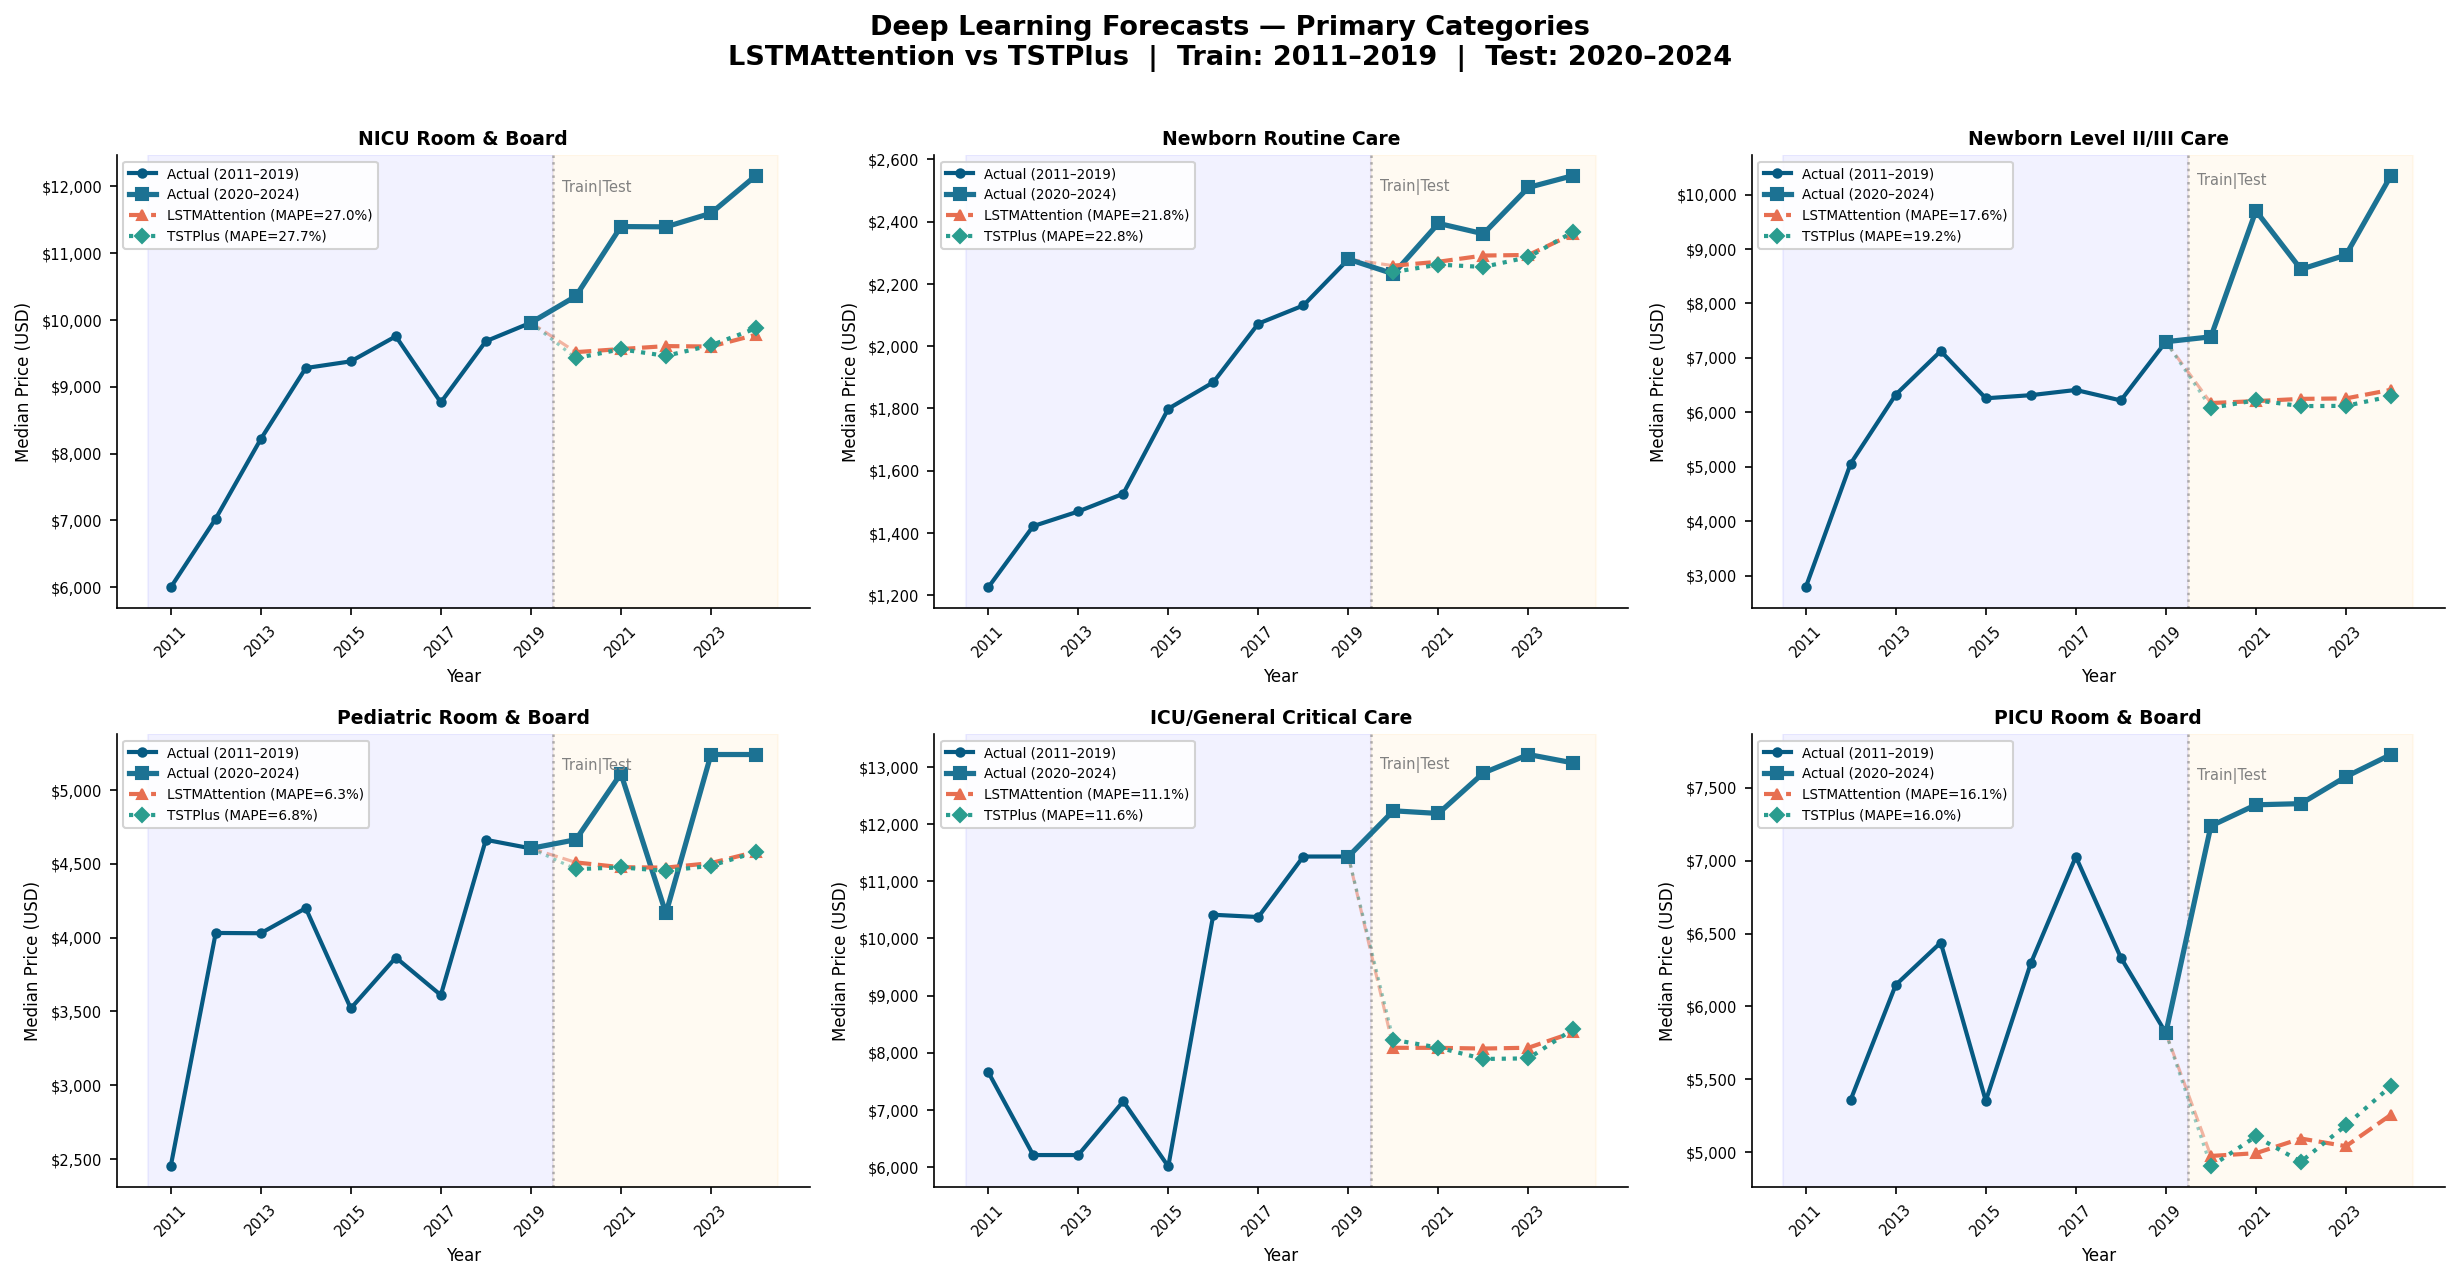

✅ Saved: tsai_forecast_plot_primary.png


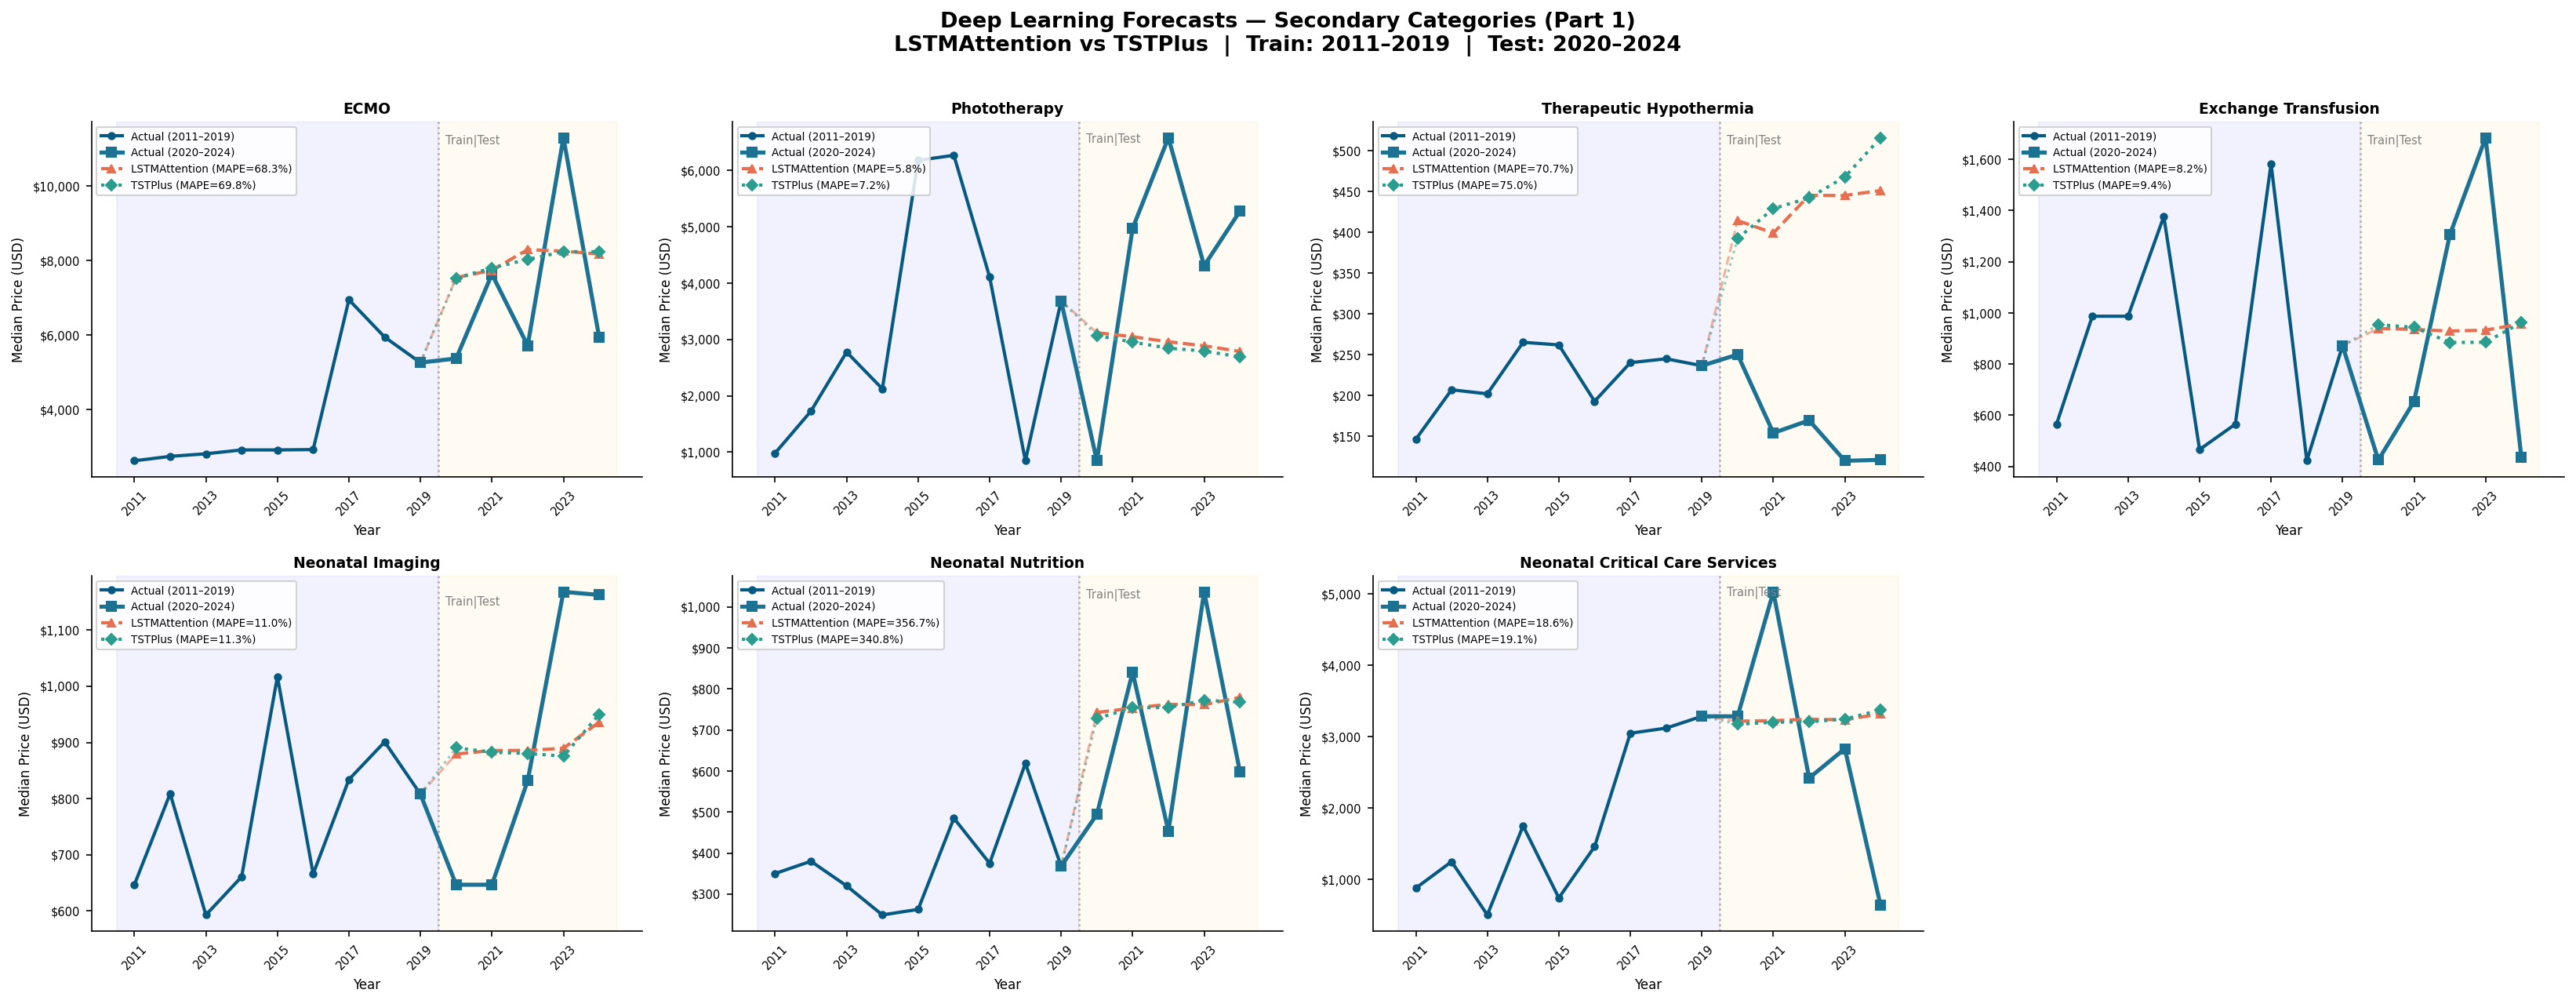

✅ Saved: tsai_forecast_plot_secondary_1.png


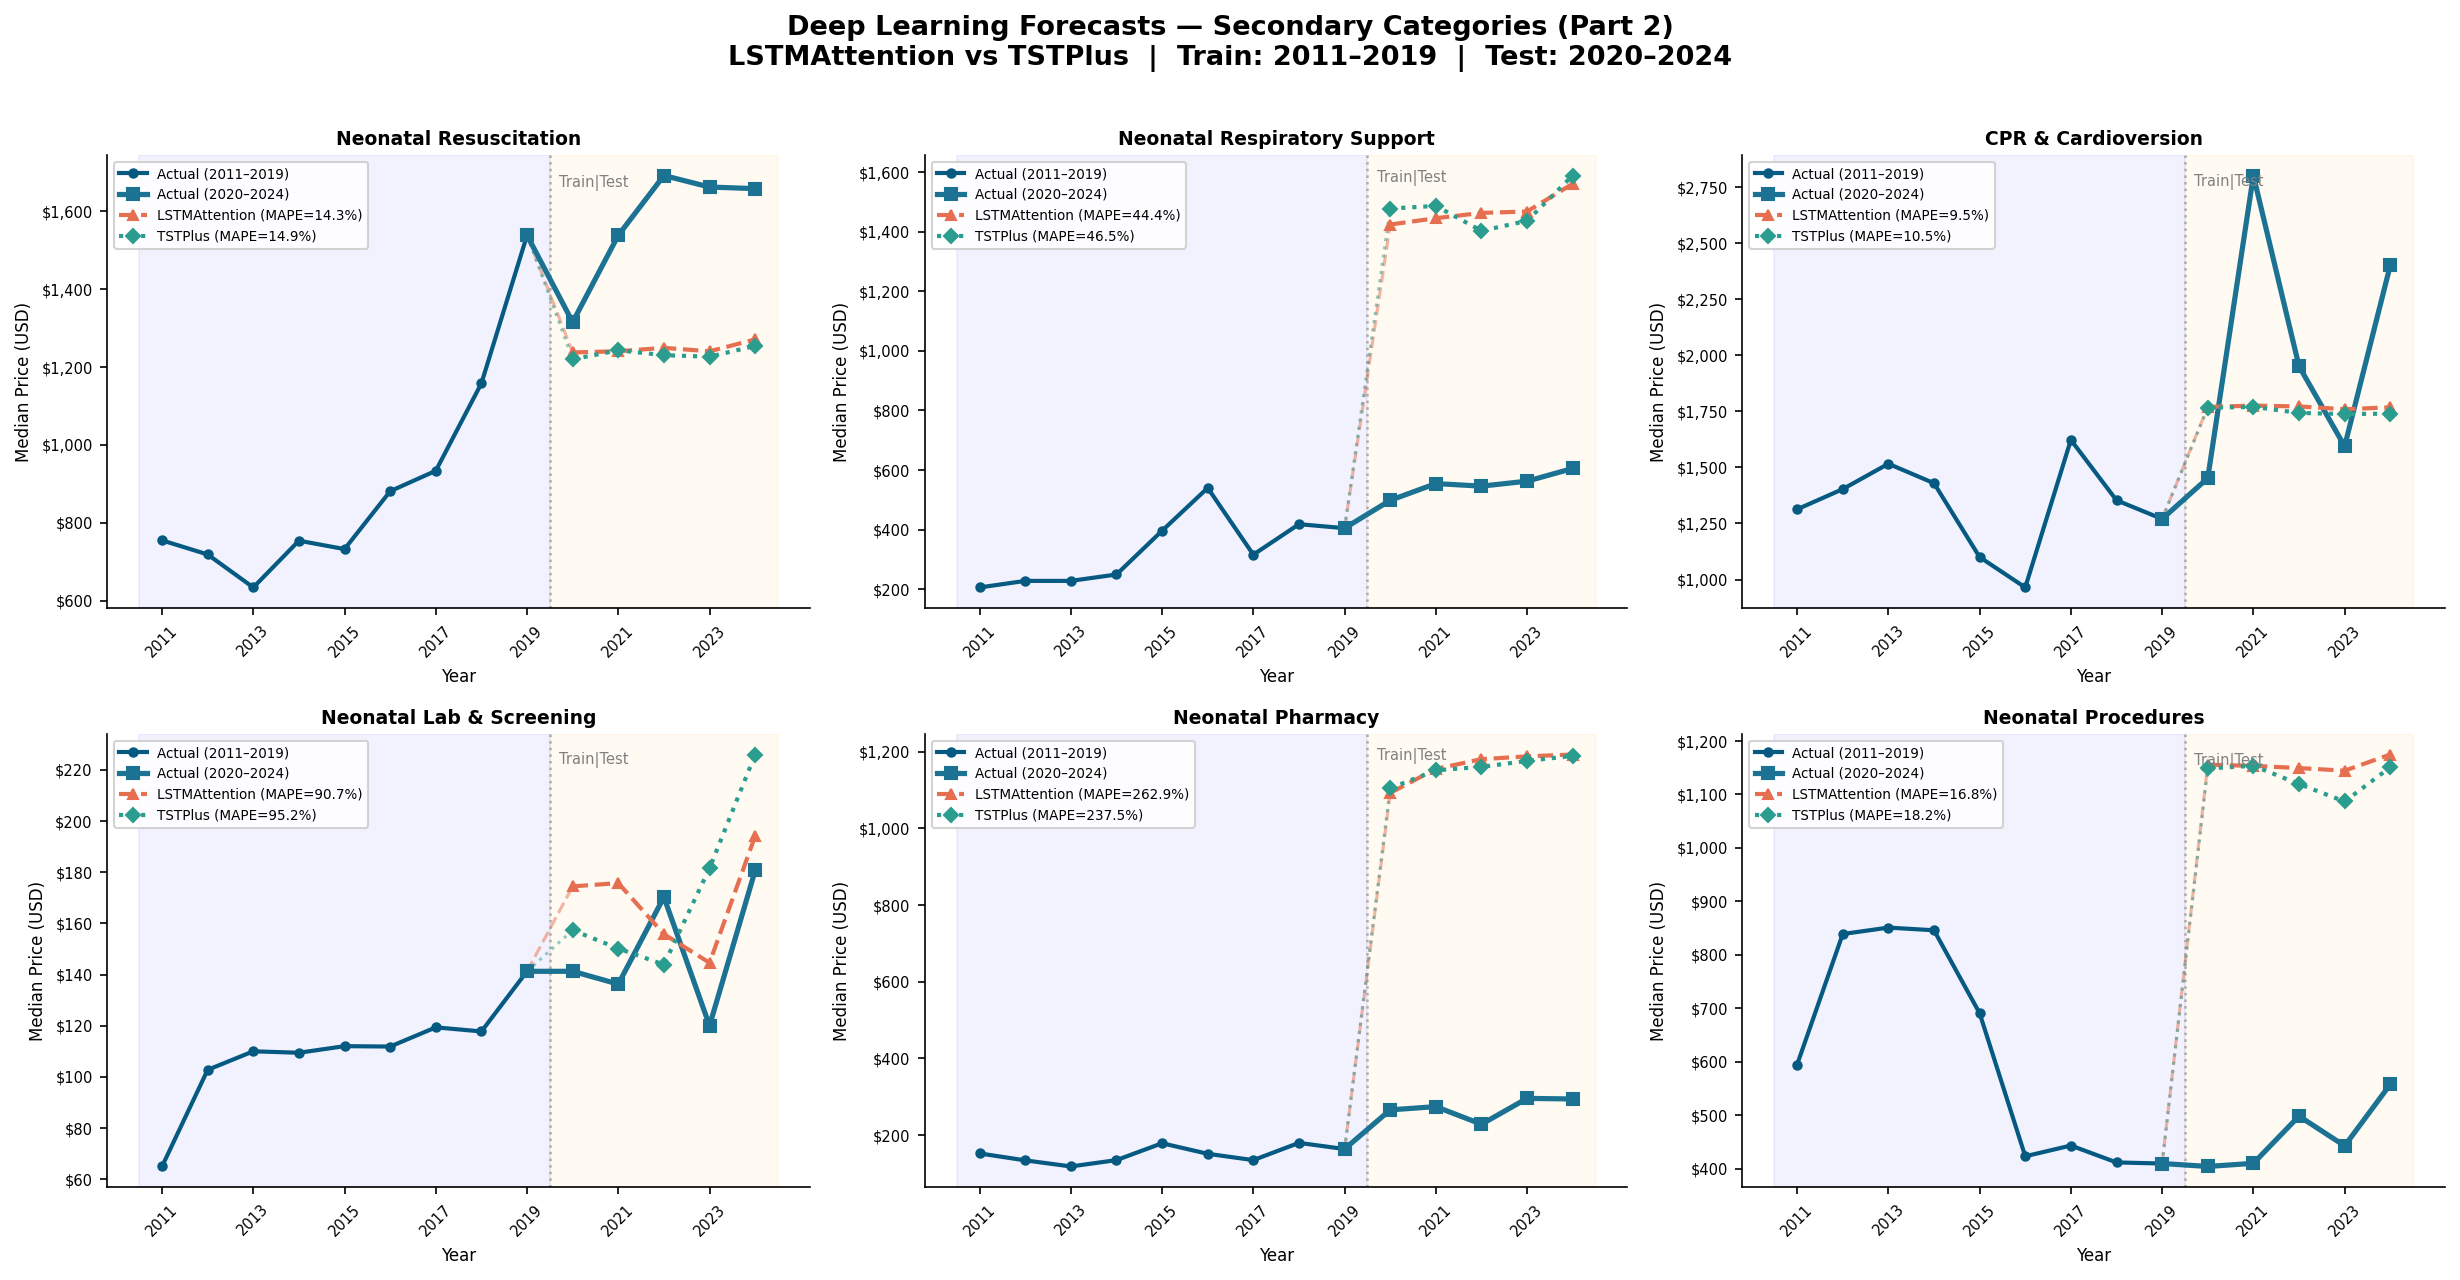

✅ Saved: tsai_forecast_plot_secondary_2.png

CONFIRMED TSAI RESULTS — tsai_recursive_results.csv

Category                              LSTMAttention    TSTPlus          Winner
──────────────────────────────────────────────────────────────────────────────
  NICU Room & Board                          27.0%     27.7%   LSTMAttention ✅
  Newborn Routine Care                       21.8%     22.8%   LSTMAttention ✅
  Newborn Level II/III Care                  17.6%     19.2%   LSTMAttention ✅
  Pediatric Room & Board                      6.3%      6.8%   LSTMAttention ✅
  ICU/General Critical Care                  11.1%     11.6%   LSTMAttention ✅
  PICU Room & Board                          16.1%     16.0%   TSTPlus ✅
  ECMO                                       68.3%     69.8%   LSTMAttention ✅
  Phototherapy                                5.8%      7.2%   LSTMAttention ✅
  Therapeutic Hypothermia                    70.7%     75.0%   LSTMAttention ✅
  Exchange Transfusion                 

In [ ]:
# ============================================================
# TSAI VISUALIZATION — USING CORRECT FILE
# tsai_recursive_results.csv = our confirmed results
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

# ── Load CORRECT file ─────────────────────────────────────────
tsai_df = pd.read_csv(
    os.path.join(BASE_PATH, 'tsai_recursive_results.csv')  # ← CORRECT FILE
)
state_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_statewide.csv'),
    dtype=str
)
state_df['year']             = pd.to_numeric(
    state_df['year'], errors='coerce'
)
state_df['statewide_median'] = pd.to_numeric(
    state_df['statewide_median'], errors='coerce'
)

for col in tsai_df.columns:
    if col not in ['model','category','group']:
        tsai_df[col] = pd.to_numeric(
            tsai_df[col], errors='coerce'
        )

print(f"tsai results loaded : {len(tsai_df)} rows")
print(f"Models              : {tsai_df['model'].unique()}")
print(f"Categories          : {tsai_df['category'].nunique()}")
print(f"\nPhototherapy check:")
print(tsai_df[tsai_df['category']=='Phototherapy'][
    ['model','mape']
].to_string(index=False))

# ── Category groups ───────────────────────────────────────────
PRIMARY = [
    'NICU Room & Board',
    'Newborn Routine Care',
    'Newborn Level II/III Care',
    'Pediatric Room & Board',
    'ICU/General Critical Care',
    'PICU Room & Board',
]
SECONDARY = [
    'ECMO',
    'Phototherapy',
    'Therapeutic Hypothermia',
    'Exchange Transfusion',
    'Neonatal Imaging',
    'Neonatal Nutrition',
    'Neonatal Critical Care Services',
    'Neonatal Resuscitation',
    'Neonatal Respiratory Support',
    'CPR & Cardioversion',
    'Neonatal Lab & Screening',
    'Neonatal Pharmacy',
    'Neonatal Procedures',
]

TEST_YEARS = [2020, 2021, 2022, 2023, 2024]

C_TRAIN       = '#065A82'
C_ACTUAL_TEST = '#1C7293'
C_LSTM        = '#E76F51'
C_TST         = '#2A9D8F'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

# ── Plot function ─────────────────────────────────────────────
def plot_tsai_group(categories, title, filename,
                    nrows, ncols):

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 5.5, nrows * 4.2)
    )
    fig.suptitle(title, fontsize=13,
                 fontweight='bold', y=1.01)
    axes = np.array(axes).flatten()

    for i, cat in enumerate(categories):
        if i >= len(axes):
            break
        ax = axes[i]

        # ── Full actual statewide series ──────────────────────
        cat_state = state_df[
            state_df['category'] == cat
        ].sort_values('year')

        train_data = cat_state[cat_state['year'] <= 2019]
        test_data  = cat_state[cat_state['year'] >= 2019]

        ax.plot(
            train_data['year'],
            train_data['statewide_median'],
            color=C_TRAIN, linewidth=2,
            marker='o', markersize=4,
            label='Actual (2011–2019)',
            zorder=3
        )
        ax.plot(
            test_data['year'],
            test_data['statewide_median'],
            color=C_ACTUAL_TEST, linewidth=2.5,
            marker='s', markersize=6,
            linestyle='-',
            label='Actual (2020–2024)',
            zorder=3
        )

        # ── Deep learning predictions ─────────────────────────
        for model_name, color, marker, style in [
            ('LSTMAttention', C_LSTM, '^', '--'),
            ('TSTPlus',       C_TST,  'D', ':' ),
        ]:
            row = tsai_df[
                (tsai_df['category'] == cat) &
                (tsai_df['model']    == model_name)
            ]
            if len(row) == 0:
                continue

            row    = row.iloc[0]
            preds  = [
                row.get(f'pred_{yr}', np.nan)
                for yr in TEST_YEARS
            ]
            mape_v = row.get('mape', np.nan)

            # Connect 2019 actual to first prediction
            last_actual = cat_state[
                cat_state['year'] == 2019
            ]['statewide_median'].values
            if len(last_actual) > 0:
                ax.plot(
                    [2019, 2020],
                    [last_actual[0], preds[0]],
                    color=color, linewidth=1.5,
                    linestyle=style, alpha=0.5
                )

            ax.plot(
                TEST_YEARS, preds,
                color=color, linewidth=2,
                linestyle=style,
                marker=marker, markersize=5,
                label=f'{model_name} '
                      f'(MAPE={mape_v:.1f}%)',
                zorder=3
            )

        # ── Divider and shading ───────────────────────────────
        ax.axvline(x=2019.5, color='gray',
                   linestyle=':', linewidth=1.2,
                   alpha=0.6)
        ax.text(2019.7,
                ax.get_ylim()[1] * 0.97
                if ax.get_ylim()[1] > 0 else 100,
                'Train|Test', fontsize=7,
                color='gray', va='top')
        ax.axvspan(2010.5, 2019.5,
                   alpha=0.05, color='blue')
        ax.axvspan(2019.5, 2024.5,
                   alpha=0.05, color='orange')

        ax.set_title(cat, fontsize=9,
                     fontweight='bold', pad=5)
        ax.set_xlabel('Year', fontsize=8)
        ax.set_ylabel('Median Price (USD)', fontsize=8)
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda x, _: f'${int(x):,}'
            )
        )
        ax.set_xticks(range(2011, 2025, 2))
        ax.tick_params(axis='x', rotation=45,
                       labelsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.legend(fontsize=6.5, loc='upper left',
                  framealpha=0.85)

    for k in range(len(categories), len(axes)):
        axes[k].set_visible(False)

    plt.tight_layout()
    path = os.path.join(BASE_PATH, filename)
    plt.savefig(path, dpi=150,
                bbox_inches='tight',
                facecolor='white')
    plt.show()
    print(f"✅ Saved: {filename}")

# ── Generate all three plots ──────────────────────────────────
plot_tsai_group(
    PRIMARY,
    'Deep Learning Forecasts — Primary Categories\n'
    'LSTMAttention vs TSTPlus  |  '
    'Train: 2011–2019  |  Test: 2020–2024',
    'tsai_forecast_plot_primary.png',
    nrows=2, ncols=3
)

plot_tsai_group(
    SECONDARY[:7],
    'Deep Learning Forecasts — Secondary Categories '
    '(Part 1)\n'
    'LSTMAttention vs TSTPlus  |  '
    'Train: 2011–2019  |  Test: 2020–2024',
    'tsai_forecast_plot_secondary_1.png',
    nrows=2, ncols=4
)

plot_tsai_group(
    SECONDARY[7:],
    'Deep Learning Forecasts — Secondary Categories '
    '(Part 2)\n'
    'LSTMAttention vs TSTPlus  |  '
    'Train: 2011–2019  |  Test: 2020–2024',
    'tsai_forecast_plot_secondary_2.png',
    nrows=2, ncols=3
)

# ── Print confirmed summary ───────────────────────────────────
print(f"\n{'='*70}")
print(f"CONFIRMED TSAI RESULTS — tsai_recursive_results.csv")
print(f"{'='*70}")
print(f"\n{'Category':<35} {'LSTMAttention':>15} "
      f"{'TSTPlus':>10} {'Winner':>15}")
print(f"{'─'*78}")

for cat in PRIMARY + SECONDARY:
    lstm_row = tsai_df[
        (tsai_df['category'] == cat) &
        (tsai_df['model'] == 'LSTMAttention')
    ]
    tst_row = tsai_df[
        (tsai_df['category'] == cat) &
        (tsai_df['model'] == 'TSTPlus')
    ]
    if len(lstm_row) == 0 or len(tst_row) == 0:
        continue

    lstm_mape = lstm_row.iloc[0]['mape']
    tst_mape  = tst_row.iloc[0]['mape']
    winner    = 'LSTMAttention ✅' \
        if lstm_mape <= tst_mape else 'TSTPlus ✅'

    print(
        f"  {cat:<33} "
        f"{lstm_mape:>13.1f}% "
        f"{tst_mape:>8.1f}% "
        f"  {winner}"
    )

print(f"\n✅ All plots saved using CORRECT results file!")
print(f"   tsai_forecast_plot_primary.png")
print(f"   tsai_forecast_plot_secondary_1.png")
print(f"   tsai_forecast_plot_secondary_2.png")

In [ ]:
!pip install neuralforecast datasetsforecast utilsforecast

**N-BEATS FORECASTING**

In [ ]:
# ============================================================
# STEP 12 — N-BEATS FINAL CORRECT VERSION
# Two fixes:
# 1. val_size goes in nf.fit(), NOT in model
# 2. start_padding_enabled=True — pads short series so
#    NeuralForecast can create windows even with 9 points
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import time
import os

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

# ── Metric functions ──────────────────────────────────────────
def calc_mape(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = (a != 0) & ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs((a[m]-p[m])/a[m]))*100 \
        if m.sum() > 0 else np.nan

def calc_mae(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs(a[m]-p[m])) if m.sum() > 0 else np.nan

def calc_rmse(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    return np.sqrt(np.mean((a[m]-p[m])**2)) \
        if m.sum() > 0 else np.nan

def calc_smape(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    d = np.abs(a[m]) + np.abs(p[m])
    return np.mean(2*np.abs(a[m]-p[m])/d)*100 \
        if m.sum() > 0 else np.nan

# ── Load data ─────────────────────────────────────────────────
state_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_statewide.csv'),
    dtype=str
)
state_df['year']             = pd.to_numeric(
    state_df['year'], errors='coerce'
)
state_df['statewide_median'] = pd.to_numeric(
    state_df['statewide_median'], errors='coerce'
)

ALL_CATEGORIES = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'PICU Room & Board',
    'ECMO', 'Phototherapy', 'Therapeutic Hypothermia',
    'Exchange Transfusion', 'Neonatal Imaging',
    'Neonatal Nutrition', 'Neonatal Critical Care Services',
    'Neonatal Resuscitation', 'Neonatal Respiratory Support',
    'CPR & Cardioversion', 'Neonatal Lab & Screening',
    'Neonatal Pharmacy', 'Neonatal Procedures',
]
PRIMARY = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'PICU Room & Board',
]

ALL_YEARS   = list(range(2011, 2025))
TRAIN_YEARS = list(range(2011, 2020))
TEST_YEARS  = list(range(2020, 2025))

# ── Build panel ───────────────────────────────────────────────
print("Building panel dataset...")
panel_rows = []
for cat in ALL_CATEGORIES:
    cat_data    = state_df[state_df['category']==cat].sort_values('year')
    cat_indexed = cat_data.set_index('year')['statewide_median']
    cat_full    = cat_indexed.reindex(ALL_YEARS).interpolate(
        method='linear', fill_value='extrapolate',
        limit_direction='both'
    ).fillna(lambda x: x.median())
    cat_full    = cat_full.fillna(cat_full.median())
    for year in ALL_YEARS:
        panel_rows.append({
            'unique_id': cat,
            'ds':        pd.Timestamp(f'{year}-01-01'),
            'y':         float(cat_full.loc[year])
        })

panel_df = pd.DataFrame(panel_rows)
train_df = panel_df[
    panel_df['ds'].dt.year <= 2019
].copy().reset_index(drop=True)
test_df  = panel_df[
    panel_df['ds'].dt.year >= 2020
].copy().reset_index(drop=True)

actuals_dict = {}
for cat in ALL_CATEGORIES:
    actuals_dict[cat] = test_df[
        test_df['unique_id']==cat
    ].sort_values('ds')['y'].tolist()

print(f"✅ Panel built — Train: {len(train_df)} rows | Test: {len(test_df)} rows")

# ── Run N-BEATS configurations ────────────────────────────────
configs = [
    {
        'name'       : 'NBEATS_Identity',
        'stack_types': ['identity', 'identity'],
        'label'      : 'N-BEATS (Identity)'
    },
    {
        'name'       : 'NBEATS_Interpretable',
        'stack_types': ['trend', 'seasonality'],
        'label'      : 'N-BEATS (Trend+Season)'
    },
]

all_results = []

for cfg in configs:
    print(f"\n{'='*60}")
    print(f"Running: {cfg['label']}")
    print(f"{'='*60}")
    t0 = time.time()

    try:
        model = NBEATS(
            h                    = 5,
            input_size           = 3,
            stack_types          = cfg['stack_types'],
            n_blocks             = [1] * len(cfg['stack_types']),
            mlp_units            = [[256, 256]] * len(cfg['stack_types']),
            max_steps            = 300,
            scaler_type          = 'standard',
            learning_rate        = 1e-3,
            batch_size           = 19,
            start_padding_enabled= True,   # ✅ KEY: pads short series
            early_stop_patience_steps = -1, # disable early stopping
            random_seed          = 42,
        )

        nf = NeuralForecast(models=[model], freq='YS')

        # ✅ val_size goes HERE in fit(), not in model
        nf.fit(df=train_df, val_size=0)

        elapsed = time.time() - t0
        print(f"✅ Done in {elapsed:.0f}s")

        forecasts = nf.predict()
        print(f"Forecast columns: {forecasts.columns.tolist()}")

        pred_col = [c for c in forecasts.columns
                    if 'NBEATS' in c.upper()]
        if not pred_col:
            print(f"❌ No NBEATS column found")
            continue
        pred_col = pred_col[0]
        print(f"Using column: {pred_col}")

        print(f"\n{'Category':<38} {'MAPE':>7} {'MAE':>9} "
              f"{'RMSE':>9} {'SMAPE':>8}")
        print(f"{'─'*75}")

        for cat in ALL_CATEGORIES:
            cat_fc = forecasts[
                forecasts['unique_id']==cat
            ].sort_values('ds')
            if len(cat_fc) == 0:
                continue

            preds   = cat_fc[pred_col].tolist()
            actuals = actuals_dict[cat]
            n       = min(len(preds), len(actuals))
            preds   = preds[:n]
            actuals = actuals[:n]

            mape  = calc_mape(actuals, preds)
            mae_v = calc_mae(actuals, preds)
            rmse  = calc_rmse(actuals, preds)
            smape = calc_smape(actuals, preds)

            grp = 'PRI' if cat in PRIMARY else 'sec'
            print(f"  [{grp}] {cat:<33} "
                  f"{mape:>6.1f}% "
                  f"${mae_v:>7,.0f} "
                  f"${rmse:>7,.0f} "
                  f"{smape:>7.1f}%")

            row = {
                'model': cfg['name'], 'label': cfg['label'],
                'category': cat,
                'group': 'Primary' if cat in PRIMARY else 'Secondary',
                'mape': round(mape, 2), 'mae': round(mae_v, 2),
                'rmse': round(rmse, 2), 'smape': round(smape, 2),
            }
            for i, yr in enumerate(TEST_YEARS):
                row[f'pred_{yr}']   = round(float(preds[i]),   2) \
                    if i < len(preds)   else None
                row[f'actual_{yr}'] = round(float(actuals[i]), 2) \
                    if i < len(actuals) else None
            all_results.append(row)

        cfg_rows = [r for r in all_results if r['model']==cfg['name']]
        pri_mape = np.mean([r['mape'] for r in cfg_rows
                            if r['group']=='Primary'])
        sec_mape = np.mean([r['mape'] for r in cfg_rows
                            if r['group']=='Secondary'])
        all_mape = np.mean([r['mape'] for r in cfg_rows])
        print(f"\n  Primary avg MAPE  : {pri_mape:.1f}%")
        print(f"  Secondary avg MAPE: {sec_mape:.1f}%")
        print(f"  Overall avg MAPE  : {all_mape:.1f}%")

    except Exception as e:
        print(f"❌ {cfg['label']} failed: {e}")
        import traceback
        traceback.print_exc()

# ── Save and compare ──────────────────────────────────────────
if all_results:
    nbeats_df = pd.DataFrame(all_results)
    nbeats_df.to_csv(
        os.path.join(BASE_PATH, 'nbeats_results.csv'), index=False
    )
    print(f"\n✅ Saved: nbeats_results.csv")

    # Load previous results
    trad_df   = pd.read_csv(os.path.join(
        BASE_PATH, 'traditional_model_results_FINAL.csv'))
    trad_best = trad_df.groupby('category')['mape'].min().reset_index()
    trad_best.columns = ['category', 'trad_mape']

    tsai_df   = pd.read_csv(os.path.join(
        BASE_PATH, 'tsai_recursive_results.csv'))
    tsai_best = tsai_df.groupby('category')['mape'].min().reset_index()
    tsai_best.columns = ['category', 'tsai_mape']

    nb_best = nbeats_df.groupby('category')['mape'].min().reset_index()
    nb_best.columns = ['category', 'nbeats_mape']

    print(f"\n{'='*78}")
    print(f"FINAL COMPARISON — Traditional vs tsai vs N-BEATS")
    print(f"{'='*78}")
    print(f"\n{'Category':<35} {'Traditional':>13} "
          f"{'tsai':>8} {'N-BEATS':>9} {'Winner':>14}")
    print(f"{'─'*83}")

    trad_w = tsai_w = nb_w = 0
    for cat in ALL_CATEGORIES:
        tv  = float(trad_best[trad_best['category']==cat
                    ]['trad_mape'].values[0]) \
              if cat in trad_best['category'].values else np.nan
        tsv = float(tsai_best[tsai_best['category']==cat
                    ]['tsai_mape'].values[0]) \
              if cat in tsai_best['category'].values else np.nan
        nbv = float(nb_best[nb_best['category']==cat
                    ]['nbeats_mape'].values[0]) \
              if cat in nb_best['category'].values else np.nan

        vals = {'Traditional': tv, 'tsai DL': tsv, 'N-BEATS ★': nbv}
        best = min(vals, key=lambda k:
                   vals[k] if not np.isnan(vals[k]) else float('inf'))
        if best == 'Traditional': trad_w += 1
        elif best == 'tsai DL':   tsai_w += 1
        else:                     nb_w   += 1

        print(f"  {cat:<33} "
              f"{tv:>12.1f}% "
              f"{tsv:>7.1f}% "
              f"{nbv:>8.1f}%  "
              f"{best}")

    print(f"\n{'='*78}")
    print(f"WINNER SUMMARY")
    print(f"{'='*78}")
    print(f"  Traditional models : {trad_w}/19")
    print(f"  tsai Deep Learning : {tsai_w}/19")
    print(f"  N-BEATS            : {nb_w}/19")
    print(f"\n✅ All done!")
else:
    print("\n❌ No results — check errors above")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Building panel dataset...
✅ Panel built — Train: 171 rows | Test: 95 rows

Running: N-BEATS (Identity)


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  269 K │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 269 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 269 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

✅ Done in 24s


Forecast columns: ['unique_id', 'ds', 'NBEATS']
Using column: NBEATS

Category                                  MAPE       MAE      RMSE    SMAPE
───────────────────────────────────────────────────────────────────────────
  [PRI] NICU Room & Board                   10.5% $  1,230 $  1,382    11.3%
  [PRI] Newborn Routine Care                 3.4% $     83 $     98     3.4%
  [PRI] Newborn Level II/III Care           11.0% $  1,064 $  1,418    12.2%
  [PRI] Pediatric Room & Board               5.9% $    266 $    327     5.6%
  [PRI] ICU/General Critical Care            7.2% $    923 $    986     7.5%
  [PRI] PICU Room & Board                    9.6% $    714 $    717     9.9%
  [sec] ECMO                                27.7% $  2,109 $  2,591    27.5%
  [sec] Phototherapy                       145.7% $  3,409 $  4,103    63.6%
  [sec] Therapeutic Hypothermia             66.0% $     89 $    100    45.7%
  [sec] Exchange Transfusion               133.7% $    819 $    909    67.9%
  [sec] 

In [ ]:
import os
os.environ['NIXTLA_API_KEY'] = ''

In [ ]:
from nixtla import NixtlaClient

# Paste your key here — make sure no spaces before or after
API_KEY = ''

print(f"Key length: {len(API_KEY)}")
print(f"Key starts with: {API_KEY[:10]}...")
print(f"Key ends with: ...{API_KEY[-5:]}")

client = NixtlaClient(api_key=API_KEY)
result = client.validate_api_key()
print(f"Validation result: {result}")

Key length: 86
Key starts with: nixak-1ee6...
Key ends with: ...93d40
Validation result: True


In [ ]:
from nixtla import NixtlaClient
import pandas as pd
import numpy as np

API_KEY = ''

client = NixtlaClient(api_key=API_KEY)

# Test with just ONE simple series first
# Use a tiny dataset to see if the forecast API works at all
test_df = pd.DataFrame({
    'unique_id': ['test'] * 9,
    'ds': [pd.Timestamp(f'{yr}-01-01') for yr in range(2011, 2020)],
    'y': [5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000]
})

print("Attempting forecast with test series...")
print(f"Input data:\n{test_df}")

try:
    fcst = client.forecast(
        df         = test_df,
        h          = 5,
        freq       = 'YS',
        time_col   = 'ds',
        target_col = 'y',
        id_col     = 'unique_id',
    )
    print(f"\n✅ Forecast worked!")
    print(fcst)

except Exception as e:
    print(f"\n❌ Error: {e}")
    print("\nTrying alternative — without id_col parameter...")

    try:
        # Some versions don't need id_col
        test_df2 = test_df.drop(columns=['unique_id'])
        fcst2 = client.forecast(
            df         = test_df2,
            h          = 5,
            freq       = 'YS',
            time_col   = 'ds',
            target_col = 'y',
        )
        print(f"✅ Worked without id_col!")
        print(fcst2)

    except Exception as e2:
        print(f"❌ Also failed: {e2}")
        print("\nChecking nixtla version...")
        import nixtla
        print(f"Nixtla version: {nixtla.__version__}")

Attempting forecast with test series...
Input data:
  unique_id         ds     y
0      test 2011-01-01  5000
1      test 2012-01-01  5500
2      test 2013-01-01  6000
3      test 2014-01-01  6500
4      test 2015-01-01  7000
5      test 2016-01-01  7500
6      test 2017-01-01  8000
7      test 2018-01-01  8500
8      test 2019-01-01  9000

✅ Forecast worked!
  unique_id         ds   TimeGPT
0      test 2020-01-01  9058.044
1      test 2021-01-01  8983.693
2      test 2022-01-01  8967.864
3      test 2023-01-01  8685.018
4      test 2024-01-01  8686.272


In [ ]:
# ============================================================
# STEP 13 — TimeGPT ZERO-SHOT FORECASTING — WORKING VERSION
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import os
from nixtla import NixtlaClient

BASE_PATH = '/content/drive/MyDrive/ChargeMasters'

API_KEY =  '' # ← same key that worked above
client  = NixtlaClient(api_key=API_KEY)

# ── Metric functions ──────────────────────────────────────────
def calc_mape(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = (a != 0) & ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs((a[m]-p[m])/a[m]))*100 \
        if m.sum() > 0 else np.nan

def calc_mae(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    return np.mean(np.abs(a[m]-p[m])) if m.sum() > 0 else np.nan

def calc_rmse(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    return np.sqrt(np.mean((a[m]-p[m])**2)) \
        if m.sum() > 0 else np.nan

def calc_smape(actual, predicted):
    a, p = np.array(actual, float), np.array(predicted, float)
    m = ~np.isnan(a) & ~np.isnan(p)
    d = np.abs(a[m]) + np.abs(p[m])
    return np.mean(2*np.abs(a[m]-p[m])/d)*100 \
        if m.sum() > 0 else np.nan

# ── Load data ─────────────────────────────────────────────────
state_df = pd.read_csv(
    os.path.join(BASE_PATH, 'aggregated_statewide.csv'),
    dtype=str
)
state_df['year']             = pd.to_numeric(
    state_df['year'], errors='coerce')
state_df['statewide_median'] = pd.to_numeric(
    state_df['statewide_median'], errors='coerce')

ALL_CATEGORIES = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'PICU Room & Board',
    'ECMO', 'Phototherapy', 'Therapeutic Hypothermia',
    'Exchange Transfusion', 'Neonatal Imaging',
    'Neonatal Nutrition', 'Neonatal Critical Care Services',
    'Neonatal Resuscitation', 'Neonatal Respiratory Support',
    'CPR & Cardioversion', 'Neonatal Lab & Screening',
    'Neonatal Pharmacy', 'Neonatal Procedures',
]
PRIMARY = [
    'NICU Room & Board', 'Newborn Routine Care',
    'Newborn Level II/III Care', 'Pediatric Room & Board',
    'ICU/General Critical Care', 'PICU Room & Board',
]

ALL_YEARS   = list(range(2011, 2025))
TRAIN_YEARS = list(range(2011, 2020))
TEST_YEARS  = list(range(2020, 2025))

# ── Build series ──────────────────────────────────────────────
print("Building time series...")
series_dict  = {}
actuals_dict = {}

for cat in ALL_CATEGORIES:
    cat_data    = state_df[
        state_df['category'] == cat
    ].sort_values('year')
    cat_indexed = cat_data.set_index('year')['statewide_median']
    cat_full    = cat_indexed.reindex(ALL_YEARS).interpolate(
        method='linear', fill_value='extrapolate',
        limit_direction='both'
    )
    cat_full         = cat_full.fillna(cat_full.median())
    series_dict[cat] = cat_full
    actuals_dict[cat]= [float(cat_full.loc[yr]) for yr in TEST_YEARS]

print(f"✅ {len(series_dict)} series ready")

# ── Run TimeGPT ───────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"RUNNING TimeGPT — ZERO-SHOT FORECASTING")
print(f"{'='*65}")
print(f"No training needed — pre-trained on billions of series")
print(f"Input: 2011–2019 | Forecast: 2020–2024 | All 19 categories")
print()

all_results = []
failed      = []

for cat in ALL_CATEGORIES:
    try:
        # Training data only — 2011 to 2019
        train_df = pd.DataFrame({
            'unique_id': cat,
            'ds': [pd.Timestamp(f'{yr}-01-01')
                   for yr in TRAIN_YEARS],
            'y':  series_dict[cat].loc[TRAIN_YEARS].values
        })

        # One API call — zero-shot forecast
        fcst = client.forecast(
            df         = train_df,
            h          = 5,
            freq       = 'YS',
            time_col   = 'ds',
            target_col = 'y',
            id_col     = 'unique_id',
        )

        preds   = fcst['TimeGPT'].tolist()
        actuals = actuals_dict[cat]
        n       = min(len(preds), len(actuals))
        preds   = preds[:n]
        actuals = actuals[:n]

        mape  = calc_mape(actuals, preds)
        mae_v = calc_mae(actuals, preds)
        rmse  = calc_rmse(actuals, preds)
        smape = calc_smape(actuals, preds)

        grp = 'PRI' if cat in PRIMARY else 'sec'
        print(f"  [{grp}] {cat:<33} "
              f"MAPE: {mape:>6.1f}%  "
              f"MAE: ${mae_v:>7,.0f}")

        row = {
            'model'   : 'TimeGPT',
            'category': cat,
            'group'   : 'Primary' if cat in PRIMARY else 'Secondary',
            'mape'    : round(mape,  2),
            'mae'     : round(mae_v, 2),
            'rmse'    : round(rmse,  2),
            'smape'   : round(smape, 2),
        }
        for j, yr in enumerate(TEST_YEARS):
            row[f'pred_{yr}']   = round(float(preds[j]),   2) \
                if j < len(preds)   else None
            row[f'actual_{yr}'] = round(float(actuals[j]), 2) \
                if j < len(actuals) else None
        all_results.append(row)

    except Exception as e:
        print(f"  ❌ {cat}: {e}")
        failed.append(cat)

# ── Save and compare ──────────────────────────────────────────
if all_results:
    tgpt_df  = pd.DataFrame(all_results)
    out_path = os.path.join(BASE_PATH, 'timegpt_results.csv')
    tgpt_df.to_csv(out_path, index=False)

    pri = tgpt_df[tgpt_df['group']=='Primary']['mape']
    sec = tgpt_df[tgpt_df['group']=='Secondary']['mape']

    print(f"\n{'='*65}")
    print(f"TimeGPT SUMMARY")
    print(f"{'='*65}")
    print(f"  Primary avg MAPE  : {pri.mean():.1f}%")
    print(f"  Secondary avg MAPE: {sec.mean():.1f}%")
    print(f"  Overall avg MAPE  : {tgpt_df['mape'].mean():.1f}%")
    if failed:
        print(f"  Failed            : {failed}")

    # ── 4-way comparison ──────────────────────────────────────
    trad_df    = pd.read_csv(os.path.join(
        BASE_PATH, 'traditional_model_results_FINAL.csv'))
    tsai_df    = pd.read_csv(os.path.join(
        BASE_PATH, 'tsai_recursive_results.csv'))
    nbeats_df  = pd.read_csv(os.path.join(
        BASE_PATH, 'nbeats_results.csv'))

    trad_best  = trad_df.groupby('category')['mape']\
                     .min().reset_index()
    tsai_best  = tsai_df.groupby('category')['mape']\
                     .min().reset_index()
    nbeats_best= nbeats_df.groupby('category')['mape']\
                     .min().reset_index()

    print(f"\n{'='*82}")
    print(f"COMPLETE 4-WAY COMPARISON — ALL MODEL FAMILIES")
    print(f"Traditional vs tsai vs N-BEATS vs TimeGPT (zero-shot)")
    print(f"{'='*82}")
    print(f"\n{'Category':<33} {'Trad':>7} {'tsai':>7} "
          f"{'NBEATS':>8} {'TimeGPT':>9} {'Winner':>14}")
    print(f"{'─'*82}")

    trad_w = tsai_w = nb_w = tgpt_w = 0
    summary_rows = []

    for cat in ALL_CATEGORIES:
        def get_mape(df, col):
            vals = df[df['category']==cat][col].values
            return float(vals[0]) if len(vals) > 0 else np.nan

        tv  = get_mape(trad_best,   'mape')
        tsv = get_mape(tsai_best,   'mape')
        nbv = get_mape(nbeats_best, 'mape')
        tgv = float(tgpt_df[tgpt_df['category']==cat
                    ]['mape'].values[0]) \
              if cat in tgpt_df['category'].values else np.nan

        vals = {
            'Traditional': tv,
            'tsai DL'    : tsv,
            'N-BEATS'    : nbv,
            'TimeGPT ★'  : tgv,
        }
        best = min(
            vals,
            key=lambda k: vals[k] if not np.isnan(vals[k])
            else float('inf')
        )
        if   best == 'Traditional': trad_w  += 1
        elif best == 'tsai DL':     tsai_w  += 1
        elif best == 'N-BEATS':     nb_w    += 1
        else:                       tgpt_w  += 1

        # Mark winner with arrow
        def fmt(v, name):
            arrow = ' ←' if best == name else ''
            return f"{v:>6.1f}%{arrow}" if not np.isnan(v) \
                else "    N/A"

        print(f"  {cat:<31} "
              f"{tv:>6.1f}% "
              f"{tsv:>6.1f}% "
              f"{nbv:>7.1f}% "
              f"{tgv:>8.1f}%  "
              f"{best}")

        summary_rows.append({
            'Category'        : cat,
            'Group'           : 'Primary' if cat in PRIMARY
                                else 'Secondary',
            'Traditional_MAPE': round(tv,  2),
            'tsai_MAPE'       : round(tsv, 2),
            'NBEATS_MAPE'     : round(nbv, 2),
            'TimeGPT_MAPE'    : round(tgv, 2),
            'Winner'          : best,
        })

    print(f"\n{'='*82}")
    print(f"WINNER COUNTS — WHICH MODEL FAMILY IS BEST?")
    print(f"{'='*82}")
    print(f"  Traditional models     : {trad_w}/19 categories")
    print(f"  tsai Deep Learning     : {tsai_w}/19 categories")
    print(f"  N-BEATS                : {nb_w}/19 categories")
    print(f"  TimeGPT (zero-shot)    : {tgpt_w}/19 categories")

    # Best MAPE per method across primary categories
    pri_rows = [r for r in summary_rows
                if r['Group'] == 'Primary']
    print(f"\n{'='*82}")
    print(f"PRIMARY CATEGORIES — AVERAGE MAPE PER METHOD")
    print(f"{'='*82}")
    print(f"  Traditional : "
          f"{np.mean([r['Traditional_MAPE'] for r in pri_rows]):.1f}%")
    print(f"  tsai DL     : "
          f"{np.mean([r['tsai_MAPE'] for r in pri_rows]):.1f}%")
    print(f"  N-BEATS     : "
          f"{np.mean([r['NBEATS_MAPE'] for r in pri_rows]):.1f}%")
    print(f"  TimeGPT     : "
          f"{np.mean([r['TimeGPT_MAPE'] for r in pri_rows]):.1f}%")

    # Save final comparison
    final_df = pd.DataFrame(summary_rows)
    final_path = os.path.join(BASE_PATH, 'final_4way_comparison.csv')
    final_df.to_csv(final_path, index=False)

    print(f"\n✅ timegpt_results.csv saved")
    print(f"✅ final_4way_comparison.csv saved")
    print(f"\nYour complete forecasting results are ready!")
    print(f"Four model families compared across all 19 categories.")

else:
    print("❌ All categories failed — check API key")

Building time series...
✅ 19 series ready

RUNNING TimeGPT — ZERO-SHOT FORECASTING
No training needed — pre-trained on billions of series
Input: 2011–2019 | Forecast: 2020–2024 | All 19 categories

  [PRI] NICU Room & Board                 MAPE:   12.8%  MAE: $  1,490
  [PRI] Newborn Routine Care              MAPE:    7.1%  MAE: $    174
  [PRI] Newborn Level II/III Care         MAPE:   17.2%  MAE: $  1,634
  [PRI] Pediatric Room & Board            MAPE:    8.5%  MAE: $    420
  [PRI] ICU/General Critical Care         MAPE:   18.2%  MAE: $  2,340
  [PRI] PICU Room & Board                 MAPE:   19.9%  MAE: $  1,489
  [sec] ECMO                              MAPE:   33.5%  MAE: $  2,785
  [sec] Phototherapy                      MAPE:   99.8%  MAE: $  2,312
  [sec] Therapeutic Hypothermia           MAPE:   59.4%  MAE: $     80
  [sec] Exchange Transfusion              MAPE:   62.7%  MAE: $    477
  [sec] Neonatal Imaging                  MAPE:   24.5%  MAE: $    220
  [sec] Neonatal Nutr